<div align="center">

# **Análise de Receita dos Planos Megaline:**<br> Um Estudo Comparativo<br>(🏄🏻‍♂️ Surf X 👑Ultimate)

</div>

<div align="center">
  <img src="https://i.imgur.com/v9rthp9.png" width="1600" alt="Banner da Análise Megaline">
</div>

## **Introdução**

A empresa de telecomunicações **Megaline** busca **otimizar seu orçamento de marketing** e precisa de uma resposta objetiva a pergunta:

> *Qual de seus dois planos pré-pagos, Surf ou Ultimate, gera mais receita?*

Embora o plano **Ultimate** tenha uma mensalidade mais alta, o plano **Surf** pode gerar receitas significativas através de taxas extras.<br><br>

Esta **análise exploratória** investigará os padrões de uso e a receita de 500 clientes em 2018.<br><br>

O objetivo é determinar **qual plano é mais lucrativo** para, assim, direcionar seus esforços de marketing.<br><br>

Além disso, investigaremos uma hipótese secundária: 
> *A receita média dos usuários da área de Nova Iorque/Nova Jersey (NY-NJ) é diferente da receita dos usuários de outras regiões?*
 


<br>O processo seguirá as seguintes **etapas**:
1.  Inicialização
2.  Carregamento
3.  Preparação dos dados
4.  Agregação por usuário/mês
5.  Análise exploratória (EDA)
6.  Testes de hipóteses
7.  Conclusão Geral

### **Descrição dos planos**


A Megaline está avaliando dois planos: Surf e Ultimate. 
Segue um resumo de cada plano:

<div class="alert alert-block alert-info">

| 🏄🏻‍♂️ Surf | 👑 Ultimate |
| :--- | :--- |
| **Preço mensal:** $20 | **Preço mensal:** $70 |
| **Pacote:** 500 min, 50 msg, 15 GB | **Pacote:** 3.000 min, 1.000 msg, 30 GB |
| **Excedente (Min):** $0.03 | **Excedente (Min):** $0.01 |
| **Excedente (Msg):** $0.03 | **Excedente (Msg):** $0.01 |
| **Excedente (Dados):** $10 por GB | **Excedente (Dados):** $7 por GB |

</div>

### **Dicionário de Dados:**
Neste projeto, iremos trabalhar com cinco tabelas separadas:

1. Tabela ``'users'``
2. Tabela ``'calls'``
3. Tabela ``'messages'``
4. Tabela ``'internet'``
5. Tabela ``'plans'``

Abaixo encontra-se o dicionário de cada uma das tabelas:


#### **1. Tabela `users` (dados sobre usuários)**

<div class="alert alert-block alert-info">

| **Coluna** | **Descrição** |
| :--- | :--- |
| **`user_id`** | Identificador exclusivo do usuário |
| **`first_name`** | Nome do usuário |
| **`last_name`** | Sobrenome do usuário |
| **`age`** | Idade do usuário (em anos) |
| **`reg_date`** | Data da inscrição (dd, mm, aa) |
| **`churn_date`** | A data que o usuário parou de usar o serviço (se o valor estiver ausente, o plano estava em uso quando o banco de dados foi extraído) |
| **`city`**| Cidade de residência do usuário |
| **`plan`** | Nome do plano |

</div>

#### **2. Tabela `calls` (dados sobre as chamadas)**

<div class="alert alert-block alert-info">

| **Coluna** | **Descrição** |
| :--- | :--- |
| **`id`** | Identificador de chamada exclusivo |
| **`call_date`** | Data da chamada |
| **`duration`** | Duração da chamada (em minutos) |
| **`user_id`** | Identificador do usuário que faz a chamada |

</div>

#### **3. Tabela `messages` (dados sobre mensagens de texto)**

<div class="alert alert-block alert-info">

| **Coluna** | **Descrição** |
| :--- | :--- |
| **`id`** | Identificador exclusivo da mensagem de texto |
| **`message_date`** | Data da mensagem de texto |
| **`user_id`** | Identificador do usuário que envia a mensagem de texto |

</div>

#### **4. Tabela `internet` (dados sobre sessões web)**

<div class="alert alert-block alert-info">

| **Coluna** | **Descrição** |
| :--- | :--- |
| **`id`** | Identificador exclusivo da sessão |
| **`mb_used`** | O volume de dados gasto durante a sessão (em megabytes) |
| **`session_date`** | Data da sessão web |
| **`user_id`** | Identificador do usuário |

</div>

#### **5. Tabela `plans` (dados sobre os planos)**

<div class="alert alert-block alert-info">

| **Coluna** | **Descrição** |
| :--- | :--- |
| **`plan_name`** | Nome do plano |
| **`usd_monthly_fee`** | Preço mensal em dólares americanos |
| **`minutes_included`** | Pacote mensal de minutos |
| **`messages_included`** | Pacote mensal de mensagens de texto |
| **`mb_per_month_included`** | Volume do pacote de dados (em megabytes) |
| **`usd_per_minute`** | Preço por minuto depois de exceder o limite do pacote (ex: se o pacote inclui 100 minutos, o 101º minuto será cobrado) |
| **`usd_per_message`** | Preço por mensagem de texto depois de exceder o limite do pacote |
| **`usd_per_gb`** | Preço por gigabyte extra de dados após exceder o limite do pacote (1 GB = 1.024 megabytes) |

</div>

<a id="ancora-init"></a>

## 🚀 **Inicialização e Carregamento dos Dados**

Nesta seção:
1. Importamos as bibliotecas Python necessárias (``Pandas``, ``Matplotlib``, ``Seaborn``, ``SciPy``)
2. Carregamos os cinco arquivos CSV (``users``, ``calls``, ``internet``, ``messages``, ``plans``) em DataFrames do Pandas.

In [783]:
# 1. Carregando todas as bibliotecas

print('👉 Passo 1: Importando Bibliotecas Essenciais...')

# Manipulação e análise de dados
import pandas as pd
import math
import numpy as np

# Visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.lines import Line2D 
import matplotlib.ticker as ticker 
import matplotlib.patheffects as pe


# Testes estatísticos
from scipy import stats as st

print('\n✅ Bibliotecas carregadas com sucesso!')

👉 Passo 1: Importando Bibliotecas Essenciais...

✅ Bibliotecas carregadas com sucesso!


In [784]:
# Carregando os arquivos de dados em diferentes DataFrames

print('👉 Passo 2: Carregando nossos arquivos em DataFrames...')

try:
    df_calls = pd.read_csv('../data/megaline_calls.csv')
    df_internet = pd.read_csv('../data/megaline_internet.csv')
    df_messages = pd.read_csv('../data/megaline_messages.csv')
    df_plans = pd.read_csv('../data/megaline_plans.csv')
    df_users = pd.read_csv('../data/megaline_users.csv')

    # df_calls = pd.read_csv(r'/datasets/megaline_calls.csv')
    # df_internet = pd.read_csv(r'/datasets/megaline_internet.csv')
    # df_messages = pd.read_csv(r'/datasets/megaline_messages.csv')
    # df_plans = pd.read_csv(r'/datasets/megaline_plans.csv')
    # df_users = pd.read_csv(r'/datasets/megaline_users.csv')
    print('\n✅ Todos os arquivos carregados com sucesso!')
    print("\n👇 Iniciando a preparação dos dados...")

except FileNotFoundError:
    print("❌ Erro: Um ou mais arquivos não foram encontrados. Verifique o caminho e o nome do arquivo.")
    print("\n🛑 Não foi possível carregar os dados. A análise não pode continuar.")
    
except Exception as e:
    print(f"❌ Ocorreu um erro inesperado: {e}")
    print("\n🛑 Não foi possível carregar os dados. A análise não pode continuar.")

👉 Passo 2: Carregando nossos arquivos em DataFrames...

✅ Todos os arquivos carregados com sucesso!

👇 Iniciando a preparação dos dados...


#### 💡 **Conclusão:**

✅ Bibliotecas importadas e todos os cinco DataFrames carregados com sucesso. 

O ambiente está pronto para a preparação dos dados.

---

<a id="ancora-prep"></a>

## 🧹 **Preparação dos dados**

Esta é uma etapa crítica. Vamos examinar cada DataFrame individualmente para identificar e corrigir problemas como tipos de dados incorretos, valores ausentes e inconsistências. O objetivo é garantir a qualidade e a integridade dos dados antes de uni-los para a análise.

<div class="alert alert-block alert-info">

| # | **Tabelas** | **Descrição** |
| :---: | :---: | :--- |
| 1 | **``df_plans``** | Dados sobre os planos | 
| 2 | **``df_users``** | Dados sobre usuários |
| 3 | **``df_calls``** | Dados sobre as chamadas | 
| 4 | **``df_messages``** | Dados sobre mensagens de texto | 
| 5 | **``df_internet``** | Dados sobre sessões web |



---

### 📶 **Planos**

In [785]:
# Imprimindo as informações gerais sobre o DataFrame dos planos

print('👉 1. Imprimindo as informações gerais do DataFrame PLANOS (`df_plans`):\n')

df_plans.info()

👉 1. Imprimindo as informações gerais do DataFrame PLANOS (`df_plans`):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [786]:
# Imprimindo uma amostra de dados dos planos
# df_plans

print('👉 2. Imprimindo uma amostra de dados do DataFrame PLANOS (`df_plans`):')

# definindo nosso estilo de tabela 
table_styles = [
    # regra para os títulos das colunas 
    {
        'selector': 'th', 
        'props': [
            ('background-color', '#4A5568'),   # Fundo Cinza Ardósia
            ('color', 'white'),                  # Texto Branco
            ('text-align', 'center')
        ]
    },
    # Regra para a legenda  
    {
        'selector': 'caption',
        'props': [
            ('text-align', 'left'),
            ('font-size', '18px'),
            ('font-weight', 'bold'),
            ('padding-bottom', '15px')
        ]
    }
]


display(df_plans.head().style.set_caption('df_plans').set_table_styles(table_styles)) 

👉 2. Imprimindo uma amostra de dados do DataFrame PLANOS (`df_plans`):


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.030000,0.030000,surf
1,1000,30720,3000,70,7,0.010000,0.010000,ultimate


####  💡 **Conclusão:**
- Não será necessário fazer nenhuma correção na tabela dos Planos.
- A amostra de dados do `df_plans` mostra apenas duas linhas.
- Cada uma representa um dos planos da Megaline, Surf e Ultimate, e seus limites de consumo e taxas adicionais.
- O tipo de dados está **correto**
- **Não há** dados ausentes em `df_plans`


---

### 👤 **Usuários**

In [787]:
# Imprimindo informações gerais/resumo sobre o DataFrame dos usuários
print('👉 1. Imprimindo as informações gerais do DataFrame USUÁRIOS (`df_users`):\n')

df_users.info()


👉 1. Imprimindo as informações gerais do DataFrame USUÁRIOS (`df_users`):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [788]:
# Imprimindo uma amostra de dados dos usuários
# df_users

print('👉 2. Imprimindo uma Amostra de Dados do DataFrame USUÁRIOS (`df_users`):')

display(df_users.head(10).style.set_caption('df_users').set_table_styles(table_styles))

👉 2. Imprimindo uma Amostra de Dados do DataFrame USUÁRIOS (`df_users`):


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,nan
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,nan
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,nan
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,nan
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,nan
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,nan
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,nan
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,nan
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,nan


In [789]:
print(f'''👉 3. Analisando Valores Nulos e Duplicados: 
      
# Imprimindo Colunas com Valores Nulos:
{df_users.isna().sum()}''')

# Contando o total e nulos
total_de_usuarios = len(df_users)
usuarios_ativos = df_users['churn_date'].isna().sum()
valores_nulos = df_users[df_users['churn_date'].isna()]

# Calculando o churn
churn_rate = (df_users['churn_date'].notna().sum() / total_de_usuarios) * 100

# Calculando os duplicados
n_duplicados = df_users.duplicated().sum()
n_duplicados_user_id = df_users['user_id'].duplicated().sum()


print(f'''
# Observações:
- Há apenas valores nulos em Churn Date ({usuarios_ativos} 'NaN').
- Isso significa que em nossa amostra de {total_de_usuarios}, {usuarios_ativos} ainda são clientes.
- A taxa de churn média da amostra é {churn_rate:.2f}%

# Exibindo uma amostra dos valores nulos:''')
{display(valores_nulos.head().style)}

print(f'''
# Analisando os duplicados:
- Número de Linhas totalmente duplicadas: {n_duplicados}
- Número de Linhas duplicadas em ["user_id"]: {n_duplicados_user_id}''')

👉 3. Analisando Valores Nulos e Duplicados: 
      
# Imprimindo Colunas com Valores Nulos:
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

# Observações:
- Há apenas valores nulos em Churn Date (466 'NaN').
- Isso significa que em nossa amostra de 500, 466 ainda são clientes.
- A taxa de churn média da amostra é 6.80%

# Exibindo uma amostra dos valores nulos:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,nan
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,nan
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,nan
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,nan
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,nan



# Analisando os duplicados:
- Número de Linhas totalmente duplicadas: 0
- Número de Linhas duplicadas em ["user_id"]: 0


#### **Observações:**

Pela amostra acima, podemos observar a estrutura e conteúdo do dataset `df_users`.  

Os pontos principais que observamos são:
- Embora a estrutura do dataset corresponda ao esperado, com a maioria dos registros devidamente populados, há exceções na coluna `['churn_date]`
  - `['churn_date]` é a única coluna que possuí dados ausentes, provavelmente indicando consumidores que ainda são ativos
  - Em nossos dados, há 466 dados ausentes na coluna `['churn_date']` de uma amostra de 500 linhas, o que representa 93.20% de nossa amostra. Isso signifca uma taxa de churn dentro do dataset analisado de 6.80%.
- O campo de ID `['user_id']` é um número inteiro, como o esperado.
- Os campos de data `['reg_date']` e `['churn_date']` podem precisar de conversão para o formato datetime.
- O campo textual `['city']` contém tanto a cidade quanto os códigos de região, que podem ser separados para uma análise geográfica mais aprofundada.
- O campo numérico `['age']` parece estar adequado, mas checar por outliers ou valores inválidos é recomendado.

</div>

#### **Corrijindo os dados**

In [790]:
print('👉 Corrigindo o tipo de dados dos campos de DATA em "df_users"...\n')
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])
print(df_users.info())

print('\n   ✅ SUCESSO! Colunas ["reg_date"] e ["churn_date"] alteradas de "object" para "datetime"')

👉 Corrigindo o tipo de dados dos campos de DATA em "df_users"...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None

   ✅ SUCESSO! Colunas ["reg_date"] e ["churn_date"] alteradas de "object" para "datetime"


#### **Resumo das Alterações: ``df_users``**

O DataFrame principal ``df_users`` foi corrigido com sucesso. As colunas ``['reg_date']`` (data de inscrição) e ``['churn_date']`` (data de cancelamento) foram ambas convertidas do tipo object (texto) para datetime.

Essa correção é essencial para futuras análises de tempo de vida do cliente (customer lifetime) e para identificar corretamente os clientes ativos (aqueles com valor nulo em churn_date).

---

### 📞 **Chamadas**

Para nosso DataFrame CHAMADAS `df_calls`, de acordo com a política de cobrança da Megaline, 
precisaremos arredondar a **duração das chamadas** individualmente, dessa forma:

- Cada chamada individual é arrendondada para cima
- Mesmo que uma chamada tenha durado apenas um segundo, um minuto será contado. 
- Então, precisamos arredondar CADA chamada INDIVIDUAL PARA CIMA, para o próximo minuto inteiro.
- Ex: uma chamada de 7.2 minutos vira 8 minutos, 0.37 minutos vira 1 minuto, 13.66 minutos vira 14 minutos e assim por diante.

In [791]:
# Imprimindo informações gerais sobre o DataFrame das chamadas

print('👉 1. Imprimindo as informações gerais do DataFrame CHAMADAS (`df_calls`):\n')

df_calls.info()

👉 1. Imprimindo as informações gerais do DataFrame CHAMADAS (`df_calls`):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [792]:
# Imprimindo uma amostra de dados das chamadas
# df_calls

print('👉 2. Imprimindo uma Amostra de Dados do DataFrame CHAMADAS (`df_calls`):')

display(df_calls.head(10).style.set_caption('df_calls').set_table_styles(table_styles))

👉 2. Imprimindo uma Amostra de Dados do DataFrame CHAMADAS (`df_calls`):


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.520000
1,1000_145,1000,2018-12-27,13.660000
2,1000_247,1000,2018-12-27,14.480000
3,1000_309,1000,2018-12-28,5.760000
4,1000_380,1000,2018-12-30,4.220000
5,1000_388,1000,2018-12-31,2.200000
6,1000_510,1000,2018-12-27,5.750000
7,1000_521,1000,2018-12-28,14.180000
8,1000_530,1000,2018-12-28,5.770000
9,1000_544,1000,2018-12-26,4.400000


In [793]:
print(f'''👉 3. Analisando Valores Nulos e Duplicados: 
      
# Imprimindo Colunas com Valores Nulos:
{df_calls.isna().sum()}''')


# Calculando os duplicados
n_duplicados_calls = df_calls.duplicated().sum()
n_duplicados_call_id = df_calls['id'].duplicated().sum()

print(f'''
# Observações:
- Não há valores nulos.

# Valores duplicados: 
> Analisando os duplicados:
    - Número de Linhas totalmente duplicadas: {n_duplicados_calls}
    - Número de Linhas duplicadas em ID da Ligação ["id"]: {n_duplicados_call_id}''')

👉 3. Analisando Valores Nulos e Duplicados: 
      
# Imprimindo Colunas com Valores Nulos:
id           0
user_id      0
call_date    0
duration     0
dtype: int64



# Observações:
- Não há valores nulos.

# Valores duplicados: 
> Analisando os duplicados:
    - Número de Linhas totalmente duplicadas: 0
    - Número de Linhas duplicadas em ID da Ligação ["id"]: 0


#### **Corrigindo os dados**

In [794]:
print('👉 4. Corrigindo problemas no DataFrame CHAMADAS `df_calls`:')

# Renomeando a coluna 'id' para 'call_id'
print('\n   A. Renomeando a coluna ["id"] para ["call_id"]...')
df_calls = df_calls.rename(columns={'id':'call_id'})
print('     ✅ SUCESSO!')

# Arrendondando os segundos para o próximo minuto
print('\n   B. Arrendondando os segundos para o próximo minuto na nova coluna ["minutes_rounded"]...')
df_calls['minutes_rounded'] = np.ceil(df_calls['duration'])
print('     ✅ SUCESSO!')

# Alterando o tipo de dados de ``call_date` para datetime
print('\n   C. Transformando o tipo de dados de ["call_date"] em "datetime"...')
print('     - dtype antes:',df_calls['call_date'].dtype)
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], errors='coerce')
print('     - dtype depois:',df_calls['call_date'].dtype) 
print('     ✅ SUCESSO!')

# Criando uma coluna para o mês
print('\n   D. Criando uma coluna para o mês ["month"]...')
print('    > Visualizando as colunas:')
df_calls['month'] = df_calls['call_date'].dt.to_period('M')
print('      ',df_calls.columns)
print('     ✅ SUCESSO!')

# print(df_calls)

# Visualizando as alterações
print('\n   E. Visualizando as alterações no `df_calls`:')
df_calls

👉 4. Corrigindo problemas no DataFrame CHAMADAS `df_calls`:

   A. Renomeando a coluna ["id"] para ["call_id"]...
     ✅ SUCESSO!

   B. Arrendondando os segundos para o próximo minuto na nova coluna ["minutes_rounded"]...
     ✅ SUCESSO!

   C. Transformando o tipo de dados de ["call_date"] em "datetime"...
     - dtype antes: object
     - dtype depois: datetime64[ns]
     ✅ SUCESSO!

   D. Criando uma coluna para o mês ["month"]...
    > Visualizando as colunas:
       Index(['call_id', 'user_id', 'call_date', 'duration', 'minutes_rounded',
       'month'],
      dtype='object')
     ✅ SUCESSO!

   E. Visualizando as alterações no `df_calls`:


,call_id,user_id,call_date,duration,minutes_rounded,month
0,1000_93,1000,2018-12-27,8.52,9.0,2018-12
1,1000_145,1000,2018-12-27,13.66,14.0,2018-12
2,1000_247,1000,2018-12-27,14.48,15.0,2018-12
3,1000_309,1000,2018-12-28,5.76,6.0,2018-12
4,1000_380,1000,2018-12-30,4.22,5.0,2018-12
...,...,...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72,9.0,2018-11
137731,1499_200,1499,2018-10-20,10.89,11.0,2018-10
137732,1499_201,1499,2018-09-21,8.12,9.0,2018-09
137733,1499_202,1499,2018-10-10,0.37,1.0,2018-10


#### **Resumo das Alterações: ``df_calls``**

O DataFrame ``df_calls`` (dados de chamadas) foi processado e preparado para a análise. As seguintes ações necessárias foram executadas:

1. Aplicação da Regra de Negócio (Arredondamento): Esta foi a etapa mais importante. Uma nova coluna, ``['minutes_rounded']``, foi criada aplicando a função ``np.ceil`` sobre a `['duration']`. Isso garante que cada chamada, mesmo as de poucos segundos, seja contada como um minuto inteiro, alinhando os dados com a política de cobrança da Megaline.

2. Renomeação de Coluna: O identificador ``['id']`` foi renomeado para ``['call_id']`` para padronização, garantindo que não haja conflito de nomes durante a fusão (merge) final dos DataFrames.

3. Conversão de Tipo e Enriquecimento: A coluna ``['call_date']`` (tipo ``object``) foi convertida para datetime. A partir dela, foi extraída a coluna ``['month']``, que servirá como a chave principal para agrupar o consumo total de minutos por usuário.

O DataFrame ``df_calls`` está agora limpo, alinhado com as regras de negócio e pronto para a etapa de agregação.

---

### ✉️ **Mensagens**

In [795]:
# Imprimindo informações gerais/resumo sobre o DataFrame das mensagens

print('👉 1. Imprimindo as informações gerais do DataFrame MENSAGENS (`df_messages`):\n')

df_messages.info()

👉 1. Imprimindo as informações gerais do DataFrame MENSAGENS (`df_messages`):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [796]:
# Imprimindo uma amostra dos dados das mensagens
# df_messages

print('👉 2. Imprimindo uma Amostra de Dados do DataFrame MENSAGENS (`df_messages`):')

display(df_messages.head(10).style.set_caption('✉️ Mensagens (df_messages)').set_table_styles(table_styles))

👉 2. Imprimindo uma Amostra de Dados do DataFrame MENSAGENS (`df_messages`):


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
5,1000_346,1000,2018-12-29
6,1000_386,1000,2018-12-30
7,1000_413,1000,2018-12-31
8,1000_502,1000,2018-12-27
9,1000_525,1000,2018-12-28


In [797]:
print(f'''👉 3. Analisando Valores Nulos e Duplicados: 
      
# Imprimindo Colunas com Valores Nulos:
{df_messages.isna().sum()}''')


# Calculando os duplicados
n_duplicados_msg = df_messages.duplicated().sum()
n_duplicados_msg_id = df_messages['id'].duplicated().sum()

print(f'''
# Observações:
- Não há valores nulos.

# Valores duplicados: 
> Analisando os duplicados:
    - Número de Linhas totalmente duplicadas: {n_duplicados_msg}
    - Número de Linhas duplicadas em ID da Mensagem ["id"]: {n_duplicados_msg_id}''')

👉 3. Analisando Valores Nulos e Duplicados: 
      
# Imprimindo Colunas com Valores Nulos:
id              0
user_id         0
message_date    0
dtype: int64

# Observações:
- Não há valores nulos.

# Valores duplicados: 
> Analisando os duplicados:
    - Número de Linhas totalmente duplicadas: 0
    - Número de Linhas duplicadas em ID da Mensagem ["id"]: 0


#### **Corrigindo os dados**

In [798]:
print('👉 4. Corrigindo problemas no DataFrame MENSAGENS `df_messages`:')

# Renomeando a coluna 'id' para 'call_id'
print('\n   A. Renomeando a coluna ["id"] para ["message_id"]...')
df_messages = df_messages.rename(columns={'id':'message_id'})

# Visualizando as alterações
print('       - Visualizando as alterações no `df_messages`...')
print('         ',df_messages.columns)
print('     ✅ SUCESSO!')


# Transformando ``message_date` em data
print('\n   B. Alterando o tipo de dados em ["message_data"] para "datetime"...')
print('     - dtype antes:',df_messages['message_date'].dtype)
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], errors='coerce')
print('     - dtype depois:',df_messages['message_date'].dtype)
print('     ✅ SUCESSO!')

# Criando uma coluna para o mês
print('\n   C. Criando uma coluna para o mês...')
df_messages['month'] = df_messages['message_date'].dt.to_period('M')
print('     ✅ SUCESSO!')

# Criando uma coluna para o ano
print('\n   D. Criando uma coluna para o ano:')
df_messages['year'] = df_messages['message_date'].dt.to_period('Y')
print('     ✅ SUCESSO!')


# Visualizando nossa coluna final
print('\n   E. Visualizando o nome e tipo das colunas final:')
print(df_messages.info())

print('\n   F. Visualizando uma amostra dos dados em nosso `df_messages` final:')
print(df_messages.head())


👉 4. Corrigindo problemas no DataFrame MENSAGENS `df_messages`:

   A. Renomeando a coluna ["id"] para ["message_id"]...
       - Visualizando as alterações no `df_messages`...
          Index(['message_id', 'user_id', 'message_date'], dtype='object')
     ✅ SUCESSO!

   B. Alterando o tipo de dados em ["message_data"] para "datetime"...
     - dtype antes: object
     - dtype depois: datetime64[ns]
     ✅ SUCESSO!

   C. Criando uma coluna para o mês...


     ✅ SUCESSO!

   D. Criando uma coluna para o ano:
     ✅ SUCESSO!

   E. Visualizando o nome e tipo das colunas final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   message_id    76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  period[M]     
 4   year          76051 non-null  period[Y-DEC] 
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1), period[Y-DEC](1)
memory usage: 2.9+ MB
None

   F. Visualizando uma amostra dos dados em nosso `df_messages` final:
  message_id  user_id message_date    month  year
0   1000_125     1000   2018-12-27  2018-12  2018
1   1000_160     1000   2018-12-31  2018-12  2018
2   1000_223     1000   2018-12-31  2018-12  2018
3   1000_251     1000   2018-12-27  2018-

#### **Resumo das Alterações: ``df_messages``**

A tabela ``df_messages`` foi processada e enriquecida com sucesso. As seguintes ações foram executadas:

1. Renomeação de Coluna: A coluna de ID de Mensagem ``["id"]`` foi renomeada para ``['message_id']`` para evitar conflitos durante a mesclagem (merge) dos dados.

2. Correção de Tipo: A coluna ``['message_date']``, que estava como object (texto), foi convertida para o formato datetime para permitir análises baseadas em tempo.

3. Enriquecimento de Dados: Foram criadas duas novas colunas, ``['month']`` e ``['year']``, extraídas da ``message_date``. A coluna month será essencial para a agregação dos dados por usuário-mês.

✅ O DataFrame agora está limpo, formatado corretamente e pronto para a próxima etapa.

---

### 🌐 **Internet**

In [799]:
# Imprimindo informações gerais/resumo sobre o DataFrame da internet

print('👉 1. Imprimindo as informações gerais do DataFrame INTERNET (`df_internet`):\n')

df_internet.info()

👉 1. Imprimindo as informações gerais do DataFrame INTERNET (`df_internet`):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [800]:
# Imprimindo uma amostra de dados para o tráfego da internet
# df_internet

print('👉 2. Imprimindo uma Amostra de Dados do DataFrame INTERNET (`df_internet`):')

display(df_internet.head(10).style.set_caption('🛜 Internet (df_internet)').set_table_styles(table_styles))

👉 2. Imprimindo uma Amostra de Dados do DataFrame INTERNET (`df_internet`):


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.860000
1,1000_204,1000,2018-12-31,0.000000
2,1000_379,1000,2018-12-28,660.400000
3,1000_413,1000,2018-12-26,270.990000
4,1000_442,1000,2018-12-27,880.220000
5,1001_0,1001,2018-08-24,284.680000
6,1001_3,1001,2018-12-09,656.040000
7,1001_4,1001,2018-11-04,16.970000
8,1001_10,1001,2018-11-27,135.180000
9,1001_15,1001,2018-12-13,761.920000


In [801]:
print(f'''👉 3. Analisando Valores Nulos e Duplicados: 
      
# Imprimindo Colunas com Valores Nulos:
{df_internet.isna().sum()}''')


# Calculando os duplicados
n_duplicados_internet = df_internet.duplicated().sum()
n_duplicados_internet_id = df_internet['id'].duplicated().sum()

print(f'''
# Observações:
- Não há valores nulos.

# Valores duplicados: 
> Analisando os duplicados:
    - Número de Linhas totalmente duplicadas: {n_duplicados_internet}
    - Número de Linhas duplicadas em ID da Mensagem ["id"]: {n_duplicados_internet_id}''')

👉 3. Analisando Valores Nulos e Duplicados: 
      
# Imprimindo Colunas com Valores Nulos:
id              0
user_id         0
session_date    0
mb_used         0
dtype: int64



# Observações:
- Não há valores nulos.

# Valores duplicados: 
> Analisando os duplicados:
    - Número de Linhas totalmente duplicadas: 0
    - Número de Linhas duplicadas em ID da Mensagem ["id"]: 0


#### **Corrigindo os dados**

In [802]:
print('👉 4. Corrigindo problemas no DataFrame INTERNET `df_internet`:')

# Renomeando a coluna 'id' para 'internet_id'
print('\n   A. Renomeando a coluna ["id"] para ["internet_id"]...')
df_internet = df_internet.rename(columns={'id':'internet_id'})
print('     ✅ SUCESSO!')


# Alterando o tipo de dados de ``session_date` para 'datetime'
print('\n   B. Transformando o tipo de dados de ["session_date"] em "datetime"...')
print('     - dtype antes:',df_internet['session_date'].dtype)
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], errors='coerce')
print('     - dtype depois:',df_internet['session_date'].dtype)
print('     ✅ SUCESSO!')


# Criando uma coluna para o mês
print('\n   C. Criando uma coluna para o mês ["month"]...')
print('    > Visualizando as colunas:')
df_internet['month'] = df_internet['session_date'].dt.to_period('M')
print('      ',df_internet.columns)
print('     ✅ SUCESSO!')


# Visualizando as alterações
print('\n   D. Visualizando as alterações no `df_internet`:')

df_internet

👉 4. Corrigindo problemas no DataFrame INTERNET `df_internet`:

   A. Renomeando a coluna ["id"] para ["internet_id"]...
     ✅ SUCESSO!

   B. Transformando o tipo de dados de ["session_date"] em "datetime"...
     - dtype antes: object
     - dtype depois: datetime64[ns]
     ✅ SUCESSO!

   C. Criando uma coluna para o mês ["month"]...
    > Visualizando as colunas:
       Index(['internet_id', 'user_id', 'session_date', 'mb_used', 'month'], dtype='object')
     ✅ SUCESSO!

   D. Visualizando as alterações no `df_internet`:


,internet_id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,2018-12
1,1000_204,1000,2018-12-31,0.00,2018-12
2,1000_379,1000,2018-12-28,660.40,2018-12
3,1000_413,1000,2018-12-26,270.99,2018-12
4,1000_442,1000,2018-12-27,880.22,2018-12
...,...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06,2018-10
104821,1499_216,1499,2018-12-30,304.72,2018-12
104822,1499_217,1499,2018-09-22,292.75,2018-09
104823,1499_218,1499,2018-12-07,0.00,2018-12


#### **Resumo das Alterações: ``df_internet``**

O DataFrame df_internet, contendo os registros de sessões de dados, foi processado com sucesso. As seguintes etapas de preparação foram concluídas:

1. Renomeação de Coluna: A chave de ``['id']`` foi renomeada para ``['internet_id']``, para evitar conflitos durante a mesclagem (merge) futura dos dados.

2. Correção de Tipo: A coluna session_date (tipo ``object``) foi convertida para ``datetime``. Esta transformação é fundamental para permitir a extração de informações temporais.

3. Enriquecimento de Dados: Uma nova coluna, ``['month']``, foi criada a partir da ``['session_date']``. Esta coluna é crucial e será usada como base para agrupar o consumo total de dados (em MB) por usuário mensalmente.

- Não faremos a conversão de MB para GB nesse momento pois precisamos primeiro agregar por usuário/mês para depois convertermos para GB e arredondarmos.

✅ O DataFrame ``df_internet`` está agora limpo, formatado e pronto para a etapa de agregação.



---

### 💡 **Conclusão da Preparação dos Dados:**

Todas as tabelas foram inspecionadas e limpas. As principais ações incluíram:

- ``df_users``: Conversão das colunas de data (``['reg_date']``, ``['churn_date']``) para o formato ``datetime``.

- ``df_calls``: Conversão de ``['call_date']`` e, o mais importante, criação da coluna ``['minutes_rounded']`` aplicando a regra de negócio de arredondar cada chamada para cima (``np.ceil``).

- ``df_internet`` / ``df_messages``: Conversão de datas e renomeação de colunas id para clareza.

- Extração de Mês: A coluna ``['month']`` foi extraída em todas as tabelas de uso para permitir a agregação mensal.

✅ Os dados agora estão limpos, formatados e prontos para a agregação.

---

## 📝 **Condições dos Planos**

Para prosseguirmos com nossa análise, é fundamental entendermos como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura e o impacto do consumo adicional de minutos, mensagens e dados na fatura mensal.

In [803]:
# Imprimindo as condições dos planos

print('👉 Imprimindo as informações dos PLANOS (df_plans) novamente:')

display(df_plans.style.set_caption('📑 Condições dos Planos ("df_plans")').set_table_styles(table_styles))

👉 Imprimindo as informações dos PLANOS (df_plans) novamente:


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.030000,0.030000,surf
1,1000,30720,3000,70,7,0.010000,0.010000,ultimate


<div class="alert alert-block alert-info">

| 🏄🏻‍♂️ Surf | 👑 Ultimate |
| :--- | :--- |
| **Preço mensal:** $20 | **Preço mensal:** $70 |
| **Pacote:** 500 min, 50 msg, 15 GB | **Pacote:** 3.000 min, 1.000 msg, 30 GB |
| **Excedente (Min):** $0.03 | **Excedente (Min):** $0.01 |
| **Excedente (Msg):** $0.03 | **Excedente (Msg):** $0.01 |
| **Excedente (Dados):** $10 por GB | **Excedente (Dados):** $7 por GB |

</div>

#### 🏄 **Plano "Surf"** 

> Este é o plano mais econômico, projetado para usuários com consumo moderado.
> 
> Possui baixo custo de entrada (apenas $20), mas com limites menores e taxas de uso excedente mais altas, o que pode tornar a fatura imprevisível se o usuário ultrapassar o pacote.

#### 👑 **Plano "Ultimate"** 
> Este é o plano premium, com limites muito mais altos e custos excedentes mais baixos, voltado para usuários intensivos.
> 
> Possuí um custo fixo mensal significativamente maior, mas oferece grande tranquilidade com limites generosos e as menores taxas para uso excedente, garantindo mais previsibilidade nos gastos.


<a id="ancora-agg"></a>

---

## 🧮 **Agregando os dados por usuário**

Com os dados limpos, o próximo passo é consolidá-los. 

Vamos agregar o uso total (minutos, mensagens, dados) para cada ``user_id`` e ``month``. 

Em seguida, usaremos os detalhes dos planos para calcular a receita mensal gerada por cada usuário, aplicando as taxas adicionais corretas.

### **Calculando o número total de chamadas feitas por usuário por mês**

In [804]:
# Aqui calcularemos o número de chamadas feitas por cada usuário por mês.
# Para isso, iremos agrupar nossos dados por usuário e por mês e contar o número de chamadas com '.size'.

# Agrupando nossos dados por id de usuário e mês

print('📲 Calculando o número de chamadas mensais feitas por usuário:')
print('\n       1. Agrupando nossos dados por id de usuário e mês...')
print('\n       2. Calculando o número de chamadas feitas por cada usuário por mês...')
calls_per_month = df_calls.groupby(['user_id','month']).size().reset_index(name='calls_count')


# Criando nossa visualização
calls_per_month_view = calls_per_month.copy()

# Organizando a lista por usuário e mês
calls_per_month_view = calls_per_month_view.sort_values(by=['user_id', 'month'])

# Renomenado as colunas
calls_per_month_view.columns = ['ID do Usuário','Mês', '# de Chamadas/Mês']

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
calls_per_month_view['Mês'] = calls_per_month_view['Mês'].dt.to_timestamp()

print('\n       3. Exibindo o resultado...')
print('\n       ✅ SUCESSO!')

display(calls_per_month_view.head(30).style
        .bar(subset=['# de Chamadas/Mês'], color="#87CEEB", align='mid')
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .background_gradient(subset=['ID do Usuário'],cmap='Pastel2')
        .format({'Mês': '{:%b/%y}'})
        .set_properties(**{'text-align': 'right'})
        .set_caption(f"📲 Número de Chamadas Feitas por Usuário por Mês")
        .set_table_styles(table_styles)
        .set_properties(**{'text-align': 'center', 'border': '1px solid #ddd'})
        .set_properties(subset='# de Chamadas/Mês', **{'text-align': 'right'})
)

📲 Calculando o número de chamadas mensais feitas por usuário:

       1. Agrupando nossos dados por id de usuário e mês...

       2. Calculando o número de chamadas feitas por cada usuário por mês...

       3. Exibindo o resultado...

       ✅ SUCESSO!


,ID do Usuário,Mês,# de Chamadas/Mês
0,1000,Dec/18,16
1,1001,Aug/18,27
2,1001,Sep/18,49
3,1001,Oct/18,65
4,1001,Nov/18,64
5,1001,Dec/18,56
6,1002,Oct/18,11
7,1002,Nov/18,55
8,1002,Dec/18,47
9,1003,Dec/18,149


In [805]:
# Calculando a quantidade de minutos gastos por cada usuário por mês

print('🕒 Calculando a quantidade de minutos mensais gastos por usuário:')

print('\n       1. Agrupando nossos dados por id de usuário e mês...')

print('\n       2. Calculando os minutos gastos por cada usuário por mês...')

# Calculando o total de minutos gastos por usuário por mês nos dados já arredonados 'minutes_rounded'
rounded_total_time = df_calls.groupby(['user_id','month'])['minutes_rounded'].sum().reset_index(name='total_minutes_rounded')

rounded_total_time_view = rounded_total_time.copy()

# Ordenando por usuário e mês
rounded_total_time_view = rounded_total_time_view.sort_values(by=['user_id', 'month'])

# Renomenando nossas colunas para visualização
rounded_total_time_view.columns = ['ID do Usuário','Mês', 'Minutos Gastos Arredondados/Mês']

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
rounded_total_time_view['Mês'] = rounded_total_time_view['Mês'].dt.to_timestamp()


print('\n       3. Exibindo o resultado...')
print('\n       ✅ SUCESSO!')

display(rounded_total_time_view.head(30).style
        .bar(subset=['Minutos Gastos Arredondados/Mês'], color="#A2D9A4", align='mid')
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .background_gradient(subset=['ID do Usuário'],cmap='Pastel2')
        .format({'Mês': '{:%b/%y}',
        'Minutos Gastos Arredondados/Mês': '{:.0f}'})
        .set_properties(**{'text-align': 'right'})
        .set_caption("🕒 Minutos Gastos por Usuário por Mês")
        .set_table_styles(table_styles)
        .set_properties(**{'text-align': 'center'})
        .set_properties(subset='Minutos Gastos Arredondados/Mês', **{'text-align': 'right'})
        .hide())

🕒 Calculando a quantidade de minutos mensais gastos por usuário:

       1. Agrupando nossos dados por id de usuário e mês...

       2. Calculando os minutos gastos por cada usuário por mês...

       3. Exibindo o resultado...

       ✅ SUCESSO!


ID do Usuário,Mês,Minutos Gastos Arredondados/Mês
1000,Dec/18,124
1001,Aug/18,182
1001,Sep/18,315
1001,Oct/18,393
1001,Nov/18,426
1001,Dec/18,412
1002,Oct/18,59
1002,Nov/18,386
1002,Dec/18,384
1003,Dec/18,1104


In [806]:
# Calculando o número de mensagens enviadas por cada usuário por mês

print('✉️ Calculando o número de mensagens mensais enviadas de minutos mensais gastos por usuário:')

print('\n       1. Agrupando nossos dados por id de usuário e mês...')

print('\n       2. Calculando o número de mensagens enviadas por cada usuário por mês...')

# Calculando o número de mensagens
messages_number = df_messages.groupby(['user_id','month'])['message_id'].count().sort_values(ascending=False).reset_index()

# Renomenado nossas colunas originais 
messages_number.columns = ['user_id', 'month','message_count']

# Renomeando e ordenando as colunas para impressão
messages_number_view = messages_number.copy()

# Ordenando por usuário e mês
messages_number_view = messages_number_view.sort_values(by=['user_id', 'month']
                                                        )
messages_number_view.columns = ['ID do Usuário', 'Mês', '# de Mensagens/Mês']

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
messages_number_view['Mês'] = messages_number_view['Mês'].dt.to_timestamp()

print('\n       3. Exibindo o resultado...')
print('\n       ✅ SUCESSO!')

# Exibindo o resultado
display(messages_number_view.head(30).style
        .bar(subset=['# de Mensagens/Mês'], color="#C3B1E1", align='mid')
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .background_gradient(subset=['ID do Usuário'],cmap='Pastel2')
        .format({'Mês': '{:%b/%y}'})
        .set_properties(**{'text-align': 'center'})
        .set_properties(subset='# de Mensagens/Mês', **{'text-align': 'right'})
        .set_table_styles(table_styles)
        .set_caption("✉️ Número de Mensagens Enviadas por cada Usuário por Mês")
        .hide())

✉️ Calculando o número de mensagens mensais enviadas de minutos mensais gastos por usuário:

       1. Agrupando nossos dados por id de usuário e mês...

       2. Calculando o número de mensagens enviadas por cada usuário por mês...

       3. Exibindo o resultado...

       ✅ SUCESSO!


ID do Usuário,Mês,# de Mensagens/Mês
1000,Dec/18,11
1001,Aug/18,30
1001,Sep/18,44
1001,Oct/18,53
1001,Nov/18,36
1001,Dec/18,44
1002,Oct/18,15
1002,Nov/18,32
1002,Dec/18,41
1003,Dec/18,50


In [807]:
# Calculando o volume de tráfego de internet usado por cada usuário por mês

print('🌐 Calculando o volume de tráfego de internet mensal usado por usuário:')

print('\n       1. Agrupando nossos dados por id de usuário e mês...')

print('\n       2. Calculando o volume de tráfego de internet usado por cada usuário por mês...')

# Agrupando por usuário e mês
# Calculando o volume mensal de dados por mês por MB
internet_data = df_internet.groupby(['user_id','month'])['mb_used'].sum().sort_values(ascending=False).reset_index(name='mb_used_monthly')

# Arredondando os MB para GB (coluna 'mb_used'):
      # Como a cobrança é em GB e queremos os valores mensais em GB, não em MB, iremos arredondar 
      # Se alguém usar 1.025 megabytes no mês, a cobrança será de 2 gigabytes
      # 1gb equivale a 1.024mb. Queremos então dividir por 1024, que nos dará quantos GB, e arredondar para o próximo número inteiro

# Após termos o volume total em MB, vamos arredondar para cima e converter para GB
internet_data['gb_used_monthly'] = np.ceil(internet_data['mb_used_monthly']/1024)

# Criando uma cópia para visualização
internet_data_view = internet_data.copy()

# Ordenando por usuário e mês
internet_data_view = internet_data_view.sort_values(by=['user_id', 'month'])

# Renomeando nossas clunas
internet_data_view = internet_data_view.rename(columns={
    'user_id': 'ID do Usuário',
    'month': 'Mês',
    'mb_used_monthly': 'Tráfego Mensal (MB)',
    'gb_used_monthly': 'Tráfego Mensal Arredondado (GB)'
})

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
internet_data_view['Mês'] = internet_data_view['Mês'].dt.to_timestamp()

print('\n       3. Exibindo o resultado...')
print('\n       ✅ SUCESSO!')

# Exibindo nosso resultado
display(internet_data_view.head(30).style
        .bar(subset=['Tráfego Mensal (MB)'], color="#A2D9A4", align='mid')
        .bar(subset=['Tráfego Mensal Arredondado (GB)'], color="#B0C4DE", align='mid')  
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .background_gradient(subset=['ID do Usuário'],cmap='Pastel2')
        .format({'Mês': '{:%b/%y}',
        'Tráfego Mensal (MB)': '{:.2f}',
        'Tráfego Mensal Arredondado (GB)': '{:.0f}'})
        .set_properties(**{'text-align': 'center'})
        .set_properties(subset=['Tráfego Mensal (MB)','Tráfego Mensal Arredondado (GB)'], **{'text-align': 'right'})
        .set_table_styles(table_styles)
        .set_caption("🌐 Volume de Tráfego de Internet Usado por Cada Usuário por Mês")
        .hide())


🌐 Calculando o volume de tráfego de internet mensal usado por usuário:

       1. Agrupando nossos dados por id de usuário e mês...

       2. Calculando o volume de tráfego de internet usado por cada usuário por mês...

       3. Exibindo o resultado...

       ✅ SUCESSO!


ID do Usuário,Mês,Tráfego Mensal (MB),Tráfego Mensal Arredondado (GB)
1000,Dec/18,1901.47,2
1001,Aug/18,6919.15,7
1001,Sep/18,13314.82,14
1001,Oct/18,22330.49,22
1001,Nov/18,18504.30,19
1001,Dec/18,19369.18,19
1002,Oct/18,6552.01,7
1002,Nov/18,19345.08,19
1002,Dec/18,14396.24,15
1003,Dec/18,27044.14,27


---

### **Consolidando todas as tabelas numa única tabela ``'df_agrupado'``**

In [808]:
# Agora iremos colocar os dados agregados em um DataFrame, para que cada registro represente o que cada usuário consumiu em um determinado mês

# Juntando os dados de chamadas, minutos, mensagens e internet com base em user_id e month
print(f'👉 Juntando os dados de chamadas, minutos, mensagens e internet com base em user_id e month\n')
print('> Visualizando as COLUNAS INICIAIS:')
print('\n       DATAFRAME          NOME DO DF                 COLUNAS')
print('     1. Chamadas     ("calls_per_month"):    ',calls_per_month.columns)
print('     2. Minutos      ("rounded_total_time"): ',rounded_total_time.columns)
print('     3. Mensagens    ("messages_number"):    ',messages_number.columns)
print('     4. Internet     ("internet_data"):      ',internet_data.columns)

print('-'*100)

print('👉 Realizando as uniões...')

# 1. Juntando Chamadas com Minutos
print(f'\n      ✅ 1. Juntando Chamadas com Minutos...')
df_agrupado = pd.merge(
    calls_per_month,
    rounded_total_time,
    on=['user_id','month'],
    how='outer'
)

# 2. Juntando as Mensagens ao df consolidado
print(f'\n      ✅ 2. Juntando as Mensagens ao df consolidado...')
df_agrupado = pd.merge(
    df_agrupado,
    messages_number,
    on=['user_id','month'],
    how='outer'
)

# 3. Juntando o consumo de Internet ao df consolidado
print(f'\n      ✅ 3. Juntando o consumo de Internet ao df consolidado...')
df_agrupado = pd.merge(
    df_agrupado,
    internet_data,
    on=['user_id','month'],
    how='outer'
)

print('-'*100)

print(f'\n> Visualizando as COLUNAS FINAIS:')
print('\n       DATAFRAME                   NOME DO DF                 COLUNAS')
print(f'     1. DataFrame Consolidado       ("df_agrupado"):        ',df_agrupado.columns)

print('-'*100)

print('\n✅ SUCESSO! Todas as informações necessárias foram adicionadas')

print('-'*100)


# ====================================================================================
# 4. Visualizando e Preenchendo os valores nulos com 0 <--- .fillna(0) ADICIONADO ---
# ====================================================================================

print(f'\n      ✅ 4. Contando os valores nulos (NaN) ANTES do tratamento...')
print(df_agrupado.isna().sum())


# Realizando a alteração
print(f'\n      ✅ 5. Preenchendo os valores nulos (NaN) com 0...')

df_agrupado = df_agrupado.fillna(0)

print(f'\n      ✅ 6. Contando os valores nulos (NaN) DEPOIS do tratamento...')
print(df_agrupado.isna().sum())


total_nulos = df_agrupado.isna().sum().sum()
if total_nulos == 0:
    print('\n✅ SUCESSO! Todos os Valores Nulos foram preenchidos com 0. ')
else:
    print(f'\n❌ FALHOU. Ainda há {total_nulos} valores nulos.')



# 5. Visualizando o resultado
print(f'\n      ✅ 6. Visualizando o resultado...')

print(f'\n      > Visualizando ``df_agrupado``')
df_agrupado


👉 Juntando os dados de chamadas, minutos, mensagens e internet com base em user_id e month

> Visualizando as COLUNAS INICIAIS:

       DATAFRAME          NOME DO DF                 COLUNAS
     1. Chamadas     ("calls_per_month"):     Index(['user_id', 'month', 'calls_count'], dtype='object')
     2. Minutos      ("rounded_total_time"):  Index(['user_id', 'month', 'total_minutes_rounded'], dtype='object')
     3. Mensagens    ("messages_number"):     Index(['user_id', 'month', 'message_count'], dtype='object')
     4. Internet     ("internet_data"):       Index(['user_id', 'month', 'mb_used_monthly', 'gb_used_monthly'], dtype='object')
----------------------------------------------------------------------------------------------------
👉 Realizando as uniões...

      ✅ 1. Juntando Chamadas com Minutos...

      ✅ 2. Juntando as Mensagens ao df consolidado...

      ✅ 3. Juntando o consumo de Internet ao df consolidado...
----------------------------------------------------------------

,user_id,month,calls_count,total_minutes_rounded,message_count,mb_used_monthly,gb_used_monthly
0,1000,2018-12,16.0,124.0,11.0,1901.47,2.0
1,1001,2018-08,27.0,182.0,30.0,6919.15,7.0
2,1001,2018-09,49.0,315.0,44.0,13314.82,14.0
3,1001,2018-10,65.0,393.0,53.0,22330.49,22.0
4,1001,2018-11,64.0,426.0,36.0,18504.30,19.0
...,...,...,...,...,...,...,...
2288,1498,2018-12,39.0,339.0,0.0,23137.69,23.0
2289,1499,2018-09,41.0,346.0,0.0,12984.76,13.0
2290,1499,2018-10,53.0,385.0,0.0,19492.43,20.0
2291,1499,2018-11,45.0,308.0,0.0,16813.83,17.0


In [809]:
# Adicionando as informações sobre o plano

# 1. Adicionando as informações sobre o plano
print(f'\n✅ 1. Adicionando as informações sobre o plano')
df_agrupado = pd.merge(
    df_agrupado,
    df_users[['user_id','plan']],
    on=['user_id'],
    how='outer')

print('-'*100)

print('> Visualizando as COLUNAS FINAIS:\n      ',df_agrupado.columns)

print('-'*100)

print('✅ SUCESSO! As informações sobre o plano foram adicionadas ao `df_completo_plans`')

print('-'*100)

print('Visualizando o `df_agrupado` atualizado:')

df_agrupado


✅ 1. Adicionando as informações sobre o plano
----------------------------------------------------------------------------------------------------
> Visualizando as COLUNAS FINAIS:
       Index(['user_id', 'month', 'calls_count', 'total_minutes_rounded',
       'message_count', 'mb_used_monthly', 'gb_used_monthly', 'plan'],
      dtype='object')
----------------------------------------------------------------------------------------------------
✅ SUCESSO! As informações sobre o plano foram adicionadas ao `df_completo_plans`
----------------------------------------------------------------------------------------------------
Visualizando o `df_agrupado` atualizado:


,user_id,month,calls_count,total_minutes_rounded,message_count,mb_used_monthly,gb_used_monthly,plan
0,1000,2018-12,16.0,124.0,11.0,1901.47,2.0,ultimate
1,1001,2018-08,27.0,182.0,30.0,6919.15,7.0,surf
2,1001,2018-09,49.0,315.0,44.0,13314.82,14.0,surf
3,1001,2018-10,65.0,393.0,53.0,22330.49,22.0,surf
4,1001,2018-11,64.0,426.0,36.0,18504.30,19.0,surf
...,...,...,...,...,...,...,...,...
2298,1498,2018-12,39.0,339.0,0.0,23137.69,23.0,surf
2299,1499,2018-09,41.0,346.0,0.0,12984.76,13.0,surf
2300,1499,2018-10,53.0,385.0,0.0,19492.43,20.0,surf
2301,1499,2018-11,45.0,308.0,0.0,16813.83,17.0,surf


In [810]:
# Visualizando as condições dos Planos novamente 
print(df_plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


In [811]:
# Visualizando as colunas de nosso df agrupado 
print(df_agrupado.columns)

Index(['user_id', 'month', 'calls_count', 'total_minutes_rounded',
       'message_count', 'mb_used_monthly', 'gb_used_monthly', 'plan'],
      dtype='object')


### **Calculando a receita mensal por usuário**

Agora com nossos dados consolidados e arredondados conforme a política de cobrança da Megaline, podemos calcular a receita mensal para cada usuário, somando o valor de sua assinatura mensal ao excedente, se tiver.

In [812]:
# Calculando a receita mensal para cada usuário

print('💲 Calculando a RECEITA MENSAL para cada usuário')
# Definindo o nome do plan ('plan_name') como índice para facilitar nossa extração
df_plans_index = df_plans.set_index('plan_name')

# ------------------------------------------------------------------------------------------------
# 1. Subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados;
# ------------------------------------------------------------------------------------------------
# Calculando os limites gratuitos dos pacotes e os custos de cada pacote

# --- 🏄🏻‍♂️ PLANO SURF --- #
# Extraindo limites para o plano SURF
surf_minutes_limit = df_plans_index.loc['surf', 'minutes_included']
surf_msg_limit = df_plans_index.loc['surf', 'messages_included']
surf_data_limit_mb = df_plans_index.loc['surf', 'mb_per_month_included']
surf_data_limit_gb = surf_data_limit_mb/1024


# 💰 Calculando os custos para o plano SURF
surf_usd_monthly_pay = df_plans_index.loc['surf', 'usd_monthly_pay']
surf_usd_per_message = df_plans_index.loc['surf', 'usd_per_message']
surf_usd_per_minute = df_plans_index.loc['surf', 'usd_per_minute']


# --- 👑 PLANO ULTIMATE --- #

# Extraindo limites para o plano ULTIMATE
ultimate_minutes_limit = df_plans_index.loc['ultimate', 'minutes_included']
ultimate_msg_limit = df_plans_index.loc['ultimate', 'messages_included']
ultimate_data_limit_mb = df_plans_index.loc['ultimate', 'mb_per_month_included']
ultimate_data_limit_gb = ultimate_data_limit_mb/1024


# 💰 Calculando os custos para o plano ULTIMATE
ultimate_usd_monthly_pay = df_plans_index.loc['ultimate', 'usd_monthly_pay']
ultimate_usd_per_message = df_plans_index.loc['ultimate', 'usd_per_message']
ultimate_usd_per_minute = df_plans_index.loc['ultimate', 'usd_per_minute']


print(f'''-------------------------------------------------------------------
✅ 1. Visualizando os LIMITES e CUSTOS de cada plano:
-------------------------------------------------------------------
      
> 🏄🏻‍♂️ LIMITES DO PLANO SURF:
    - 🕒 Minutos:   {surf_minutes_limit} Minutos
    - ✉️ Mensagens: {surf_msg_limit} Mensagens
    - 🌐 Dados:     {surf_data_limit_mb} MB ou {surf_data_limit_gb} GB

> 💰 CUSTOS:
    - Taxa mensal:                  ${surf_usd_monthly_pay}
    - Custo por mensagem adicional: ${surf_usd_per_message}
    - Custo por minuto adicional:   ${surf_usd_per_minute}

-------------------------------------------------------------------

> 👑 LIMITES DO PLANO ULTIMATE:
    - 🕒 Minutos:   {ultimate_minutes_limit} Minutos
    - ✉️ Mensagens: {ultimate_msg_limit} Mensagens
    - 🌐 Dados:     {ultimate_data_limit_mb} MB ou {ultimate_data_limit_gb} GB

> 💰 CUSTOS:
    - Taxa mensal:                  ${ultimate_usd_monthly_pay}
    - Custo por mensagem adicional: ${ultimate_usd_per_message}
    - Custo por minuto adicional:   ${ultimate_usd_per_minute}

-------------------------------------------------------------------
''')


# -------------------------------------------------------------------
# 2. Criando a função para calcular a receita mensal por usuário
# -------------------------------------------------------------------
# Subtraindo os limites gratuitos dos pacotes do número total de chamadas, mensagens de texto e dados e
# Multiplicando o resultado pelo valor do plano; adicione o preço mensal dependendo do plano.


print("✅ 2. Criando a função para calcular a receita mensal...")

def megaline_revenue_calc(row):
    # Definindo os custos excedentes em 0
    minutes_add_cost = 0
    messages_add_cost = 0
    gb_add_cost = 0

    # Definindo a quantidade excedente em 0
    minutes_add_qnt = 0
    messages_add_qnt = 0
    gb_add_qnt = 0


    # Pegamos os dados de uso para cada linha individualmente
    minutes_total = row['total_minutes_rounded']
    messages_total = row['message_count']
    gb_total = row['gb_used_monthly']


    # --- 🏄🏻‍♂️ PLANO SURF --- #

    # Fazendo a lógica da condição do plano SURF
    if row['plan'] == 'surf':
        monthly_fee = 20    # taxa mensal
        
        # Calculando o custo dos MINUTOS EXCEDENTES (limite: 500)
        if minutes_total > surf_minutes_limit:                         # se o total de minutos usado for maior que o limite do plano,
            minutes_add_qnt = minutes_total - surf_minutes_limit
            minutes_add_cost = minutes_add_qnt * 0.03    # adicionaremos o custo, a partir do excedente (minutos usados - o limite de 500) * o valor adicional do minuto ($0,03)
            
        # Calculando o custo das MENSAGENS EXCEDENTES (limite: 50)
        if messages_total > surf_msg_limit:                            # se o total de mensagens enviadas for maior que o limite do plano,
            messages_add_qnt = messages_total - surf_msg_limit
            messages_add_cost = messages_add_qnt * 0.03                   # adicionaremos o custo, a partir do excedente (mensagens totais - o limite de 50) * 0,03 (o valor adicional por menasgem enviada)
            
        # Calculando o custo dos DADOS EXCEDENTES (limite: 15 GB = 15360 MB)
        if gb_total > surf_data_limit_gb:
            gb_add_qnt = gb_total - surf_data_limit_gb
            gb_add_cost += gb_add_qnt * 10
            

    # --- 👑 PLANO ULTIMATE --- #

    # Lógica para o plano ULTIMATE
    elif row['plan'] == 'ultimate':
        monthly_fee = 70    # taxa mensal
        
        # 🕓 Calculando o custo dos MINUTOS EXCEDENTES  (limite: 3000)
        if minutes_total > ultimate_minutes_limit:
            minutes_add_qnt = minutes_total - ultimate_minutes_limit
            minutes_add_cost = minutes_add_qnt * 0.01
            
        # ✉️ Calculando o custo das MENSAGENS EXCEDENTES (limite: 1000)
        if messages_total > ultimate_msg_limit:
            messages_add_qnt = messages_total - ultimate_msg_limit
            messages_add_cost = messages_add_qnt * 0.01
            
        # 🌐 Calculando o custo dos DADOS EXCEDENTES (limite: 30 GB = 30720 MB)
        if gb_total > ultimate_data_limit_mb:
            gb_add_qnt = gb_total - ultimate_data_limit_gb
            gb_add_cost = gb_add_qnt * 7
        

    # --- 💲 Calculando a RECEITA TOTAL 💲--- #

    total_revenue = monthly_fee + minutes_add_cost + messages_add_cost + gb_add_cost

    # Retorna uma Série do Pandas, que se tornará as novas colunas que iremos juntar ao nosso df original
    return pd.Series([minutes_add_qnt, messages_add_qnt, gb_add_qnt,
                        minutes_add_cost, messages_add_cost, gb_add_cost, total_revenue],
                        index=['minutes_add_qnt', 'messages_add_qnt', 'gb_add_qnt',
                                'minutes_add_cost', 'messages_add_cost', 'gb_add_cost', 'total_revenue'])

# ------------------------------------------------------------------
# 3: Aplicando a função e criando a coluna a coluna de receita
# ------------------------------------------------------------------
print("✅ 3. Calculando a receita mensal para cada usuário e o excedente...")

# Aplicando a função que irá criar um novo DataFrame com os custos detalhados
monthly_revenue = df_agrupado.apply(megaline_revenue_calc, axis=1)

# Juntando nosso df original com as novas colunas
df_agrupado = pd.concat([df_agrupado, monthly_revenue], axis=1)


# ------------------------------------------------------------------
# 4. Verificando o resultado final
# ------------------------------------------------------------------
print("✅ 4. Verificando o resultado final...")

# Selecionando as colunas para exibição na ordem que desejamos
df_agrupado_view = df_agrupado[['user_id', 'plan', 'month','total_revenue',
                                'total_minutes_rounded','minutes_add_qnt','minutes_add_cost',
                                'gb_used_monthly','gb_add_qnt','gb_add_cost',
                                'message_count','messages_add_qnt','messages_add_cost']].copy()

df_agrupado_view.columns = ['ID do Usuário','Plano','Mês','Receita',
                            'Minutos Usados','Minutos Adicionais','$ Adicional Minutos',
                            'GB Usados','GB Adicionais','$ Adicional GB',
                            'Mensagens Enviadas','Mensagens Adicionais','$ Adicional Mensagens']

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
df_agrupado_view['Mês'] = df_agrupado_view['Mês'].dt.to_timestamp()


# Definindo nosso dicionário de cores para manter consistência ao longo do projeto:
plan_palette = {
    'surf': 'skyblue',
    'ultimate': 'salmon'
}

plan_palette_c = {
    'Surf': 'skyblue',
    'Ultimate': 'salmon'
}


def color_by_plan(column):
    return column.map(lambda plan_name: f'background-color: {plan_palette.get(plan_name, "#FFFFFF")}')


print('-------------------------------------------------------------------')
print("✅ SUCESSO! Visualizando a nova coluna 'revenue':")
print('-------------------------------------------------------------------')

# Exibindo nosso resultado

# estilizando nossa visualização da tabela
display(df_agrupado_view.head(30).style
        # exibindo as barras
        .bar(subset=['Receita'], color="#A2D9A4", align='mid')   
        
        .bar(subset=['Minutos Usados','GB Usados','Mensagens Enviadas'], color="#B0C4DE", align='mid')
        .bar(subset=['Minutos Adicionais','GB Adicionais','Mensagens Adicionais'], color="#FDE2A8", align='mid')
        .bar(subset=['$ Adicional Minutos','$ Adicional GB','$ Adicional Mensagens'], color="#F4B8B8 ", align='mid')

        # ajustando o plano de fundo   
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .background_gradient(subset=['ID do Usuário'],cmap='Pastel2')

        # formatando as saídas
        .format(
            {'Mês': '{:%b/%y}',
            'Receita': 'US$ {:.2f}',
            'Minutos Usados': '{:.0f}',
            'Minutos Adicionais': '{:.0f}',
            '$ Adicional Minutos': 'US$ {:.2f}',
            'GB Usados': '{:.0f}',
            'GB Adicionais': '{:.0f}',
            '$ Adicional GB': 'US$ {:.2f}',
            'Mensagens Enviadas': '{:.0f}',
            'Mensagens Adicionais': '{:.0f}',
            '$ Adicional Mensagens': 'US$ {:.2f}'}
            )

        # adicionando fundo aos planos
        .apply(color_by_plan, subset=['Plano']) 
        .set_properties(subset=['Plano'], **{'color': 'black'})

        # destacando a receita
        .set_properties(subset=['Receita'], **{'font-weight': 'bold'})

        # ajustando alinhamento e adicionando bordas para um look mais profissional 
        .set_properties(**{'text-align': 'center', 'border': '1px solid #ddd'})
        .set_properties(subset=['Minutos Usados', 'GB Usados', 'Mensagens Adicionais', 'Receita',
                                  'Minutos Adicionais', 'GB Adicionais'], **{'text-align': 'right'})
        
       # adicionando estilo ao cabeçalho e legenda
        .set_table_styles(table_styles)
       
        # adicionando a legenda da tabela
        .set_caption("💲 Receita Detalhada por Usuário e Plano")

        .hide())

print('\n-------------------------------------------------------------------')
print("📶 Estatísticas da nova coluna de receita:")
print(df_agrupado['total_revenue'].describe())

# Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

💲 Calculando a RECEITA MENSAL para cada usuário
-------------------------------------------------------------------
✅ 1. Visualizando os LIMITES e CUSTOS de cada plano:
-------------------------------------------------------------------
      
> 🏄🏻‍♂️ LIMITES DO PLANO SURF:
    - 🕒 Minutos:   500 Minutos
    - ✉️ Mensagens: 50 Mensagens
    - 🌐 Dados:     15360 MB ou 15.0 GB

> 💰 CUSTOS:
    - Taxa mensal:                  $20
    - Custo por mensagem adicional: $0.03
    - Custo por minuto adicional:   $0.03

-------------------------------------------------------------------

> 👑 LIMITES DO PLANO ULTIMATE:
    - 🕒 Minutos:   3000 Minutos
    - ✉️ Mensagens: 1000 Mensagens
    - 🌐 Dados:     30720 MB ou 30.0 GB

> 💰 CUSTOS:
    - Taxa mensal:                  $70
    - Custo por mensagem adicional: $0.01
    - Custo por minuto adicional:   $0.01

-------------------------------------------------------------------

✅ 2. Criando a função para calcular a receita mensal...
✅ 3. Calculando

ID do Usuário,Plano,Mês,Receita,Minutos Usados,Minutos Adicionais,$ Adicional Minutos,GB Usados,GB Adicionais,$ Adicional GB,Mensagens Enviadas,Mensagens Adicionais,$ Adicional Mensagens
1000,ultimate,Dec/18,US$ 70.00,124,0,US$ 0.00,2,0,US$ 0.00,11,0,US$ 0.00
1001,surf,Aug/18,US$ 20.00,182,0,US$ 0.00,7,0,US$ 0.00,30,0,US$ 0.00
1001,surf,Sep/18,US$ 20.00,315,0,US$ 0.00,14,0,US$ 0.00,44,0,US$ 0.00
1001,surf,Oct/18,US$ 90.09,393,0,US$ 0.00,22,7,US$ 70.00,53,3,US$ 0.09
1001,surf,Nov/18,US$ 60.00,426,0,US$ 0.00,19,4,US$ 40.00,36,0,US$ 0.00
1001,surf,Dec/18,US$ 60.00,412,0,US$ 0.00,19,4,US$ 40.00,44,0,US$ 0.00
1002,surf,Oct/18,US$ 20.00,59,0,US$ 0.00,7,0,US$ 0.00,15,0,US$ 0.00
1002,surf,Nov/18,US$ 60.00,386,0,US$ 0.00,19,4,US$ 40.00,32,0,US$ 0.00
1002,surf,Dec/18,US$ 20.00,384,0,US$ 0.00,15,0,US$ 0.00,41,0,US$ 0.00
1003,surf,Dec/18,US$ 158.12,1104,604,US$ 18.12,27,12,US$ 120.00,50,0,US$ 0.00



-------------------------------------------------------------------
📶 Estatísticas da nova coluna de receita:
count    2303.000000
mean       63.522006
std        46.027483
min        20.000000
25%        23.390000
50%        70.000000
75%        70.000000
max       590.370000
Name: total_revenue, dtype: float64


### 💡 **Conclusão do agrupamento e cálculo da receita**
- Os dados de uso foram agregados com sucesso.
- A regra de negócio para internet (arredondar o total mensal em GB para cima) foi aplicada.
- Uma função (``megaline_revenue_calc``) foi criada para calcular a receita total mensal por usuário ['total_revenue'], lidando com os limites e custos de excedente de ambos os planos. 
- O DataFrame final ``df_agrupado`` está pronto para a análise.

---

## 👤**Estude o comportamento do usuário**

Agora que temos um DataFrame consolidado, podemos analisar o comportamento de consumo. Vamos comparar a média, variância e distribuição de minutos, mensagens e dados entre os usuários dos planos 'Surf' e 'Ultimate'.

### 📞 **Chamadas**

In [813]:
# Comparando a duração média das chamadas de cada plano para cada mês. 
# Criando um gráfico de barras para visualizar o resultado.

print('↔️ Comparando a duração média das chamadas mensais para cada plano')

print(f'''------------------------------------------------------------------------------
# PASSO 1: CALCULANDO A DURAÇÃO MÉDIA USANDO .GROUPBY() E .AGG() 
------------------------------------------------------------------------------''')

print('\n1. Calculando a duração média por plano e por mês...')

# Agrupando por plano e por mês e calculando a média
group_avg_minutes_monthly = df_agrupado.groupby(
    ['plan', 'month'], as_index=False
).agg(
    avg_minutes_monthly=('total_minutes_rounded', 'mean')
)

# Criando uma coluna com a data corrigida em nosso df para visualização
group_avg_minutes_monthly['month_label'] = group_avg_minutes_monthly['month'].dt.strftime('%b/%y').str.capitalize()

print("Resultado do Groupby:")
print(group_avg_minutes_monthly.head())
print(' ✅ SUCESSO!\n')


# ------------------------------------------------------------------------------
print('-'*70)
print('2. Renomenando nossas colunas...')
group_avg_minutes_monthly_view = group_avg_minutes_monthly.rename(columns={
    'plan': 'Plano',
    'month': 'Mês',
    'avg_minutes_monthly': 'Duração Média das Chamadas (min)'
})
print(group_avg_minutes_monthly_view.columns)
print(' ✅ SUCESSO!\n')


# ------------------------------------------------------------------------------
print('-'*70)
print('3. Visualizando o resultado:')

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
group_avg_minutes_monthly_view['Mês'] = group_avg_minutes_monthly_view['Mês'].dt.to_timestamp()

# --- Função para colorir por Plano --- #
def color_by_plan(column):
    return column.map(lambda plan_name: f'background-color: {plan_palette.get(plan_name, "#FFFFFF")}')


display(group_avg_minutes_monthly_view.style
        .bar(subset=['Duração Média das Chamadas (min)'], color="#1565C0", align='mid')
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .format({'Mês': '{:%b/%y}',
        'Duração Média das Chamadas (min)': '{:.2f}'})
        .apply(color_by_plan, subset=['Plano']) 
        .set_properties(subset=['Plano'], **{'color': 'black'})
        .set_properties(**{'text-align': 'center'})
        .set_properties(subset=['Duração Média das Chamadas (min)'], **{'text-align': 'right'})
        .set_table_styles(table_styles)
        .set_caption("🕓 Duração Média Mensal de Chamadas por Plano")
        .hide()
        .hide(subset='month_label', axis='columns'))


# ------------------------------------------------------------------------------
print('-'*70)
print('4. Calculando a duração média mensal agregada das chamadas:\n')

filtro_surf = df_agrupado['plan'] == 'surf'
filtro_ultimate = df_agrupado['plan'] == 'ultimate'

avg_dur_surf = df_agrupado[filtro_surf]['total_minutes_rounded'].mean()
avg_dur_ultimate = df_agrupado[filtro_ultimate]['total_minutes_rounded'].mean()

print(f'''  A duração média mensal agregada das chamadas por plano é:
    - 🏄🏻‍♂️ SURF: {avg_dur_surf:.2f} minutos ou {(avg_dur_surf/60):.2f} horas
    - 👑 ULTIMATE: {avg_dur_ultimate:.2f} ou {(avg_dur_ultimate/60):.2f} horas''')

↔️ Comparando a duração média das chamadas mensais para cada plano
------------------------------------------------------------------------------
# PASSO 1: CALCULANDO A DURAÇÃO MÉDIA USANDO .GROUPBY() E .AGG() 
------------------------------------------------------------------------------

1. Calculando a duração média por plano e por mês...
Resultado do Groupby:
   plan    month  avg_minutes_monthly month_label
0  surf  2018-01           203.000000      Jan/18
1  surf  2018-02           297.000000      Feb/18
2  surf  2018-03           330.000000      Mar/18
3  surf  2018-04           351.540000      Apr/18
4  surf  2018-05           399.584416      May/18
 ✅ SUCESSO!

----------------------------------------------------------------------
2. Renomenando nossas colunas...
Index(['Plano', 'Mês', 'Duração Média das Chamadas (min)', 'month_label'], dtype='object')
 ✅ SUCESSO!

----------------------------------------------------------------------
3. Visualizando o resultado:


Plano,Mês,Duração Média das Chamadas (min)
surf,Jan/18,203.00
surf,Feb/18,297.00
surf,Mar/18,330.00
surf,Apr/18,351.54
surf,May/18,399.58
surf,Jun/18,431.30
surf,Jul/18,449.98
surf,Aug/18,410.11
surf,Sep/18,414.23
surf,Oct/18,429.73


----------------------------------------------------------------------
4. Calculando a duração média mensal agregada das chamadas:

  A duração média mensal agregada das chamadas por plano é:
    - 🏄🏻‍♂️ SURF: 428.75 minutos ou 7.15 horas
    - 👑 ULTIMATE: 430.45 ou 7.17 horas


#### **Gráfico: LINHAS**


------------------------------------------------------------------------------
# PASSO 2: CRIANDO O GRÁFICO DE LINHAS COM SEABORN
------------------------------------------------------------------------------
✅ 1. Gerando o gráfico de linhas com Seaborn...
✅   - Adicionando o preenchimento de área...


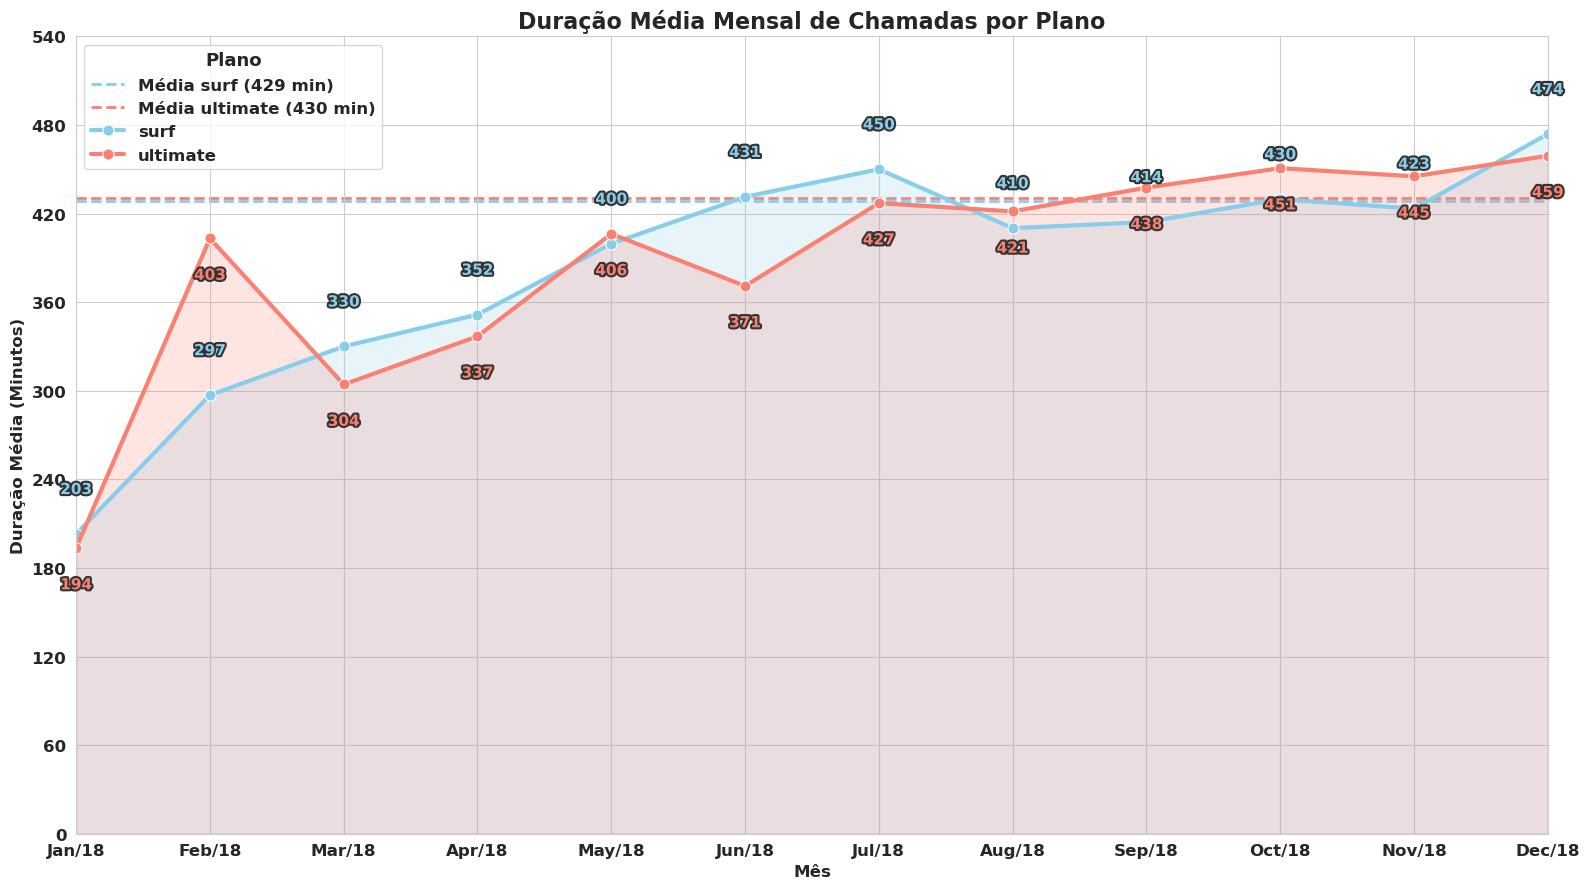

In [814]:
print('''\n------------------------------------------------------------------------------
# PASSO 2: CRIANDO O GRÁFICO DE LINHAS COM SEABORN
------------------------------------------------------------------------------''')

print("✅ 1. Gerando o gráfico de linhas com Seaborn...")

# Plotando o gráfico de linhas com Seaborn

# 1. Definindo o tamanho da figura
plt.figure(figsize=(16, 9))

ax_line_calls=plt.gca()

# 2. Criando o gráfico de linhas
ax_line_calls = sns.lineplot(
    data=group_avg_minutes_monthly,
    x='month_label',
    y='avg_minutes_monthly',
    hue='plan',
    palette=plan_palette,
    marker='o',                 # Adiciona marcadores para cada ponto de dados
    linewidth=3,                # Define a espessura da linha
    markersize=8,               # Define o tamanho dos marcadores
    zorder=2                    # Coloque o zorder maior que o fill_between para as linhas ficarem por cima da área colorida
)

print("✅   - Adicionando o preenchimento de área...")

# Para cada plano, vamos iterar para preencher a área
for plan_name in group_avg_minutes_monthly['plan'].unique():
    # Filtra os dados para o nome do plano atual
    df_plan = group_avg_minutes_monthly[group_avg_minutes_monthly['plan'] == plan_name]
    
    # Obtém a cor do plano a partir do seu palette
    color = plan_palette[plan_name]
    
    # Adiciona o preenchimento de área:
    # x: 'month_label' (posições X)
    # y1: 'avg_minutes_monthly' (limite superior do preenchimento)
    # y2: 0 (limite inferior do preenchimento - o eixo X)
    ax_line_calls.fill_between(
        x=df_plan['month_label'], 
        y1=df_plan['avg_minutes_monthly'], 
        y2=0,
        color=color,        # Cor baseada no palette dos planos
        alpha=0.2,          # Transparência para evitar sobreposição muito escura
        zorder=1            # Garante que fique abaixo da linha (zorder=2) e dos data labels
    )


# 3. Plotando as linhas de média para cada um dos planos

    # A. Calculando a média geral para cada plano
overall_avg = df_agrupado.groupby('plan')['total_minutes_rounded'].mean()

    # B. Plotando as linhas das médias
for plan_name, avg_value in overall_avg.items():
    # Garantindo que a linha tracejada de média esteja abaixo das linhas do gráfico com zorder=0
    ax_line_calls.axhline(y=avg_value, color=plan_palette[plan_name], linestyle='--', linewidth=2, zorder=0, label=f'Média {plan_name} ({avg_value:.0f} min)')
    # Nota: adicionei zorder=0 para garantir que a linha do gráfico fique por cima.

# 4. Adicionando os títulos e rótulos
ax_line_calls.set_title('Duração Média Mensal de Chamadas por Plano', fontsize=16, weight='bold')
ax_line_calls.set_xlabel('Mês',fontsize=12, weight='bold')
ax_line_calls.set_ylabel('Duração Média (Minutos)',fontsize=12, weight='bold')

# Removendo os espaços adicionais nos eixos
ax_line_calls.margins(x=0) # removendo espaços extras do eixo X
ax_line_calls.margins(y=0) # removendo espaços extras do eixo Y


# Ajuste a legenda para incluir as linhas do gráfico e as linhas de média
handles, labels = ax_line_calls.get_legend_handles_labels()
ax_line_calls.legend(handles=handles[2:] + handles[:2], # Reordena para as médias aparecerem depois dos planos na legenda
          labels=labels[2:] + labels[:2], 
          title='Plano', 
          title_fontproperties={'weight': 'bold', 'size': '13'}, 
          prop={'weight': 'bold', 'size': '12'}, 
          loc='upper left')

plt.xticks(rotation=0, fontsize=12, weight='bold')
plt.yticks(range(0,541,60), fontsize=12, weight='bold')

# 5. Adicionando rótulos de dados 
for plan in group_avg_minutes_monthly['plan'].unique():
    # Filtra os dados para o plano atual
    df_plan = group_avg_minutes_monthly[group_avg_minutes_monthly['plan'] == plan]
    
    label_color = plan_palette[plan]

    # Obtém as coordenadas X (posição no eixo) para cada rótulo
    x_positions = [i for i, label in enumerate(df_plan['month_label'])]
    
    # Obtém os valores Y (avg_minutes_monthly)
    y_values = df_plan['avg_minutes_monthly'].values
    
    # Adiciona o rótulo em cada ponto (com uma pequena margem 'y_margin')
    y_margin = 25
    if plan == 'ultimate':
        # Aumenta a margem para separar o rótulo de 'ultimate' em Jan/18
        y_margin = -30


    for x, y in zip(x_positions, y_values):
        ax_line_calls.text(x, y + y_margin, # Posição (x, y + margem)
                f'{y:.0f}',       # Texto do rótulo
                color=label_color, 
                ha='center',      # Alinhamento horizontal: centralizado
                va='bottom',      # Alinhamento vertical: acima do ponto
                weight='bold', 
                fontsize=11,
                path_effects=[pe.withStroke(linewidth=3, foreground="#333333")],
                zorder=3)

# 6. Exibindo o gráfico
plt.tight_layout()
plt.show()

#### **Gráfico: BARRAS**


------------------------------------------------------------------------------
# PASSO 2: CRIANDO O GRÁFICO DE BARRAS COM SEABORN
------------------------------------------------------------------------------
✅ 1. Gerando o gráfico de barras com Seaborn...


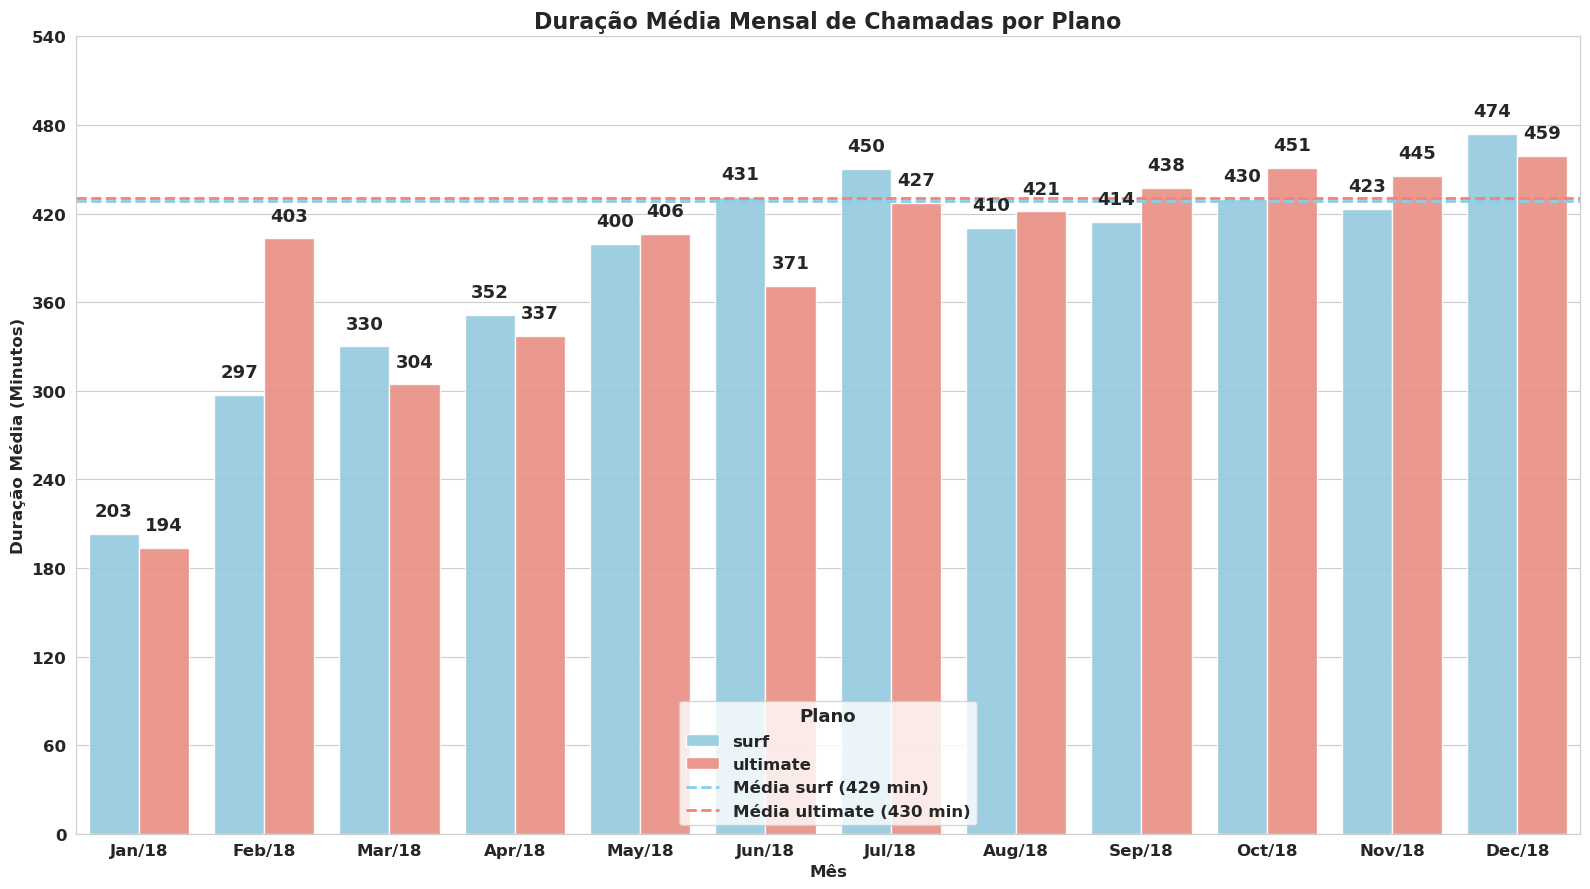

In [815]:
print('''\n------------------------------------------------------------------------------
# PASSO 2: CRIANDO O GRÁFICO DE BARRAS COM SEABORN
------------------------------------------------------------------------------''')

print("✅ 1. Gerando o gráfico de barras com Seaborn...")

# Plotando o gráfico de barras com Seaborn

sns.set_style('whitegrid') 

# 1. Definindo o tamanho da figura
plt.figure(figsize=(16, 9))

# 2. Criando o gráfico de barrasalpha
ax = sns.barplot(
    data=group_avg_minutes_monthly,
    x='month_label',
    y='avg_minutes_monthly',
    hue='plan',
    alpha=0.9,
    palette=plan_palette
)

# 3. Plotando as linhas de média para cada um dos planos

    # A. Calculando a média geral para cada plano
overall_avg = df_agrupado.groupby('plan')['total_minutes_rounded'].mean()

    # B. Plotando as linhas das médias
for plan_name, avg_value in overall_avg.items():
    ax.axhline(y=avg_value, color=plan_palette[plan_name], linestyle='--', linewidth=2, label=f'Média {plan_name} ({avg_value:.0f} min)')

# 4. Adicionando os títulos e rótulos
ax.set_title('Duração Média Mensal de Chamadas por Plano', fontsize=16, weight='bold')
ax.set_xlabel('Mês',fontsize=12, weight='bold')
ax.set_ylabel('Duração Média (Minutos)',fontsize=12, weight='bold')
ax.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': 'bold', 'size': '12'}, loc='lower center')

plt.xticks(rotation=0, fontsize=12, weight='bold')
plt.yticks(range(0,541,60), fontsize=12, weight='bold')

# 5. Adicionando rótulos de dados nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', weight='bold', size=13, padding=10)
    

# 6. Exibindo o gráfico

plt.tight_layout() # Ajusta o layout para evitar que os labels se sobreponham
plt.show()

#### **Gráfico: HISTOGRAMA**

📶 Criando o Histograma da Distribuição de Minutos
   ✅ 1. Gerando o HISTOGRAMA para comparar a DISTRIBUIÇÃO DE MINUTOS...


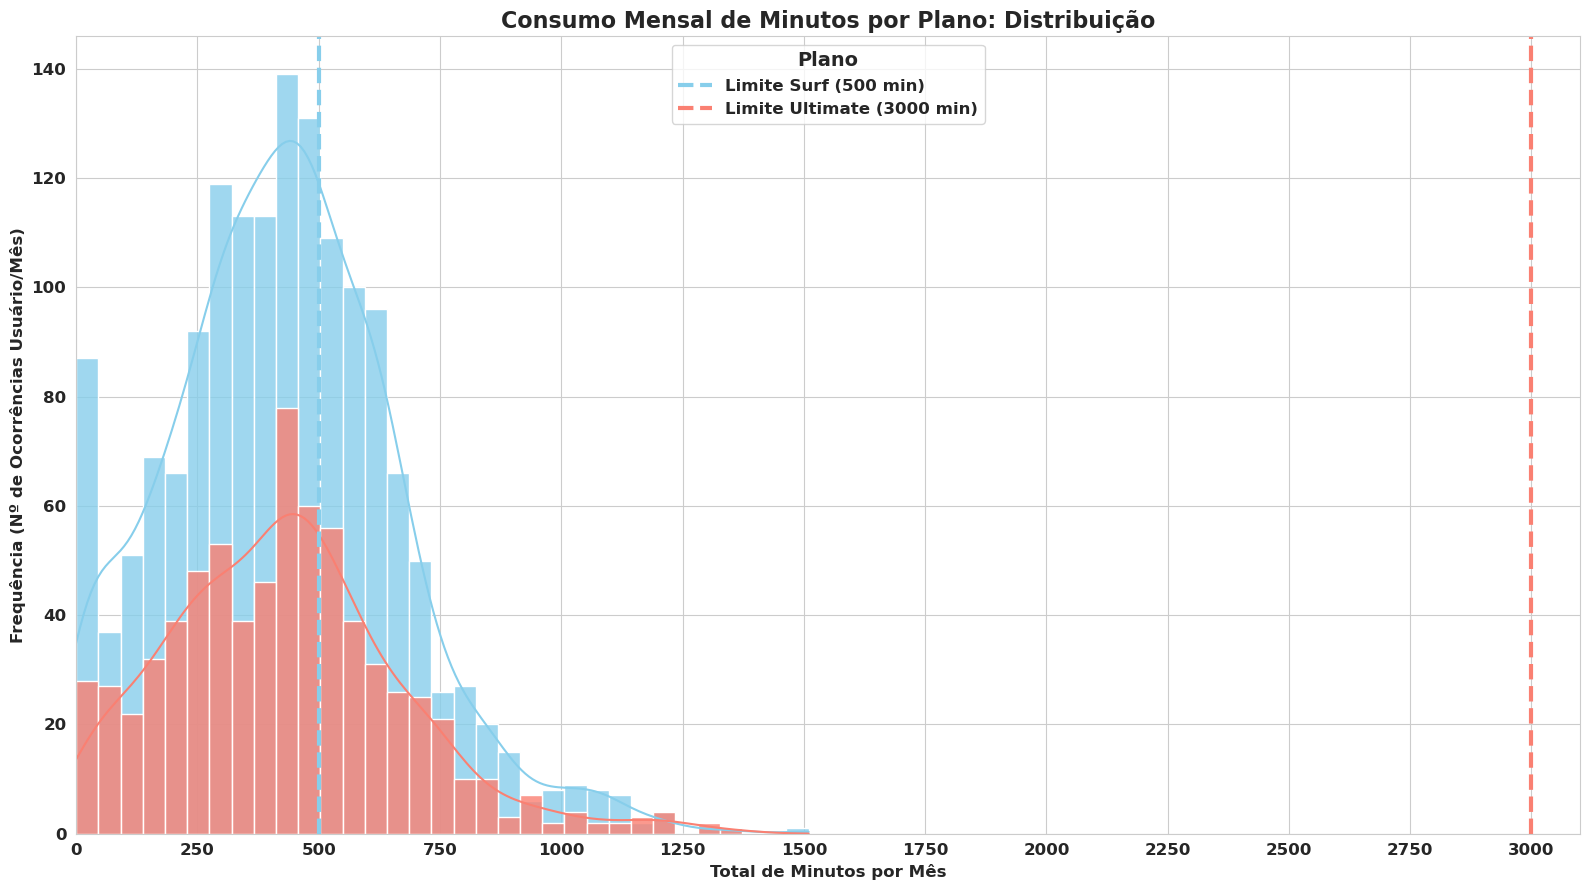

   🔍 2. Dando um ZOOM no histograma para facilitar a visualização...


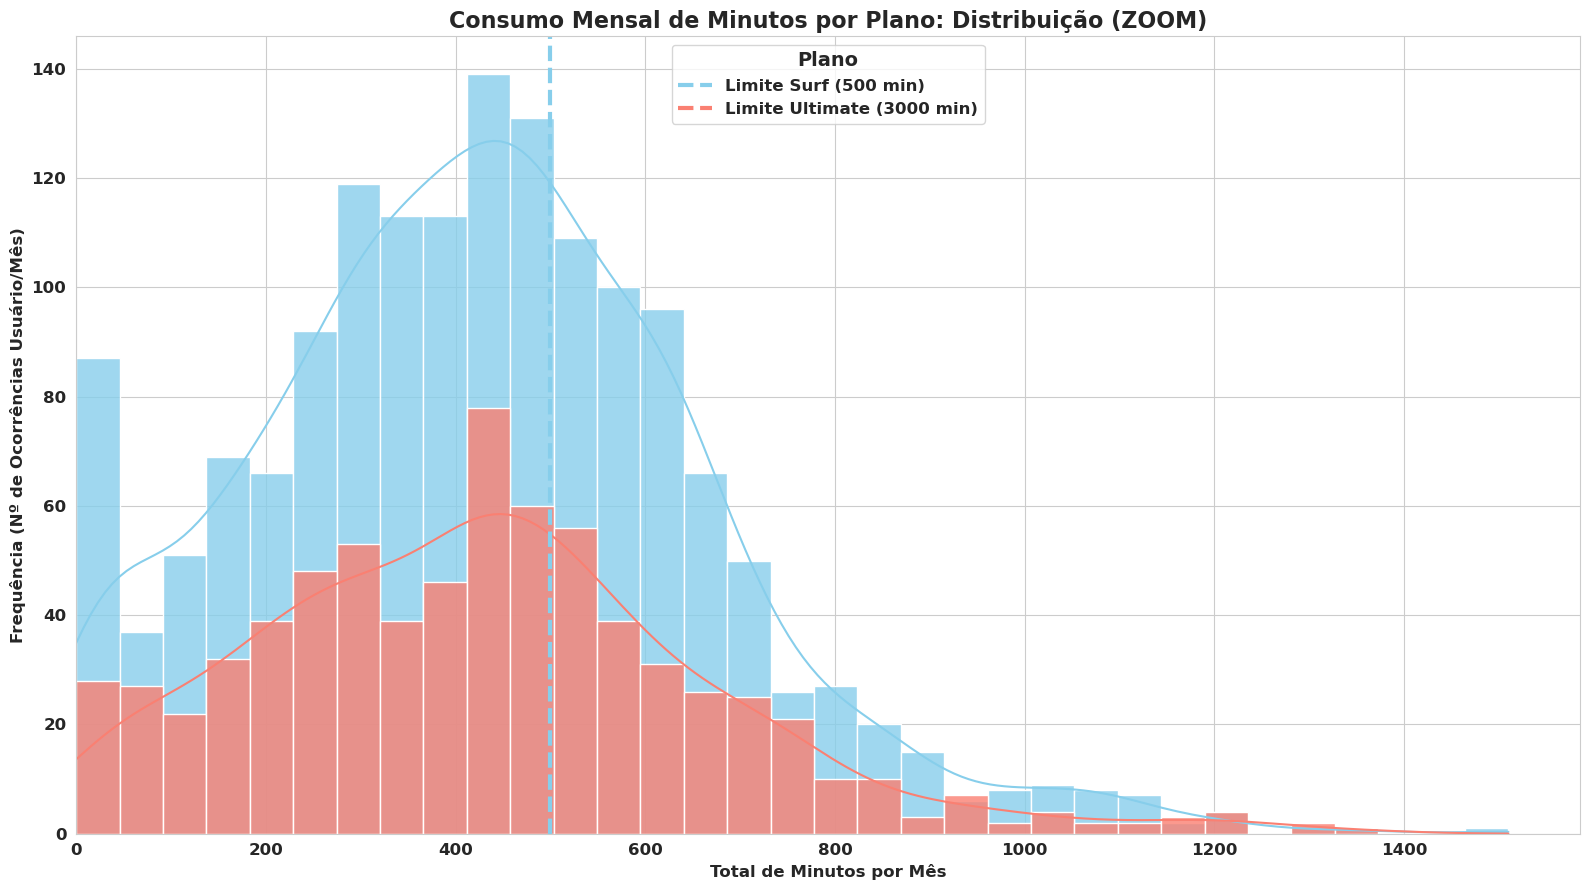

In [816]:
# Aqui iremos comparar se a demanda por minutos dos usuários é diferente entre os planos.
# Iremos construir um histograma e analisar as estatísticas da distruição de minutos por plano.

print('📶 Criando o Histograma da Distribuição de Minutos')
print('='*70)

#-------------------------------------------------------
print("   ✅ 1. Gerando o HISTOGRAMA para comparar a DISTRIBUIÇÃO DE MINUTOS...")
print('='*70)

# 1. Definindo o tamanho da figura
plt.figure(figsize=(16, 9))

# Criando o histograma com o 'hue' para separar os planos
ax_hist = sns.histplot(
    data=df_agrupado,
    x='total_minutes_rounded',
    hue='plan',
    palette=plan_palette,
    alpha=0.8,
    kde=True # Adicionando uma linha de densidade para melhor visualização da distribuição
    )

# --- Customização do histograma ---
ax_hist.set_title('Consumo Mensal de Minutos por Plano: Distribuição', fontsize=16, weight='bold')
ax_hist.set_xlabel('Total de Minutos por Mês', fontsize=12, weight='bold')
ax_hist.set_ylabel('Frequência (Nº de Ocorrências Usuário/Mês)', fontsize=12, weight='bold')
plt.xticks(range(0,3101,250),fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax_hist.set_xlim(left=0,right=3100)


# Adiciona as linhas de limite com o parâmetro 'label'
ax_hist.axvline(x=500, color=plan_palette['surf'], linestyle='--', linewidth=3, label='Limite Surf (500 min)')
ax_hist.axvline(x=3000, color=plan_palette['ultimate'], linestyle='--', linewidth=3, label='Limite Ultimate (3000 min)')

# Pede ao Matplotlib para criar a legenda com todos os itens que têm um 'label'
ax_hist.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '14'}, prop={'weight': 'bold', 'size': '12'}, loc='upper center')


plt.tight_layout()
plt.show()

print('='*70)

#--------------------------------------------------------------------------------
print("   🔍 2. Dando um ZOOM no histograma para facilitar a visualização...")
print('='*70)

# 1. Definindo o tamanho da figura
plt.figure(figsize=(16, 9))

# Criando o histograma com o 'hue' para separar os planos
ax_hist = sns.histplot(
    data=df_agrupado,
    x='total_minutes_rounded',
    hue='plan',
    palette=plan_palette,
    alpha=0.8,
    kde=True # Adicionando uma linha de densidade para melhor visualização da distribuição
    )

# --- Customização do histograma ---
ax_hist.set_title('Consumo Mensal de Minutos por Plano: Distribuição (ZOOM)', fontsize=16, weight='bold')
ax_hist.set_xlabel('Total de Minutos por Mês', fontsize=12, weight='bold')
ax_hist.set_ylabel('Frequência (Nº de Ocorrências Usuário/Mês)', fontsize=12, weight='bold')
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax_hist.set_xlim(left=0)


# Adiciona as linhas de limite com o parâmetro 'label'
ax_hist.axvline(x=500, color=plan_palette['surf'], linestyle='--', linewidth=3, label='Limite Surf (500 min)')
ax_hist.axvline(x=3000, color=plan_palette['ultimate'], linestyle='--', linewidth=3, label='Limite Ultimate (3000 min)')

# Pede ao Matplotlib para criar a legenda com todos os itens que têm um 'label'
ax_hist.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '14'}, prop={'weight': 'bold', 'size': '12'}, loc='upper center')


plt.tight_layout()
plt.show()

print('='*70)


In [817]:
print("   🔢 3. Análise Descritiva: Consumo de Minutos por Plano")
print('='*70)

# Selecionando os minutos para cada plano com nosso filtro 
filtro_minutes_surf = df_agrupado['total_minutes_rounded'][df_agrupado['plan'] == 'surf']
filtro_minutes_ultimate = df_agrupado['total_minutes_rounded'][df_agrupado['plan'] == 'ultimate']

print()

# Imprimindo os resumos estatísticos das distriuições
print('-'*70)
print('🏄🏻‍♂️ Plano Surf: Distribuição dos Minutos:')
print('-'*70)
print(filtro_minutes_surf.describe())

print()

print('-'*70)
print('👑 Plano Ultimate: Distribuição dos Minutos:')
print('-'*70)
print(filtro_minutes_ultimate.describe())

   🔢 3. Análise Descritiva: Consumo de Minutos por Plano

----------------------------------------------------------------------
🏄🏻‍♂️ Plano Surf: Distribuição dos Minutos:
----------------------------------------------------------------------
count    1573.000000
mean      428.749523
std       234.453150
min         0.000000
25%       272.000000
50%       425.000000
75%       576.000000
max      1510.000000
Name: total_minutes_rounded, dtype: float64

----------------------------------------------------------------------
👑 Plano Ultimate: Distribuição dos Minutos:
----------------------------------------------------------------------
count     720.000000
mean      430.450000
std       240.508762
min         0.000000
25%       260.000000
50%       424.000000
75%       565.250000
max      1369.000000
Name: total_minutes_rounded, dtype: float64


In [818]:
# Aqui iremos explorar se a média e a variância dos planos são idênticas ou não.


# Selecionando os minutos para cada plano com nosso filtro 
    # filtro_minutes_surf = df_agrupado['total_minutes_rounded'][df_agrupado['plan'] == 'surf']
    # filtro_minutes_ultimate = df_agrupado['total_minutes_rounded'][df_agrupado['plan'] == 'ultimate']

print('='*70)

#---------------------------------------------------------
print('🔢 Imprimindo a média  e a variância dos minutos arredondados...')
print('='*70)

print()

#surf
surf_mean = filtro_minutes_surf.mean()
surf_var = filtro_minutes_surf.var()

# ultimate
ultimate_mean = filtro_minutes_ultimate.mean()
ultimate_var = filtro_minutes_ultimate.var()


# Imprimindo a média e a variância para cada plano
print('-'*70)
print('🏄🏻‍♂️ Plano Surf:')
print('-'*70)
print('Média (μ)',surf_mean)
print('Variância (σ²)',surf_var)
print('Desvio Padrão (σ)',math.sqrt(surf_var))

print()

print('-'*70)
print('👑 Plano Ultimate: Distribuição dos Minutos:')
print('-'*70)
print('Média (μ)',ultimate_mean)
print('Variância (σ²)',ultimate_var)
print('Desvio Padrão (σ)',math.sqrt(ultimate_var))

🔢 Imprimindo a média  e a variância dos minutos arredondados...

----------------------------------------------------------------------
🏄🏻‍♂️ Plano Surf:
----------------------------------------------------------------------
Média (μ) 428.7495232040687
Variância (σ²) 54968.27946065032
Desvio Padrão (σ) 234.4531498202793

----------------------------------------------------------------------
👑 Plano Ultimate: Distribuição dos Minutos:
----------------------------------------------------------------------
Média (μ) 430.45
Variância (σ²) 57844.4648122392
Desvio Padrão (σ) 240.50876244378125


#### **Gráfico: BOXPLOT**

📦 Criando o Boxplot da Distribuição de Minutos
   ✅ 1. Gerando o BOXPLOT para comparar a DISTRIBUIÇÃO DE MINUTOS...


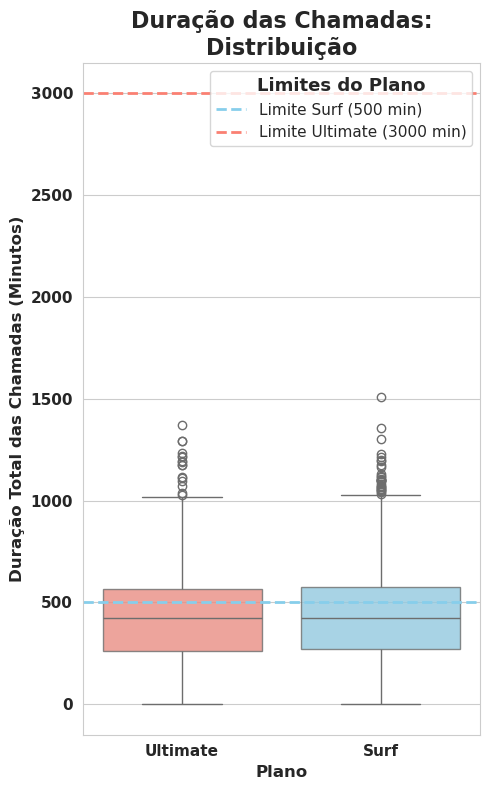

   🔍 2. Dando um ZOOM em nosso boxplot...


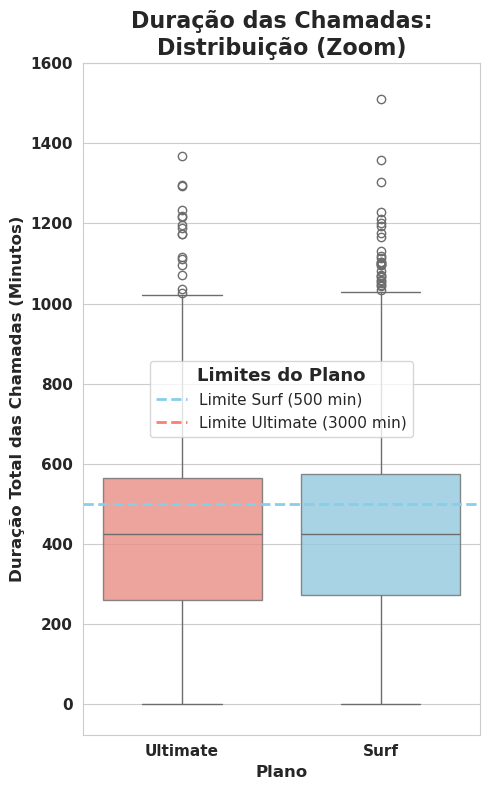

In [819]:
# Aqui iremos visualizar a distribuição da duração das chamadas através do BOXPLOT para os dois planos


print('📦 Criando o Boxplot da Distribuição de Minutos')
print('='*70)

#-------------------------------------------------------
print("   ✅ 1. Gerando o BOXPLOT para comparar a DISTRIBUIÇÃO DE MINUTOS...")
print('='*70)


# Preparando os dados antes de plotar

# Criando uma cópia para não modificar o DataFrame original e capitaliza nomes dos planos
df_plot = df_agrupado.copy()
df_plot['plan'] = df_plot['plan'].str.capitalize()


# 1. Definindo o tamanho da figura
plt.figure(figsize=(5, 8))

# Criando o boxplot com Seaborn
ax_box = sns.boxplot(
    data=df_plot,
    x='plan',
    y='total_minutes_rounded',
    hue='plan',
    boxprops={'alpha': 0.8},
    palette=plan_palette_c
    )

# Customizando o boxplot
ax_box.set_title(f'Duração das Chamadas:\nDistribuição', fontsize=16, weight='bold')
ax_box.set_xlabel('Plano', fontsize=12, weight='bold')
ax_box.set_ylabel('Duração Total das Chamadas (Minutos)', fontsize=12, weight='bold')


# Adicionando linhas horizontais para os limites dos planos
ax_box.axhline(y=500, color=plan_palette_c['Surf'], linestyle='--', linewidth=2, label='Limite Surf (500 min)')
ax_box.axhline(y=3000, color=plan_palette_c['Ultimate'], linestyle='--', linewidth=2, label='Limite Ultimate (3000 min)')

# Adicionando a legenda para as linhas de limite
ax_box.legend(title='Limites do Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': '500', 'size': '11'}, loc='upper right')

# Aumentando a fonte dos ticks
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

print('='*70)

#-------------------------------------------------------
print("   🔍 2. Dando um ZOOM em nosso boxplot...")
print('='*70)

# 1. Definindo o tamanho da figura
plt.figure(figsize=(5, 8))

# Criando o boxplot com Seaborn
ax_box_z = sns.boxplot(
    data=df_plot,
    x='plan',
    y='total_minutes_rounded',
    hue='plan',
    boxprops={'alpha': 0.8},
    palette=plan_palette_c
    )

# Customizando o boxplot
ax_box_z.set_title('Duração das Chamadas:\nDistribuição (Zoom)', fontsize=16, weight='bold')
ax_box_z.set_xlabel('Plano', fontsize=12, weight='bold')
ax_box_z.set_ylabel('Duração Total das Chamadas (Minutos)', fontsize=12, weight='bold')

# Aplicando o corte para o zoom
ax_box_z.set_ylim(top=1600)

# Adicionando linhas horizontais para os limites dos planos
ax_box_z.axhline(y=500, color=plan_palette_c['Surf'], linestyle='--', linewidth=2, label='Limite Surf (500 min)')
ax_box_z.axhline(y=3000, color=plan_palette_c['Ultimate'], linestyle='--', linewidth=2, label='Limite Ultimate (3000 min)')

# Adicionando a legenda para as linhas de limite
ax_box_z.legend(title='Limites do Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': '500', 'size': '11'}, loc='center')

# Aumentando a fonte dos ticks
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

#### 💡 **Conclusão: Análise de Comportamento de Chamadas por Plano**

Apesar de a **média de consumo** de minutos ser **praticamente a mesma** entre os usuários dos planos Surf e Ultimate, o comportamento dos usuários em relação aos **limites de seus planos** é o que realmente os diferencia.

**1. Comportamento Médio de Consumo Semelhantes:**
- Conforme os dados descritivos e o gráfico de barras, a duração média mensal de chamadas para ambos os planos é quase idêntica (aproximadamente **436 minutos** para o Surf e **435 minutos** para o Ultimate). 
- Isso significa que:
  - Na média, os usuários de ambos os planos tem **consumos quase idênticos**.
  - O plano "premium" não atrai necessariamente usuários que falam mais.

**2. Relação com os Limites dos Planos e Implicações na Receita:**
- A principal diferença de comportamento aparece quando observarmos a distribuição do consumo nos histogramas e boxplots:

- 🏄🏻‍♂️ **Usuários Surf:** 
    - ⚠️ A distribuição de consumo está fortemente concentrada **em torno do limite de 500 minutos**. 
    - O boxplot mostra que **50%** desses usuários consomem entre **279 e 579 minutos**, com a **mediana em 430 minutos**.
    - Isso significa que **uma parcela significativa** de clientes Surf frequentemente **ultrapassam o limite**, gerando **receita adicional** para a empresa.
    - A presença de muitos outliers acima do limite reforça essa tendência.

- 👑 **Usuários Ultimate:**
    - ⬇️ Ao contrário, a distribuição de consumo dos usuários Ultimate está **muito abaixo do limite de 3.000 minutos**. 
    - O boxplot confirma que praticamente todos desse grupo operam com uma **margem de segurança enorme**, sem nunca se aproximar do teto do plano. 
    - Para esses usuários, o plano Ultimate funciona como um "seguro" que oferece tranquilidade, e não como uma necessidade baseada em alto consumo.

**Conclusão Final:** 
- A diferença no comportamento dos usuários entre os planos não está em quanto falam, mas na motivação por trás do uso de cada plano: 
  - 🏄🏻‍♂️ Os clientes do plano **Surf** se arriscam em **exceder os limites para pagar menos**, gerando **receita variável recorrente** para a empresa.
  - 👑 Já os clientes **Ultimate** pagam um valor fixo maior para terem **mais conveniência e e evitar surpresas**, o que gera uma **receita mensal estável** e previsível para a Megaline.

---

### ✉️ **Mensagens**

In [820]:
# Comparando o número de mensagens que os usuários de cada plano costumam enviar a cada mês

print('↔️ Comparando o número de mensagens que os usuários de cada plano enviam a cada mês')

print(f'''------------------------------------------------------------------------------
# PASSO 1: CALCULANDO A MÉDIA MENSAL DE MENSAGENS POR PLANO USANDO .GROUPBY() E .AGG() 
------------------------------------------------------------------------------''')

print('\n1. Calculando o número médio de mensagens por plano e por mês...')

# Agrupando por plano e por mês e calculando a média
group_avg_messages_monthly = df_agrupado.groupby(
    ['plan', 'month'], as_index=False
).agg(
    avg_messages_monthly=('message_count', 'mean')
)

# Criando uma coluna com a data corrigida em nosso df para visualização
group_avg_messages_monthly['month_label'] = group_avg_messages_monthly['month'].dt.strftime('%b/%y').str.capitalize()

print("Resultado do Groupby:")
print(group_avg_messages_monthly.head())
print(' ✅ SUCESSO!\n')


# ------------------------------------------------------------------------------
print('-'*70)
print('2. Renomenando nossas colunas...')
group_avg_messages_monthly_view = group_avg_messages_monthly.rename(columns={
    'plan': 'Plano',
    'month': 'Mês',
    'avg_messages_monthly': 'Número de Mensagens Médio'
}).copy()
print(group_avg_messages_monthly_view.columns)
print(' ✅ SUCESSO!\n')


# ------------------------------------------------------------------------------
print('-'*70)
print('3. Visualizando o resultado:')

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
group_avg_messages_monthly_view['Mês'] = group_avg_messages_monthly_view['Mês'].dt.to_timestamp()

# --- Função para colorir por Plano --- #
def color_by_plan(column):
    return column.map(lambda plan_name: f'background-color: {plan_palette.get(plan_name, "#FFFFFF")}')

display(group_avg_messages_monthly_view.style
        .bar(subset=['Número de Mensagens Médio'], color="#1565C0", align='mid')
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .format({'Mês': '{:%b/%y}',
        'Número de Mensagens Médio': '{:.2f}'})
        .apply(color_by_plan, subset=['Plano']) 
        .set_properties(subset=['Plano'], **{'color': 'black'})
        .set_properties(**{'text-align': 'center'})
        .set_properties(subset=['Número de Mensagens Médio'], **{'text-align': 'right'})
        .set_table_styles(table_styles)
        .set_caption("✉️ Média Mensal de Mensagens por Plano")
        .hide()
        .hide(subset='month_label', axis='columns'))


# ------------------------------------------------------------------------------
print('-'*70)
print('\n4. Calculando a média mensal agregada de mensagens:')

filtro_surf = df_agrupado['plan'] == 'surf'
filtro_ultimate = df_agrupado['plan'] == 'ultimate'

avg_msg_surf = df_agrupado[filtro_surf]['message_count'].mean()
avg_msg_ultimate = df_agrupado[filtro_ultimate]['message_count'].mean()

print(f'''  A  média mensal de mensagens agregada por plano é:
    - 🏄🏻‍♂️ SURF: {avg_msg_surf:.2f} mensagens
    - 👑 ULTIMATE: {avg_msg_ultimate:.2f} mensagens''')

↔️ Comparando o número de mensagens que os usuários de cada plano enviam a cada mês
------------------------------------------------------------------------------
# PASSO 1: CALCULANDO A MÉDIA MENSAL DE MENSAGENS POR PLANO USANDO .GROUPBY() E .AGG() 
------------------------------------------------------------------------------

1. Calculando o número médio de mensagens por plano e por mês...
Resultado do Groupby:
   plan    month  avg_messages_monthly month_label
0  surf  2018-01             10.500000      Jan/18
1  surf  2018-02             12.000000      Feb/18
2  surf  2018-03             15.260870      Mar/18
3  surf  2018-04             17.400000      Apr/18
4  surf  2018-05             24.012987      May/18
 ✅ SUCESSO!

----------------------------------------------------------------------
2. Renomenando nossas colunas...
Index(['Plano', 'Mês', 'Número de Mensagens Médio', 'month_label'], dtype='object')
 ✅ SUCESSO!

--------------------------------------------------------------

Plano,Mês,Número de Mensagens Médio
surf,Jan/18,10.50
surf,Feb/18,12.00
surf,Mar/18,15.26
surf,Apr/18,17.40
surf,May/18,24.01
surf,Jun/18,25.30
surf,Jul/18,27.03
surf,Aug/18,28.78
surf,Sep/18,30.76
surf,Oct/18,33.84


----------------------------------------------------------------------

4. Calculando a média mensal agregada de mensagens:
  A  média mensal de mensagens agregada por plano é:
    - 🏄🏻‍♂️ SURF: 31.16 mensagens
    - 👑 ULTIMATE: 37.55 mensagens


#### **Gráfico: BARRAS**


------------------------------------------------------------------------------
# PASSO 2: CRIANDO O GRÁFICO DE BARRAS COM SEABORN
------------------------------------------------------------------------------
✅ 1. Gerando o gráfico de barras com Seaborn...


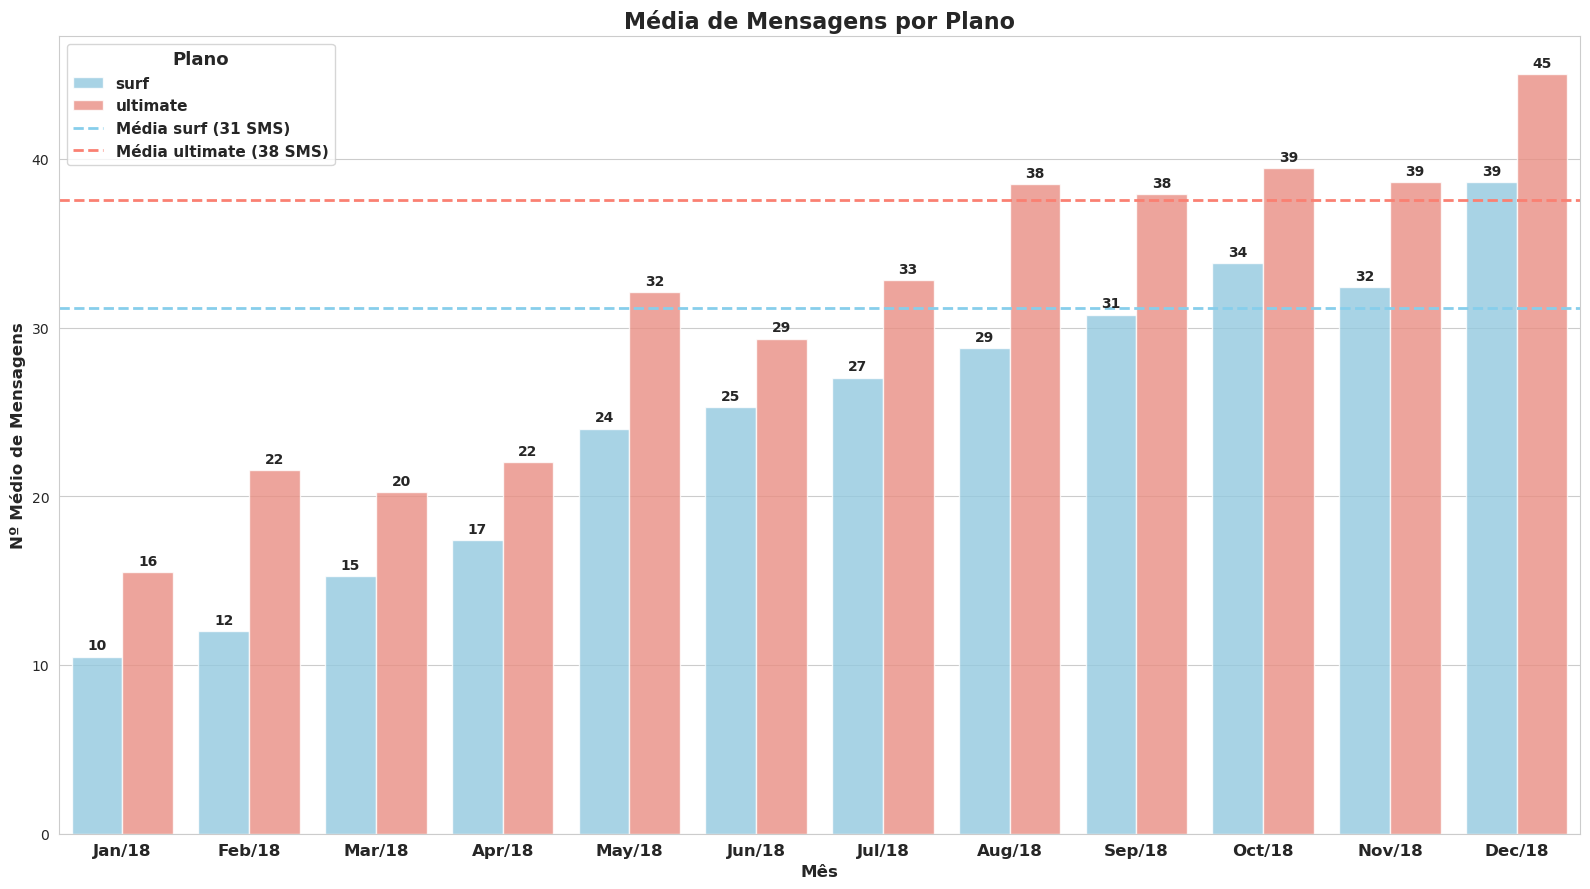

In [821]:
print('''\n------------------------------------------------------------------------------
# PASSO 2: CRIANDO O GRÁFICO DE BARRAS COM SEABORN
------------------------------------------------------------------------------''')

print("✅ 1. Gerando o gráfico de barras com Seaborn...")

# Plotando o gráfico de barras com Seaborn

# 1. Definindo o tamanho da figura
plt.figure(figsize=(16, 9))

# 2. Criando o gráfico de barras
ax_msg = sns.barplot(
    data=group_avg_messages_monthly,
    x='month_label',
    y='avg_messages_monthly',
    hue='plan',
    palette=['skyblue', 'salmon'],
    alpha=0.8
)

# 3. Plotando as linhas de média para cada um dos planos

    # A. Calculando a média geral para cada plano
overall_msg_avg = df_agrupado.groupby('plan')['message_count'].mean()

    # B. Plotando as linhas horizontais de média
for plan_name, avg_value in overall_msg_avg.items():
    ax_msg.axhline(y=avg_value, color=plan_palette[plan_name], linestyle='--', linewidth=2, label=f'Média {plan_name} ({avg_value:.0f} SMS)')

# 4. Adicionando os títulos e rótulos
ax_msg.set_title('Média de Mensagens por Plano', fontsize=16, weight='bold')
ax_msg.set_xlabel('Mês',fontsize=12, weight='bold')
ax_msg.set_ylabel('Nº Médio de Mensagens',fontsize=12, weight='bold')
ax_msg.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': 'bold', 'size': '11'}, loc='upper left')
plt.xticks(rotation=0, fontsize=12, weight='bold')

# 5. Adicionando rótulos de dados nas barras
for container in ax_msg.containers:
    ax_msg.bar_label(container, fmt='%.0f', label_type='edge', weight='bold', size=10, padding=3)
    
# 6. Exibindo o gráfico
plt.tight_layout() # Ajusta o layout para evitar que os labels se sobreponham
plt.show()

#### **Gráfico: HISTOGRAMA**

📶 Criando o Histograma da Distribuição de Mensagens
   ✅ 1. Gerando o HISTOGRAMA para comparar a DISTRIBUIÇÃO DE MENSAGENS...


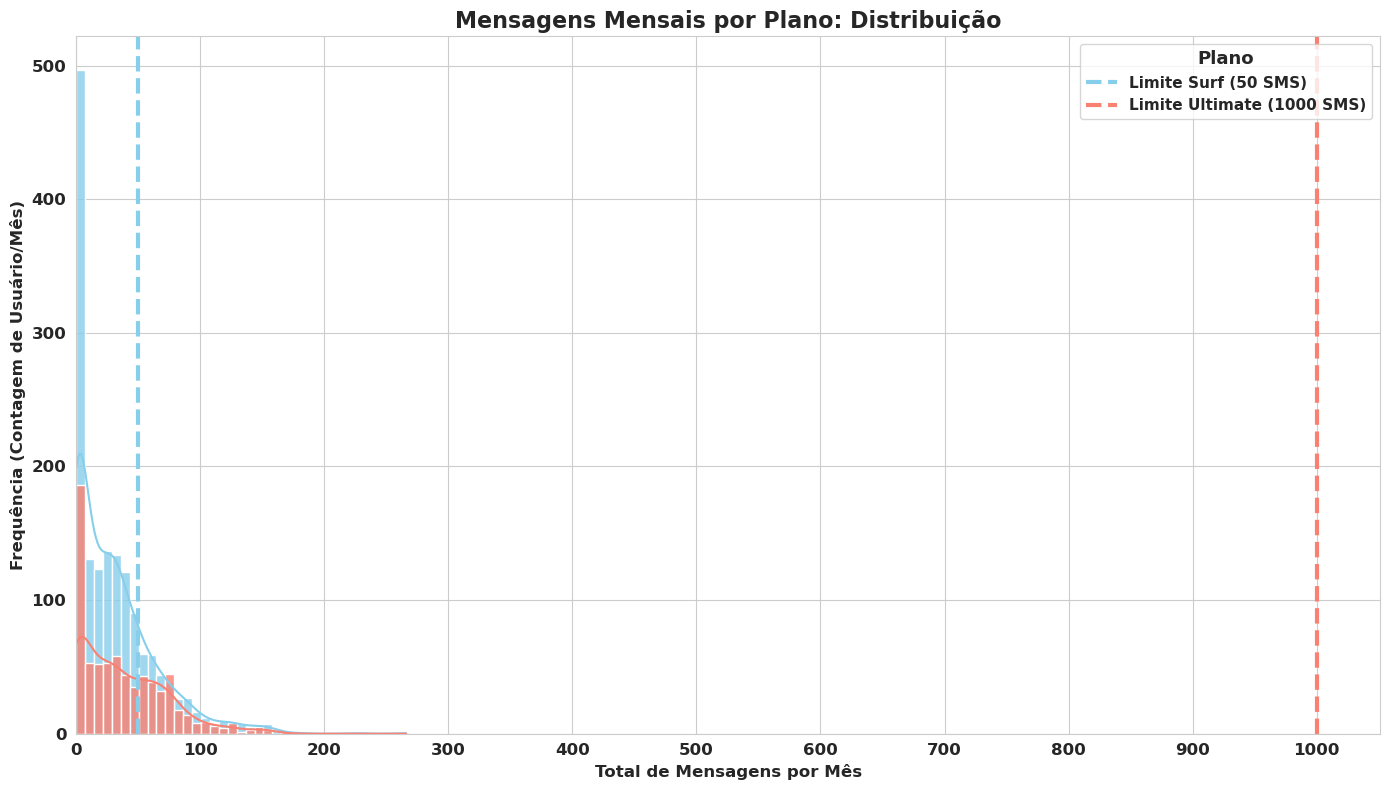

   🔎 2. Dando um ZOOM no histograma...


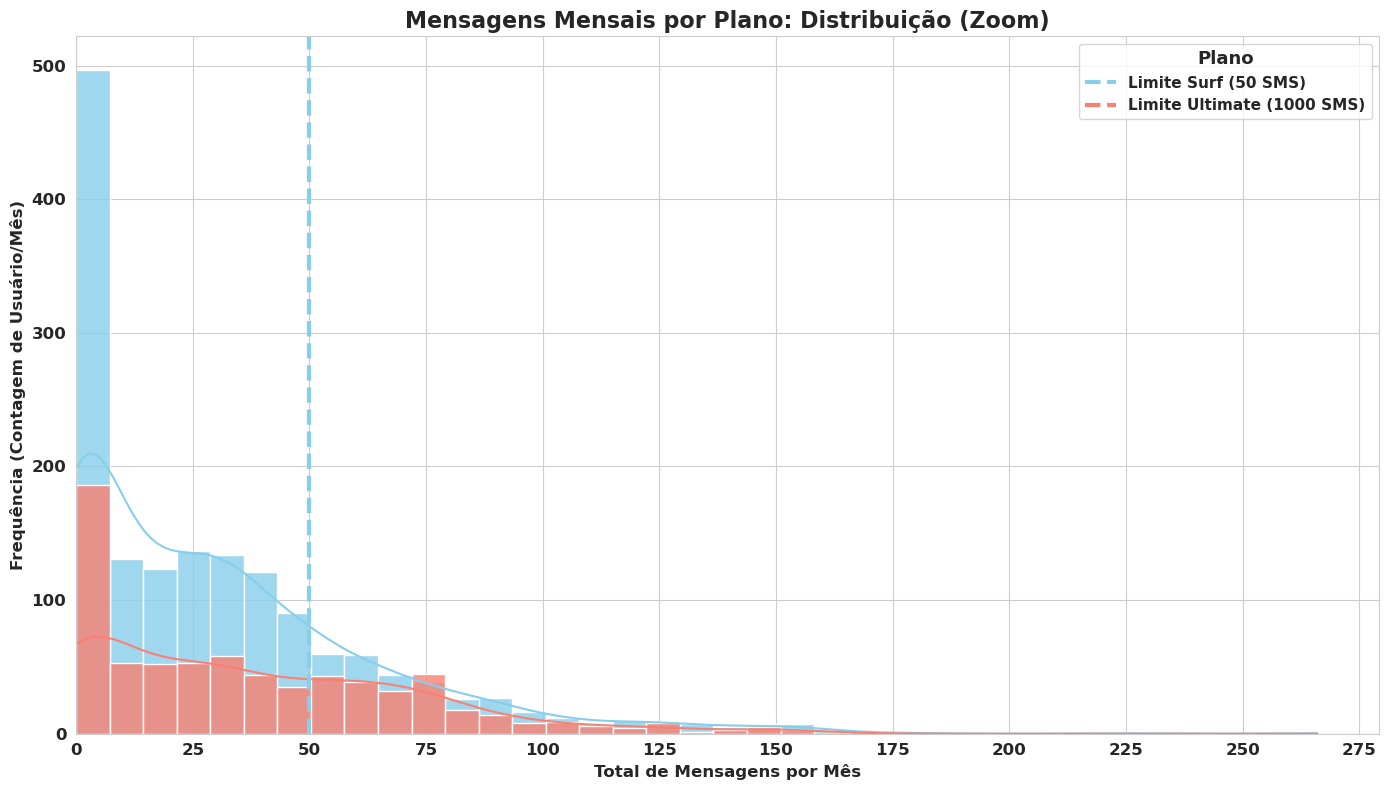

In [822]:
# Aqui iremos comparar se o número de mensagens dos usuários é diferente entre os planos.
# Iremos construir um histograma e analisar as estatísticas da distruição de mensagens por plano.

print('📶 Criando o Histograma da Distribuição de Mensagens')
print('='*70)

#-------------------------------------------------------
print("   ✅ 1. Gerando o HISTOGRAMA para comparar a DISTRIBUIÇÃO DE MENSAGENS...")
print('='*70)

# Criando o histograma com o 'hue' para separar os planos
# 1. Definindo o estilo do gráfico e o tamanho da figura
sns.set_style("whitegrid")
fig_hist, ax_hist_msg = plt.subplots(figsize=(14, 8))

# Criando o histograma com o 'hue' para separar os planos
sns.histplot(
    data=df_agrupado,
    x='message_count',
    hue='plan',
    palette=plan_palette,
    kde=True,
    multiple='layer',
    alpha=0.8,
    ax=ax_hist_msg
)


# --- Customização do histograma ---
ax_hist_msg.set_title('Mensagens Mensais por Plano: Distribuição', fontsize=16, weight='bold')
ax_hist_msg.set_xlabel('Total de Mensagens por Mês', fontsize=12, weight='bold')
ax_hist_msg.set_ylabel('Frequência (Contagem de Usuário/Mês)', fontsize=12, weight='bold')
plt.xticks(range(0,1001,100),fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax_hist_msg.set_xlim(left=0,right=1051)

# Adiciona as linhas de limite com o parâmetro 'label'
ax_hist_msg.axvline(x=50, color=plan_palette['surf'], linestyle='--', linewidth=3, label='Limite Surf (50 SMS)')
ax_hist_msg.axvline(x=1000, color=plan_palette['ultimate'], linestyle='--', linewidth=3, label='Limite Ultimate (1000 SMS)')

# Pede ao Matplotlib para criar a legenda com todos os itens que têm um 'label'
ax_hist_msg.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': 'bold', 'size': '11'}, loc='upper right')

plt.tight_layout()
plt.show()

print('='*70)



#-------------------------------------------------------
print("   🔎 2. Dando um ZOOM no histograma...")
print('='*70)

# ____

# 1. Definindo o estilo do gráfico e o tamanho da figura
sns.set_style("whitegrid")
fig_hist, ax_hist_msg_z = plt.subplots(figsize=(14, 8))

# Criando o histograma com o 'hue' para separar os planos
sns.histplot(
    data=df_agrupado,
    x='message_count',
    hue='plan',
    palette=plan_palette,
    kde=True,
    multiple='layer',
    alpha=0.8,
    ax=ax_hist_msg_z
)

# --- Customização do histograma ---
ax_hist_msg_z.set_title('Mensagens Mensais por Plano: Distribuição (Zoom)', fontsize=16, weight='bold')
ax_hist_msg_z.set_xlabel('Total de Mensagens por Mês', fontsize=12, weight='bold')
ax_hist_msg_z.set_ylabel('Frequência (Contagem de Usuário/Mês)', fontsize=12, weight='bold')
plt.xticks(range(0,276,25),fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax_hist_msg_z.set_xlim(left=0)

# Adiciona as linhas de limite com o parâmetro 'label'
ax_hist_msg_z.axvline(x=50, color=plan_palette['surf'], linestyle='--', linewidth=3, label='Limite Surf (50 SMS)')
ax_hist_msg_z.axvline(x=1000, color=plan_palette['ultimate'], linestyle='--', linewidth=3, label='Limite Ultimate (1000 SMS)')


# Pede ao Matplotlib para criar a legenda com todos os itens que têm um 'label'
ax_hist_msg_z.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': 'bold', 'size': '11'}, loc='upper right')

plt.tight_layout()
plt.show()

In [823]:
# Analise descritiva do consumo de mensagens por plano
print('='*70)

#--------------------------------------------------------------------------------
print("   🔢 3. Análise Descritiva: Consumo de Mensagens por Plano")
print('='*70)

# Selecionando as mensagens para cada plano com nosso filtro 
filtro_msg_surf = df_agrupado['message_count'][df_agrupado['plan'] == 'surf']
filtro_msg_ultimate = df_agrupado['message_count'][df_agrupado['plan'] == 'ultimate']

print()

# Imprimindo os resumos estatísticos das distriuições
print('-'*70)
print('🏄🏻‍♂️ Plano Surf: Distribuição das Mensagens:')
print('-'*70)
print(filtro_msg_surf.describe())

print()

print('-'*70)
print('👑 Plano Ultimate: Distribuição das Mensagens:')
print('-'*70)
print(filtro_msg_ultimate.describe())

   🔢 3. Análise Descritiva: Consumo de Mensagens por Plano

----------------------------------------------------------------------
🏄🏻‍♂️ Plano Surf: Distribuição das Mensagens:
----------------------------------------------------------------------
count    1573.000000
mean       31.159568
std        33.566717
min         0.000000
25%         3.000000
50%        24.000000
75%        47.000000
max       266.000000
Name: message_count, dtype: float64

----------------------------------------------------------------------
👑 Plano Ultimate: Distribuição das Mensagens:
----------------------------------------------------------------------
count    720.000000
mean      37.551389
std       34.767179
min        0.000000
25%        7.000000
50%       30.000000
75%       61.000000
max      166.000000
Name: message_count, dtype: float64


In [824]:
# Aqui iremos explorar se a média e a variância das mensagens são idênticas ou não.

# Selecionando as mensagens para cada plano com nosso filtro 
    # filtro_msg_surf = df_agrupado['message_count'][df_agrupado['plan'] == 'surf']
    # filtro_msg_ultimate = df_agrupado['message_count'][df_agrupado['plan'] == 'ultimate']

print('='*70)

#---------------------------------------------------------
print('🔢 Imprimindo a média e a variância das mensagens...')
print('='*70)

print()

#surf
surf_msg_mean = filtro_msg_surf.mean()
surf_msg_var = filtro_msg_surf.var()

# ultimate
ultimate_msg_mean = filtro_msg_ultimate.mean()
ultimate_msg_var = filtro_msg_ultimate.var()


# Imprimindo a média e a variância para cada plano
print('-'*70)
print('🏄🏻‍♂️ Plano Surf:')
print('-'*70)
print(f'Média (μ):         {surf_msg_mean:.2f}')
print(f'Variância (σ²):    {surf_msg_var:.2f}')
print(f'Desvio Padrão (σ): {math.sqrt(surf_msg_var):.2f}')

print()

print('-'*70)
print('👑 Plano Ultimate:')
print('-'*70)
print(f'Média (μ):         {ultimate_msg_mean:.2f}')
print(f'Variância (σ²):    {ultimate_msg_var:.2f}')
print(f'Desvio Padrão (σ): {math.sqrt(ultimate_msg_var):.2f}')

🔢 Imprimindo a média e a variância das mensagens...

----------------------------------------------------------------------
🏄🏻‍♂️ Plano Surf:
----------------------------------------------------------------------
Média (μ):         31.16
Variância (σ²):    1126.72
Desvio Padrão (σ): 33.57

----------------------------------------------------------------------
👑 Plano Ultimate:
----------------------------------------------------------------------
Média (μ):         37.55
Variância (σ²):    1208.76
Desvio Padrão (σ): 34.77


#### **Gráfico: BOXPLOT**

📦 Criando o Boxplot da Distribuição de Mensagens
   ✅ 1. Gerando o BOXPLOT para comparar a DISTRIBUIÇÃO DO Nº DE MENSAGENS...


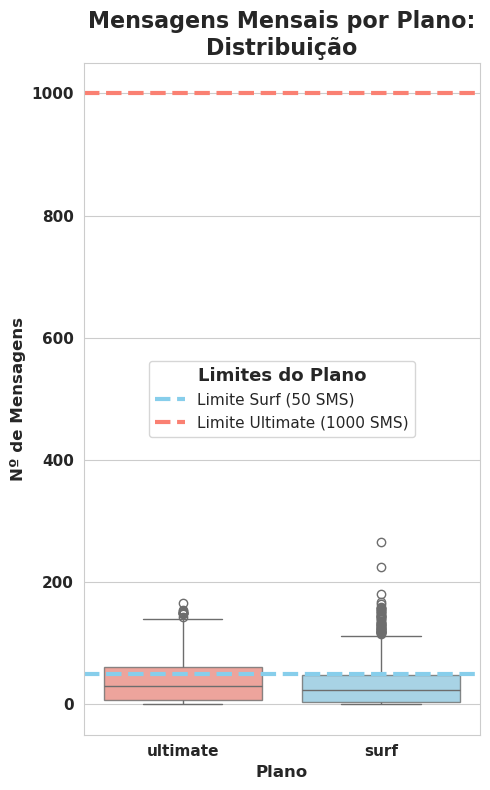

   🔎 2. Dando um ZOOM no histograma...


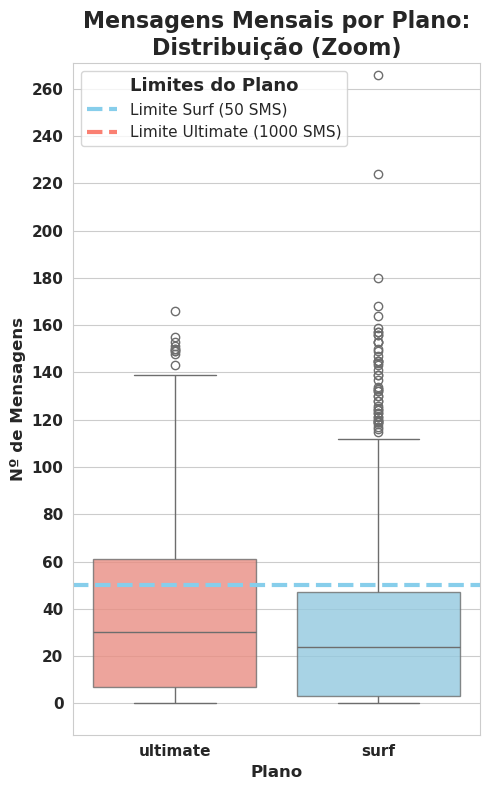

In [825]:
# Aqui iremos visualizar a distribuição da duração das mensagens através do BOXPLOT para os dois planos

print('📦 Criando o Boxplot da Distribuição de Mensagens')
print('='*70)

#-------------------------------------------------------
print("   ✅ 1. Gerando o BOXPLOT para comparar a DISTRIBUIÇÃO DO Nº DE MENSAGENS...")
print('='*70)


# 1. Definindo o estilo do gráfico e o tamanho da figura
sns.set_style("whitegrid")
fig_hist, ax_msg_box = plt.subplots(figsize=(5, 8))

# Criando o histograma com o 'hue' para separar os planos
sns.boxplot(
    data=df_agrupado,
    x='plan',
    y='message_count',
    hue='plan',
    boxprops={'alpha': 0.8},
    palette=plan_palette,
    ax=ax_msg_box
)

# Customizando o boxplot
ax_msg_box.set_title(f'Mensagens Mensais por Plano:\nDistribuição', fontsize=16, weight='bold')
ax_msg_box.set_xlabel('Plano', fontsize=12, weight='bold')
ax_msg_box.set_ylabel('Nº de Mensagens', fontsize=12, weight='bold')

# Adicionando linhas horizontais para os limites dos planos
ax_msg_box.axhline(y=50, color=plan_palette['surf'], linestyle='--', linewidth=3, label='Limite Surf (50 SMS)')
ax_msg_box.axhline(y=1000, color=plan_palette['ultimate'], linestyle='--', linewidth=3, label='Limite Ultimate (1000 SMS)')


# Adicionando a legenda para as linhas de limite
ax_msg_box.legend(title='Limites do Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': '500', 'size': '11'}, loc='center')

# Aumentando a fonte dos ticks
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11, weight='bold')

plt.tight_layout()
plt.show()


print('='*70)
#-------------------------------------------------------
print("   🔎 2. Dando um ZOOM no histograma...")
print('='*70)

# 1. Definindo o estilo do gráfico e o tamanho da figura
sns.set_style("whitegrid")
fig_hist, ax_msg_box_z = plt.subplots(figsize=(5, 8))

# Criando o histograma com o 'hue' para separar os planos
sns.boxplot(
    data=df_agrupado,
    x='plan',
    y='message_count',
    hue='plan',
    boxprops={'alpha': 0.8},
    palette=plan_palette,
    ax=ax_msg_box_z
)

# Customizando o boxplot
ax_msg_box_z.set_title(f'Mensagens Mensais por Plano:\nDistribuição (Zoom)', fontsize=16, weight='bold')
ax_msg_box_z.set_xlabel('Plano', fontsize=12, weight='bold')
ax_msg_box_z.set_ylabel('Nº de Mensagens', fontsize=12, weight='bold')

# Aplicando o corte para o zoom
ax_msg_box_z.set_ylim(top=271)
ax_msg_box_z.set_yticks(range(0,271,20))

# Adicionando linhas horizontais para os limites dos planos
ax_msg_box_z.axhline(y=50, color=plan_palette['surf'], linestyle='--', linewidth=3, label='Limite Surf (50 SMS)')
ax_msg_box_z.axhline(y=1000, color=plan_palette['ultimate'], linestyle='--', linewidth=3, label='Limite Ultimate (1000 SMS)')


# Adicionando a legenda para as linhas de limite
ax_msg_box_z.legend(title='Limites do Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': '500', 'size': '11'}, loc='upper left')

# Aumentando a fonte dos ticks
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

#### 💡 **Conclusão: Análise de Comportamento de Mensagens por Plano**

A média de consumo de mensagens é ligeiramente maior no plano Ultimate (46 vs. 40), mas, na prática, o comportamento de uso é muito semelhante em ambos os grupos. A verdadeira diferença, mais uma vez, está na relação dos usuários com os limites de seus planos e no impacto disso na receita.

1. Comportamento Médio de Consumo Semelhantes:
   - Conforme os dados descritivos e o gráfico de barras, os usuários do Ultimate enviam, em média, apenas um pouco mais de mensagens (aproximadamente 46 mensagens) do que os usuários do Surf (aproximadamente 40 mensagens).

   - Isso significa que:

      - Na média, o consumo de SMS é relativamente baixo em ambos os grupos.

    Ou seja, o envio de mensagens não é um fator decisivo ou um grande atrativo para a escolha de um plano "premium" em detrimento do outro.<br><br>


2. Relação com os Limites dos Planos e Implicações na Receita:

   - A principal diferença de comportamento aparece quando observamos a distribuição do consumo (histogramas) em relação aos limites de cada plano (Surf: 50 msg, Ultimate: 1.000 msg).<br><br>


- **🏄🏻‍♂️ Usuários Surf:**

  - ⚠️ O histograma mostra uma distribuição concentrada em torno do limite de 50 mensagens.

  - Os dados descritivos confirmam isso: embora a mediana seja de 32 mensagens, o percentil 75 está em 54 mensagens.

  - Isso significa que pelo menos 25% dos clientes do plano Surf regularmente ultrapassam o limite de 50 mensagens, gerando receita adicional (taxas de excedente) para a Megaline.

  - A longa cauda de outliers (máx. 266) reforça que o plano é propenso a gerar cobranças extras.


- **👑 Usuários Ultimate:**

  - ⬇️ O comportamento é drasticamente diferente. O limite do plano é de 1.000 mensagens, o que, na prática, é "ilimitado" para o padrão de consumo atual.

  - Os dados descritivos (média de 46, 75% em 66) e o histograma mostram que nenhum usuário chega perto de ameaçar esse limite.

  - O consumo máximo registrado (166 mensagens) ainda está a mais de 80% de distância do teto do plano. Para esses usuários, não há risco de cobrança extra.


**Conclusão Final:**

- A diferença no comportamento dos usuários entre os planos não está no volume de mensagens, mas na gestão do risco de excedentes:

  - 🏄🏻‍♂️ O plano Surf tem um limite baixo (50) que é frequentemente ultrapassado por um quarto dos usuários, criando uma fonte de receita variável para a Megaline.

  - 👑 O plano Ultimate oferece um limite tão alto (1.000) que elimina o atrito do excedente, não gerando receita extra por mensagens, mas garantindo a receita fixa e estável da assinatura.

---

### 🌐 **Internet**

In [826]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano

print('↔️ Comparando o volume de dados mensal consumido pelos usuários por plano')

print(f'''------------------------------------------------------------------------------
# PASSO 1: CALCULANDO A MÉDIA MENSAL DE VOLUME DE DADOS POR PLANO USANDO .GROUPBY() E .AGG() 
------------------------------------------------------------------------------''')

print('\n1. Calculando o volume de dados médio por plano e por mês...')

# Agrupando por plano e por mês e calculando a média
avg_gb_monthly = df_agrupado.groupby(
    ['plan', 'month'], as_index=False
).agg(
    avg_gb=('gb_used_monthly', 'mean')
)

# Criando uma coluna com a data corrigida em nosso df para visualização
avg_gb_monthly['month_label'] = avg_gb_monthly['month'].dt.strftime('%b/%y').str.capitalize()

print("Resultado do Groupby:")
print(avg_gb_monthly.head())
print(' ✅ SUCESSO!\n')


# ------------------------------------------------------------------------------
print('-'*70)
print('2. Renomenando nossas colunas...')
avg_gb_monthly_view = avg_gb_monthly.rename(columns={
    'plan': 'Plano',
    'month': 'Mês',
    'avg_gb': 'GBs Mensais Consumidos'
}).copy()
print(avg_gb_monthly_view.columns)
print(' ✅ SUCESSO!\n')


# ------------------------------------------------------------------------------

print('-'*70)
print('3. Visualizando o resultado:')

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
avg_gb_monthly_view['Mês'] = avg_gb_monthly_view['Mês'].dt.to_timestamp()

# --- Função para colorir por Plano --- #
def color_by_plan(column):
    return column.map(lambda plan_name: f'background-color: {plan_palette.get(plan_name, "#FFFFFF")}')

display(avg_gb_monthly_view.style
        .bar(subset=['GBs Mensais Consumidos'], color="#1565C0", align='mid')
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .format({'Mês': '{:%b/%y}',
        'GBs Mensais Consumidos': '{:.2f}'})
        .apply(color_by_plan, subset=['Plano']) 
        .set_properties(subset=['Plano'], **{'color': 'black'})
        .set_properties(**{'text-align': 'center'})
        .set_properties(subset=['GBs Mensais Consumidos'], **{'text-align': 'right'})
        .set_table_styles(table_styles)
        .set_caption("🌐 Volume de Dados Consumidos por Mês (GB)")
        .hide()
        .hide(subset='month_label', axis='columns'))


# ------------------------------------------------------------------------------
print('-'*70)
print('\n4. Calculando a média mensal agregada de GB consumidos:')

filtro_surf = df_agrupado['plan'] == 'surf'
filtro_ultimate = df_agrupado['plan'] == 'ultimate'

avg_gb_surf = df_agrupado[filtro_surf]['gb_used_monthly'].mean()
avg_gb_ultimate = df_agrupado[filtro_ultimate]['gb_used_monthly'].mean()

print(f'''  A  média mensal de GB consumidos agregada por plano é:
    - 🏄🏻‍♂️ SURF: {avg_gb_surf:.2f} GB
    - 👑 ULTIMATE: {avg_gb_ultimate:.2f} GB''')

↔️ Comparando o volume de dados mensal consumido pelos usuários por plano
------------------------------------------------------------------------------
# PASSO 1: CALCULANDO A MÉDIA MENSAL DE VOLUME DE DADOS POR PLANO USANDO .GROUPBY() E .AGG() 
------------------------------------------------------------------------------

1. Calculando o volume de dados médio por plano e por mês...
Resultado do Groupby:
   plan    month     avg_gb month_label
0  surf  2018-01   5.000000      Jan/18
1  surf  2018-02  12.222222      Feb/18
2  surf  2018-03  13.565217      Mar/18
3  surf  2018-04  12.220000      Apr/18
4  surf  2018-05  14.116883      May/18
 ✅ SUCESSO!

----------------------------------------------------------------------
2. Renomenando nossas colunas...
Index(['Plano', 'Mês', 'GBs Mensais Consumidos', 'month_label'], dtype='object')
 ✅ SUCESSO!

----------------------------------------------------------------------
3. Visualizando o resultado:


Plano,Mês,GBs Mensais Consumidos
surf,Jan/18,5.00
surf,Feb/18,12.22
surf,Mar/18,13.57
surf,Apr/18,12.22
surf,May/18,14.12
surf,Jun/18,15.48
surf,Jul/18,16.88
surf,Aug/18,16.88
surf,Sep/18,16.69
surf,Oct/18,17.41


----------------------------------------------------------------------

4. Calculando a média mensal agregada de GB consumidos:
  A  média mensal de GB consumidos agregada por plano é:
    - 🏄🏻‍♂️ SURF: 16.67 GB
    - 👑 ULTIMATE: 17.31 GB


#### **Gráfico: BARRAS**


------------------------------------------------------------------------------
# PASSO 2: CRIANDO O GRÁFICO DE BARRAS COM SEABORN
------------------------------------------------------------------------------
✅ 1. Gerando o gráfico de barras com Seaborn...


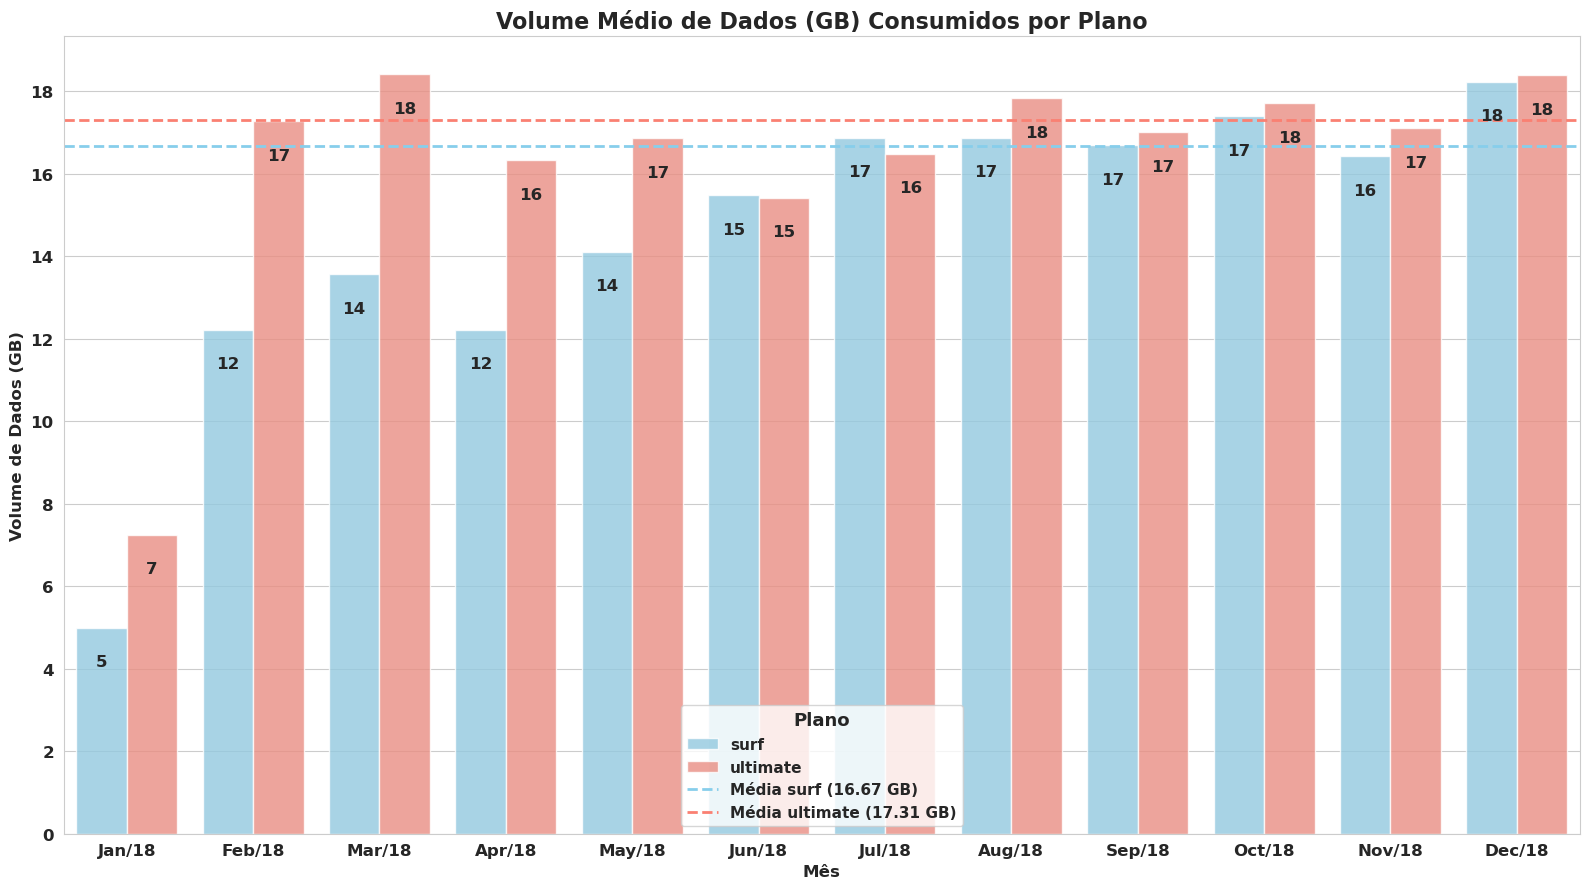

In [827]:
print('''\n------------------------------------------------------------------------------
# PASSO 2: CRIANDO O GRÁFICO DE BARRAS COM SEABORN
------------------------------------------------------------------------------''')

print("✅ 1. Gerando o gráfico de barras com Seaborn...")

# Plotando o gráfico de barras com Seaborn

# 1. Definindo o tamanho da figura
plt.figure(figsize=(16, 9))

# 2. Criando o gráfico de barras
ax_gb = sns.barplot(
    data=avg_gb_monthly,
    x='month_label',
    y='avg_gb',
    hue='plan',
    palette=plan_palette,
    alpha=0.8
)

# 3. Plotando as linhas de média para cada um dos planos

    # A. Calculando a média geral para cada plano
overall_gb_avg = df_agrupado.groupby('plan')['gb_used_monthly'].mean()

    # B. Plotando as linhas horizontais
for plan_name, avg_value in overall_gb_avg.items():
    ax_gb.axhline(y=avg_value, color=plan_palette[plan_name], linestyle='--', linewidth=2, label=f'Média {plan_name} ({avg_value:.2f} GB)')

# 4. Adicionando os títulos e rótulos
ax_gb.set_title('Volume Médio de Dados (GB) Consumidos por Plano', fontsize=16, weight='bold')
ax_gb.set_xlabel('Mês',fontsize=12, weight='bold')
ax_gb.set_ylabel('Volume de Dados (GB)',fontsize=12, weight='bold')
ax_gb.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': 'bold', 'size': '11'}, loc='lower center')

plt.xticks(rotation=0, fontsize=12, weight='bold')
plt.yticks(range(0,20,2), fontsize=12, weight='bold')


# 5. Adicionando rótulos de dados nas barras
for container in ax_gb.containers:
    ax_gb.bar_label(container, fmt='%.0f', label_type='edge', weight='bold', size=12, padding=-30)
    
# 6. Exibindo o gráfico
plt.tight_layout() # Ajusta o layout para evitar que os labels se sobreponham
plt.show()

#### Gráfico: HISTOGRAMA

📶 Criando o Histograma do Consumo de Dados Mensais em GB
   ✅ 1. Gerando o HISTOGRAMA para comparar a DISTRIBUIÇÃO DE INTERNET...


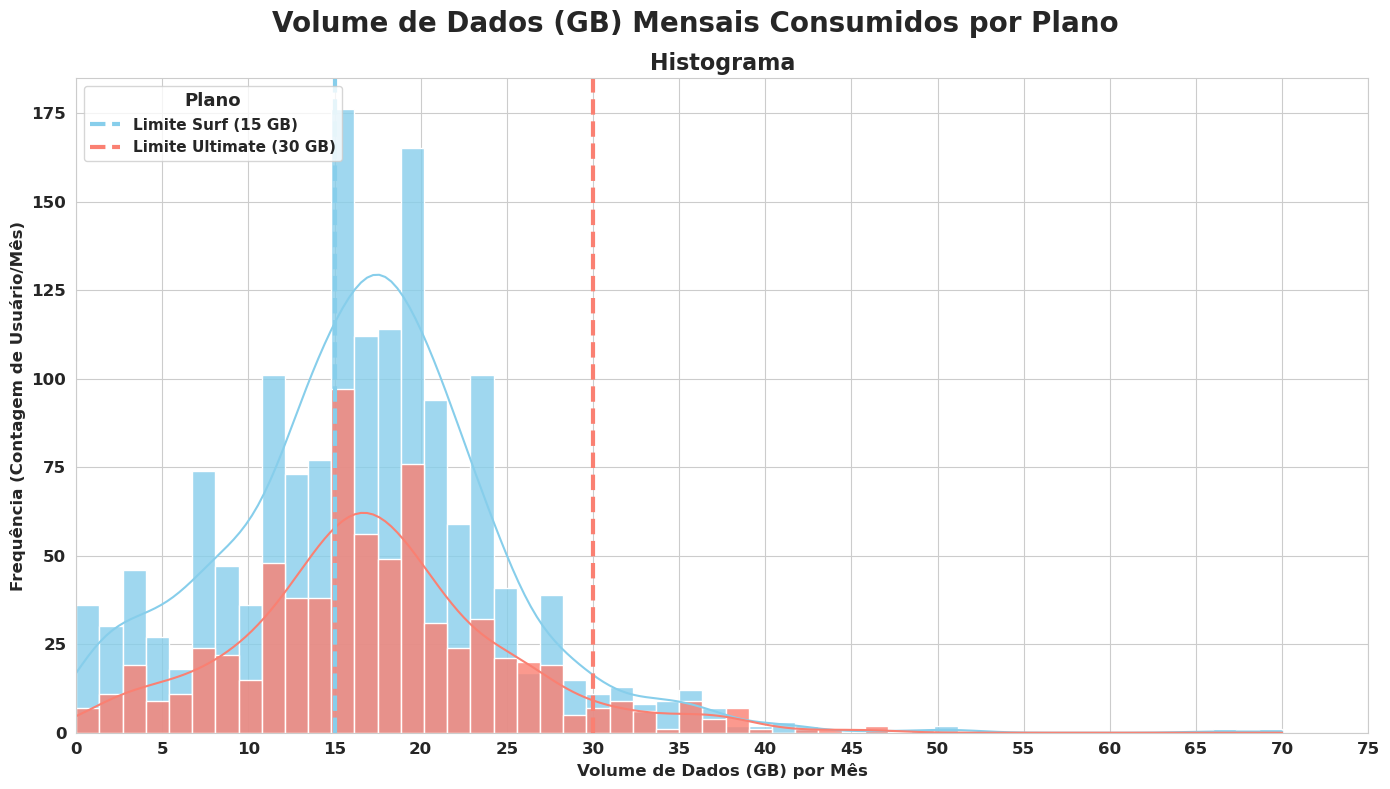

In [828]:
# Aqui iremos comparar se o volume de dados em GB dos usuários é diferente entre os planos.
# Iremos construir um histograma e analisar as estatísticas da distruição de mensagens por plano.

print('📶 Criando o Histograma do Consumo de Dados Mensais em GB')
print('='*70)

#-------------------------------------------------------
print("   ✅ 1. Gerando o HISTOGRAMA para comparar a DISTRIBUIÇÃO DE INTERNET...")
print('='*70)

# Criando o histograma com o 'hue' para separar os planos

# 1. Definindo o estilo do gráfico e o tamanho da figura e título
sns.set_style("whitegrid")
fig_hist, ax_hist_gb = plt.subplots(figsize=(14, 8))
plt.suptitle('Volume de Dados (GB) Mensais Consumidos por Plano', fontsize=20, weight='bold') # Definindo o título

# Criando o histograma com o 'hue' para separar os planos
sns.histplot(
    data=df_agrupado,
    x='gb_used_monthly',
    hue='plan',
    palette=plan_palette,
    kde=True,
    multiple='layer',
    alpha=0.8,
    ax=ax_hist_gb
)

# --- Customização do histograma ---
ax_hist_gb.set_title('Histograma', fontsize=16, weight='bold')
ax_hist_gb.set_xlabel('Volume de Dados (GB) por Mês', fontsize=12, weight='bold')
ax_hist_gb.set_ylabel('Frequência (Contagem de Usuário/Mês)', fontsize=12, weight='bold')
plt.xticks(range(0,76,5),fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax_hist_gb.set_xlim(left=0)


# Adiciona as linhas de limite com o parâmetro 'label'
ax_hist_gb.axvline(x=15, color=plan_palette['surf'], linestyle='--', linewidth=3, label='Limite Surf (15 GB)')
ax_hist_gb.axvline(x=30, color=plan_palette['ultimate'], linestyle='--', linewidth=3, label='Limite Ultimate (30 GB)')

# Pede ao Matplotlib para criar a legenda com todos os itens que têm um 'label'
ax_hist_gb.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': 'bold', 'size': '11'}, loc='upper left')

plt.tight_layout()
plt.show()

In [829]:
# Análise Descritiva: Consumo de Dados (GB) por Plano
print('='*70)
print("   🔢 3. Análise Descritiva: Consumo de Dados (GB) por Plano")
print('='*70)

# Selecionando as mensagens para cada plano com nosso filtro 
filtro_gb_surf = df_agrupado['gb_used_monthly'][df_agrupado['plan'] == 'surf']
filtro_gb_ultimate = df_agrupado['gb_used_monthly'][df_agrupado['plan'] == 'ultimate']

print()

# Imprimindo os resumos estatísticos das distriuições
print('-'*70)
print('🏄🏻‍♂️ Plano Surf: Distribuição dos Dados:')
print('-'*70)
print(filtro_gb_surf.describe())

print()

print('-'*70)
print('👑 Plano Ultimate: Distribuição dos Dados:')
print('-'*70)
print(filtro_gb_ultimate.describe())

   🔢 3. Análise Descritiva: Consumo de Dados (GB) por Plano

----------------------------------------------------------------------
🏄🏻‍♂️ Plano Surf: Distribuição dos Dados:
----------------------------------------------------------------------
count    1573.000000
mean       16.670693
std         7.847522
min         0.000000
25%        12.000000
50%        17.000000
75%        21.000000
max        70.000000
Name: gb_used_monthly, dtype: float64

----------------------------------------------------------------------
👑 Plano Ultimate: Distribuição dos Dados:
----------------------------------------------------------------------
count    720.000000
mean      17.306944
std        7.670108
min        0.000000
25%       13.000000
50%       17.000000
75%       21.000000
max       46.000000
Name: gb_used_monthly, dtype: float64


In [830]:
# Aqui iremos explorar se a média e a variância do volume de dados são idênticas ou não.

# Selecionando as mensagens para cada plano com nosso filtro 
    # filtro_gb_surf = df_agrupado['gb_used_monthly'][df_agrupado['plan'] == 'surf']
    # filtro_gb_ultimate = df_agrupado['gb_used_monthly'][df_agrupado['plan'] == 'ultimate']

print('='*70)

#---------------------------------------------------------
print('🔢 Imprimindo a média e a variância do volume de dados (GB)...')
print('='*70)

print()

#surf
surf_gb_mean = filtro_gb_surf.mean()
surf_gb_var = filtro_gb_surf.var()

# ultimate
ultimate_gb_mean = filtro_gb_ultimate.mean()
ultimate_gb_var = filtro_gb_ultimate.var()


# Imprimindo a média e a variância para cada plano
print('-'*70)
print('🏄🏻‍♂️ Plano Surf:')
print('-'*70)
print(f'Média (μ):         {surf_gb_mean:.2f}')
print(f'Variância (σ²):    {surf_gb_var:.2f}')
print(f'Desvio Padrão (σ): {math.sqrt(surf_gb_var):.2f}')

print()

print('-'*70)
print('👑 Plano Ultimate:')
print('-'*70)
print(f'Média (μ):         {ultimate_gb_mean:.2f}')
print(f'Variância (σ²):    {ultimate_gb_var:.2f}')
print(f'Desvio Padrão (σ): {math.sqrt(ultimate_gb_var):.2f}')

🔢 Imprimindo a média e a variância do volume de dados (GB)...

----------------------------------------------------------------------
🏄🏻‍♂️ Plano Surf:
----------------------------------------------------------------------
Média (μ):         16.67
Variância (σ²):    61.58
Desvio Padrão (σ): 7.85

----------------------------------------------------------------------
👑 Plano Ultimate:
----------------------------------------------------------------------
Média (μ):         17.31
Variância (σ²):    58.83
Desvio Padrão (σ): 7.67


#### Gráfico: BOXPLOT

📦 Criando o Boxplot da Distribuição do Volume de Dados Mensais (GB)
   ✅ 1. Gerando o BOXPLOT para comparar a DISTRIBUIÇÃO DO VOLUME DE DADOS (GB)...


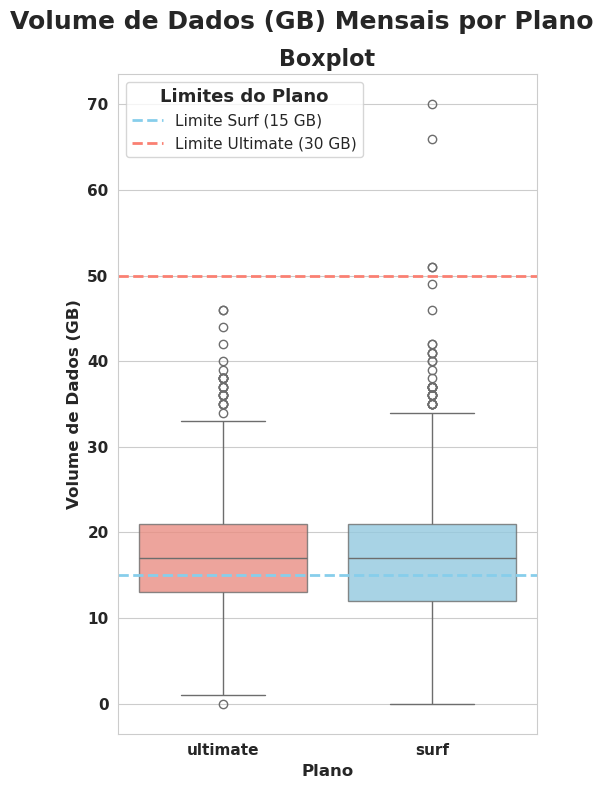

In [831]:
# Aqui iremos visualizar a distribuição do volume mensal de dados em GB através do BOXPLOT para os dois planos

print('📦 Criando o Boxplot da Distribuição do Volume de Dados Mensais (GB)')
print('='*70)

#-------------------------------------------------------
print("   ✅ 1. Gerando o BOXPLOT para comparar a DISTRIBUIÇÃO DO VOLUME DE DADOS (GB)...")
print('='*70)


# 1. Definindo o estilo do gráfico e o tamanho da figura
sns.set_style("whitegrid")
fig_hist, ax_gb_box = plt.subplots(figsize=(5, 8))
plt.suptitle('Volume de Dados (GB) Mensais por Plano', fontsize=18, weight='bold') # Definindo o título

# Criando o histograma com o 'hue' para separar os planos
sns.boxplot(
    data=df_agrupado,
    x='plan',
    y='gb_used_monthly',
    hue='plan',
    boxprops={'alpha': 0.8},
    palette=plan_palette,
    ax=ax_gb_box
)
# Customizando o boxplot
ax_gb_box.set_title(f'Boxplot', fontsize=16, weight='bold')
ax_gb_box.set_xlabel('Plano', fontsize=12, weight='bold')
ax_gb_box.set_ylabel('Volume de Dados (GB)', fontsize=12, weight='bold')

# Adicionando linhas horizontais para os limites dos planos
ax_gb_box.axhline(y=15, color=plan_palette['surf'], linestyle='--', linewidth=2, label='Limite Surf (15 GB)')
ax_gb_box.axhline(y=50, color=plan_palette['ultimate'], linestyle='--', linewidth=2, label='Limite Ultimate (30 GB)')


# Adicionando a legenda para as linhas de limite
ax_gb_box.legend(title='Limites do Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': '500', 'size': '11'}, loc='upper left')

# Aumentando a fonte dos ticks
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

#### 💡**Conclusão: Análise de Comportamento de Internet por Plano**

Esta é a análise mais crucial do projeto. Assim como nas chamadas, a média de consumo de dados é praticamente a mesma (Surf: 16.83 GB, Ultimate: 17.33 GB).

No entanto, a relação desse consumo com os limites de cada plano (Surf: 15 GB, Ultimate: 30 GB) é drasticamente diferente e é o principal motor de receita da empresa.


1. Comportamento Médio de Consumo Semelhantes:

   - Conforme os dados descritivos e o gráfico de barras, o consumo médio mensal de internet para ambos os planos é quase idêntico (aproximadamente 16.83 GB para o Surf e 17.33 GB para o Ultimate).
   - Isso significa que:   
     - Na média, os usuários de ambos os planos têm necessidades de dados quase idênticas.   - O plano "premium" não é escolhido por um consumo de dados significativamente maior, mas sim pela conveniência do limite.<br><br>


2. Relação com os Limites dos Planos e Implicações na Receita:

- A principal diferença de comportamento aparece quando observamos a distribuição do consumo (histogramas e boxplots) em relação aos limites de cada plano:


- 🏄🏻‍♂️ **Usuários Surf:**     
  - ⚠️ O consumo médio (16.83 GB) já está ACIMA do limite de 15 GB do plano.     
  - O boxplot e os dados descritivos confirmam isso: a mediana é de 17 GB e 50% dos usuários consomem entre 12 GB e 21 GB.     
  - Isso significa que mais da metade (50%) dos clientes Surf sistematicamente ultrapassam o limite todo mês, gerando receita adicional substancial para a empresa (a $10 por GB extra).     
  - A presença de outliers (máx. 70 GB) reforça que este plano é o principal gerador de receita de excedentes.

- 👑 **Usuários Ultimate:**
  - ⬇️ Ao contrário, a distribuição de consumo dos usuários Ultimate (média de 17.33 GB) está muito abaixo do limite de 30 GB.
  - O boxplot confirma que a vasta maioria opera com uma margem de segurança enorme.
  - O percentil 75 (21 GB) ainda está 9 GB abaixo do limite.
  - Para esses usuários, o plano Ultimate funciona como um "seguro" que oferece tranquilidade, e o risco de cobrança extra é quase inexistente.<br><br>


💡 **Conclusão Final:**
A diferença no comportamento dos usuários é clara e tem um impacto direto na receita:  
- 🏄🏻‍♂️ Os clientes do plano Surf têm um comportamento de consumo (média de 16.83 GB) que naturalmente excede seu limite (15 GB), tornando a receita de excedentes a regra, e não a exceção.  
- 👑 Já os clientes Ultimate pagam um valor fixo maior para terem conveniência e um limite (30 GB) que dificilmente será atingido, gerando uma receita mensal estável e previsível.

---

## 💰 **Receita**

In [832]:
df_agrupado['total_revenue'].isna().sum()

np.int64(0)

In [833]:
# Aqui iremos criar um novo dataframe e calcular os clientes ativos, receita média e receita total por mês

# ---------------------------------------------------------------------------------------
# 1. Criando nosso df calculando clientes ativos, receita média e receita total mês a mês
# ----------------------------------------------------------------------
print('='*90)

print("✅ 2. Contando a quantidade de clientes ativos, receita média e receita total mês a mês...")
print('='*90)

# Calcula o número de usuários únicos (clientes) em cada grupo de 'plan' e 'month'
calculo_receita = df_agrupado.groupby(
    ['plan', 'month'], as_index=False
).agg(
    # Usa 'nunique' (número de únicos) na coluna de identificação do usuário
    # Agora utilizando a sintaxe de dicionário: 'nome_da_coluna': (coluna_original, função)
    clientes_ativos=('user_id', 'nunique'),
    receita_media=('total_revenue', 'mean'),
    receita_total=('total_revenue', 'sum') 
)

# Ordena o DataFrame para melhor visualização (por plano e mês)
df_revenue = calculo_receita.sort_values(by=['plan', 'month'])


# Renomeando nossas colunas e criando a visualização
df_revenue_view = df_revenue.rename(columns={
    'plan': 'Plano',
    'month': 'Mês',
    'clientes_ativos': 'Clientes Ativos',
    'receita_total': 'Receita Total (US$)',
    'receita_media': 'Receita Média por Usuário (US$)'
}).copy()
print(df_revenue_view.columns)
print(' ✅ SUCESSO!\n')

# Convertendo Mês novamente de 'Period' para 'datetime' para aplicar a visualização 
df_revenue_view['Mês'] = df_revenue_view['Mês'].dt.to_timestamp()

# --- Função para colorir por Plano --- #
def color_by_plan(column):
    return column.map(lambda plan_name: f'background-color: {plan_palette.get(plan_name, "#FFFFFF")}')


print(df_revenue_view.columns)

display(df_revenue_view.style
        .bar(subset='Clientes Ativos', color="#A2D9D9", align='mid')                                                 
        .bar(subset='Receita Média por Usuário (US$)', color="#A2D9A4", align='mid')     
        .bar(subset='Receita Total (US$)', color="#6DBB6E", align='mid')                                                 
                                            
        .background_gradient(subset=['Mês'], cmap='Greys')      
        .apply(color_by_plan, subset=['Plano']) 
        .format({
            'Mês': '{:%b/%y}', 
            'Receita Total (US$)': '$ {:,.2f}',         
            'Receita Média por Usuário (US$)': '$ {:,.2f}'
        })
        .set_caption(f"💰 Quantidade de Clientes Ativos, Receita Média e Receita Total por Mês e por Plano")
        .set_table_styles(table_styles)
        .set_properties(subset='Receita Total (US$)', **{'text-align': 'right'})
        .hide())
print('\n   ✅ SUCESSO!')



✅ 2. Contando a quantidade de clientes ativos, receita média e receita total mês a mês...
Index(['Plano', 'Mês', 'Clientes Ativos', 'Receita Média por Usuário (US$)',
       'Receita Total (US$)'],
      dtype='object')
 ✅ SUCESSO!

Index(['Plano', 'Mês', 'Clientes Ativos', 'Receita Média por Usuário (US$)',
       'Receita Total (US$)'],
      dtype='object')


Plano,Mês,Clientes Ativos,Receita Média por Usuário (US$),Receita Total (US$)
surf,Jan/18,2,$ 20.00,$ 40.00
surf,Feb/18,9,$ 34.40,$ 309.57
surf,Mar/18,23,$ 45.94,"$ 1,056.65"
surf,Apr/18,50,$ 40.71,"$ 2,035.53"
surf,May/18,77,$ 47.63,"$ 3,667.37"
surf,Jun/18,97,$ 49.28,"$ 4,779.80"
surf,Jul/18,121,$ 62.67,"$ 7,583.56"
surf,Aug/18,162,$ 63.93,"$ 10,356.85"
surf,Sep/18,194,$ 58.27,"$ 11,304.67"
surf,Oct/18,237,$ 65.42,"$ 15,504.83"



   ✅ SUCESSO!


#### **Gráfico: BARRAS**

↔️ Comparando a RECEITA TOTAL MENSAL por plano...
📊 GRÁFICO DE BARRAS 1: RECEITA TOTAL MENSAL POR PLANO
✅ 1. Gerando o gráfico de barras com Seaborn da RECEITA TOTAL MENSAL por plano...


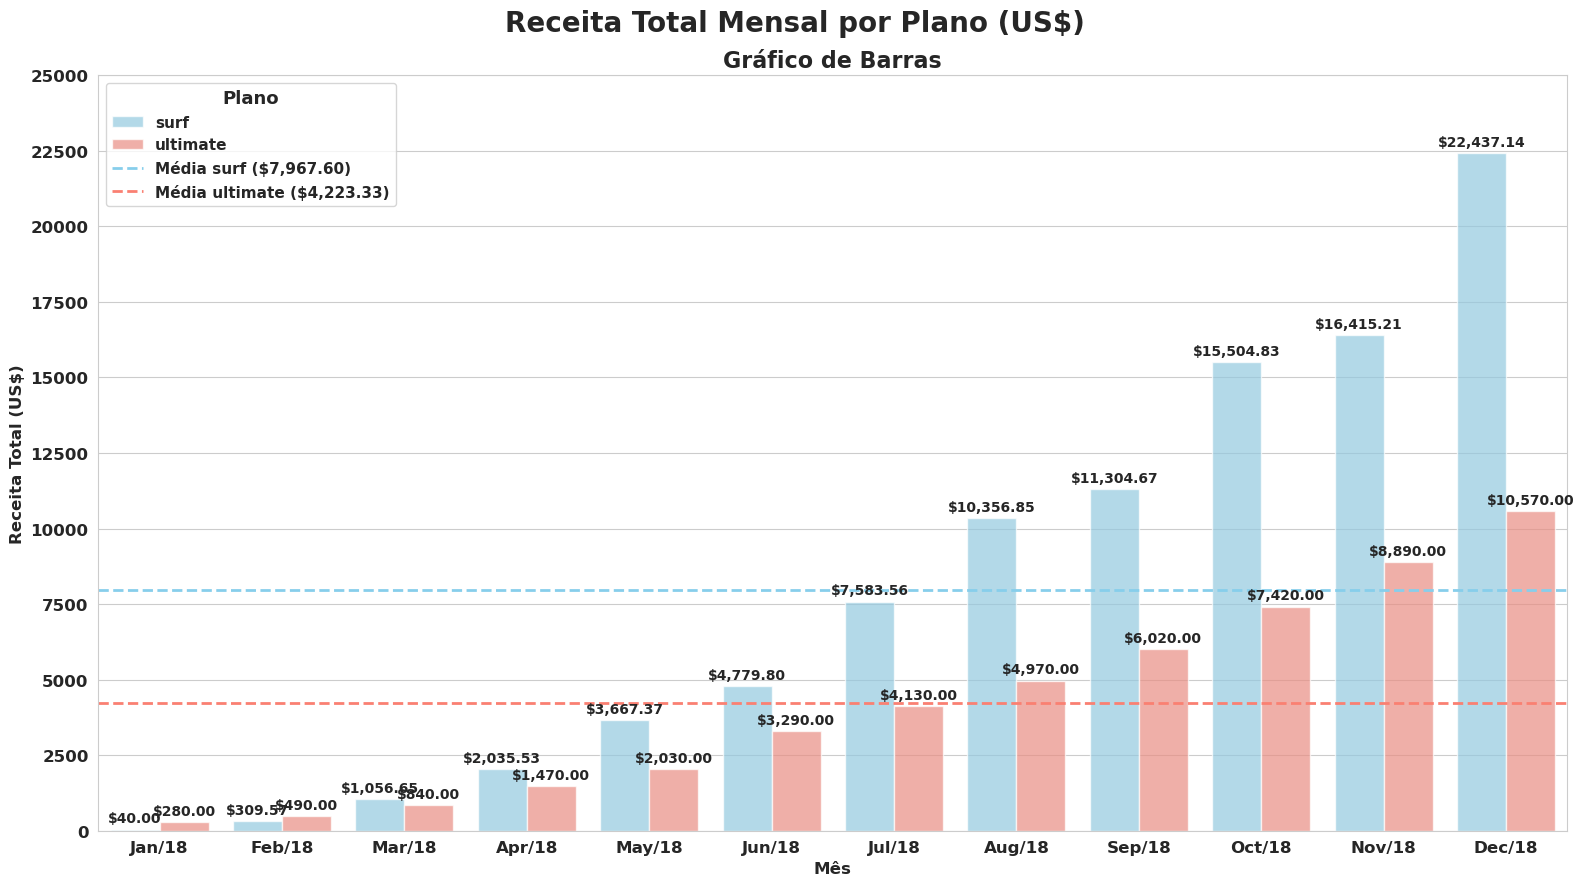

In [834]:
# Aqui queremos analisar a evolução da receita mensal para cada plano usando 3 gráfico de barras:
    # 1. Receita Total Mensal por Plano (US$)
    # 2. Receita Total Mensal por Plano (US$) X Número de Clientes 
    # 3. Receita Média Mensal por Usuário por Plano (US$)


# --- 1. Receita Total Mensal por Plano (US$) ---

print('↔️ Comparando a RECEITA TOTAL MENSAL por plano...')

print('='*70)
print('📊 GRÁFICO DE BARRAS 1: RECEITA TOTAL MENSAL POR PLANO')
print('='*70)


print("✅ 1. Gerando o gráfico de barras com Seaborn da RECEITA TOTAL MENSAL por plano...")


df_revenue['month_label'] = df_revenue['month'].dt.strftime('%b/%y').str.capitalize()

# --- Plotando o gráfico de barras com Seaborn ---

# Definindo a ordem
order_month = df_revenue['month'].sort_values().dt.strftime('%b/%y').str.capitalize().unique()


# 1. Definindo o tamanho da figura e título
plt.figure(figsize=(16, 9))
plt.suptitle('Receita Total Mensal por Plano (US$)', fontsize=20, weight='bold') # Definindo o título


# 2. Criando o gráfico de barras
ax_rev = sns.barplot(
    data=df_revenue,
    x='month_label',
    y='receita_total',
    hue='plan',
    order=order_month, 
    palette=plan_palette,
    alpha=0.7
)

# 3. Plotando as linhas de média para cada um dos planos

    # A. Calculando a média de receita mensal total para cada plano
overall_rev_tot_avg = df_agrupado.groupby('plan')['total_revenue'].sum()/12

    # B. Plotando as linhas horizontais
for plan_name, overall_rev_avg in overall_rev_tot_avg.items():
    ax_rev.axhline(
        y=overall_rev_avg, 
        color=plan_palette[plan_name], 
        linestyle='--', 
        linewidth=2, 
        label=f'Média {plan_name} (${overall_rev_avg:,.2f})'
    )

# 4. Adicionando os títulos e rótulos
ax_rev.set_title('Gráfico de Barras', fontsize=16, weight='bold')
ax_rev.set_xlabel('Mês',fontsize=12, weight='bold')
ax_rev.set_ylabel('Receita Total (US$)',fontsize=12, weight='bold')
ax_rev.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': 'bold', 'size': '11'}, loc='upper left')

plt.xticks(rotation=0, fontsize=12, weight='bold')
plt.yticks(range(0,25001,2500), fontsize=12, weight='bold')


# 5. Adicionando rótulos de dados nas barras
for container in ax_rev.containers:
    ax_rev.bar_label(container, fmt='${:,.2f}', label_type='edge', weight='bold', size=10, padding=3)
    
# 6. Exibindo o gráfico
plt.tight_layout() # Ajusta o layout para evitar que os labels se sobreponham
plt.show()

↔️ Comparando a receita total mensal por plano com o número de clientes mensais por plano...
📊 GRÁFICO DE BARRAS 2: RECEITA TOTAL MENSAL POR PLANO (US$) X Nº DE CLIENTES POR PLANO

------------------------------------------------------------------------------
# CRIANDO OS GRÁFICOS LADO A LADO COM SUBPLOTS
------------------------------------------------------------------------------
✅ 1. Plotando a Receita Média Mensal por Plano...
✅ 2. Plotando o Número de Clientes Mensais por Plano...


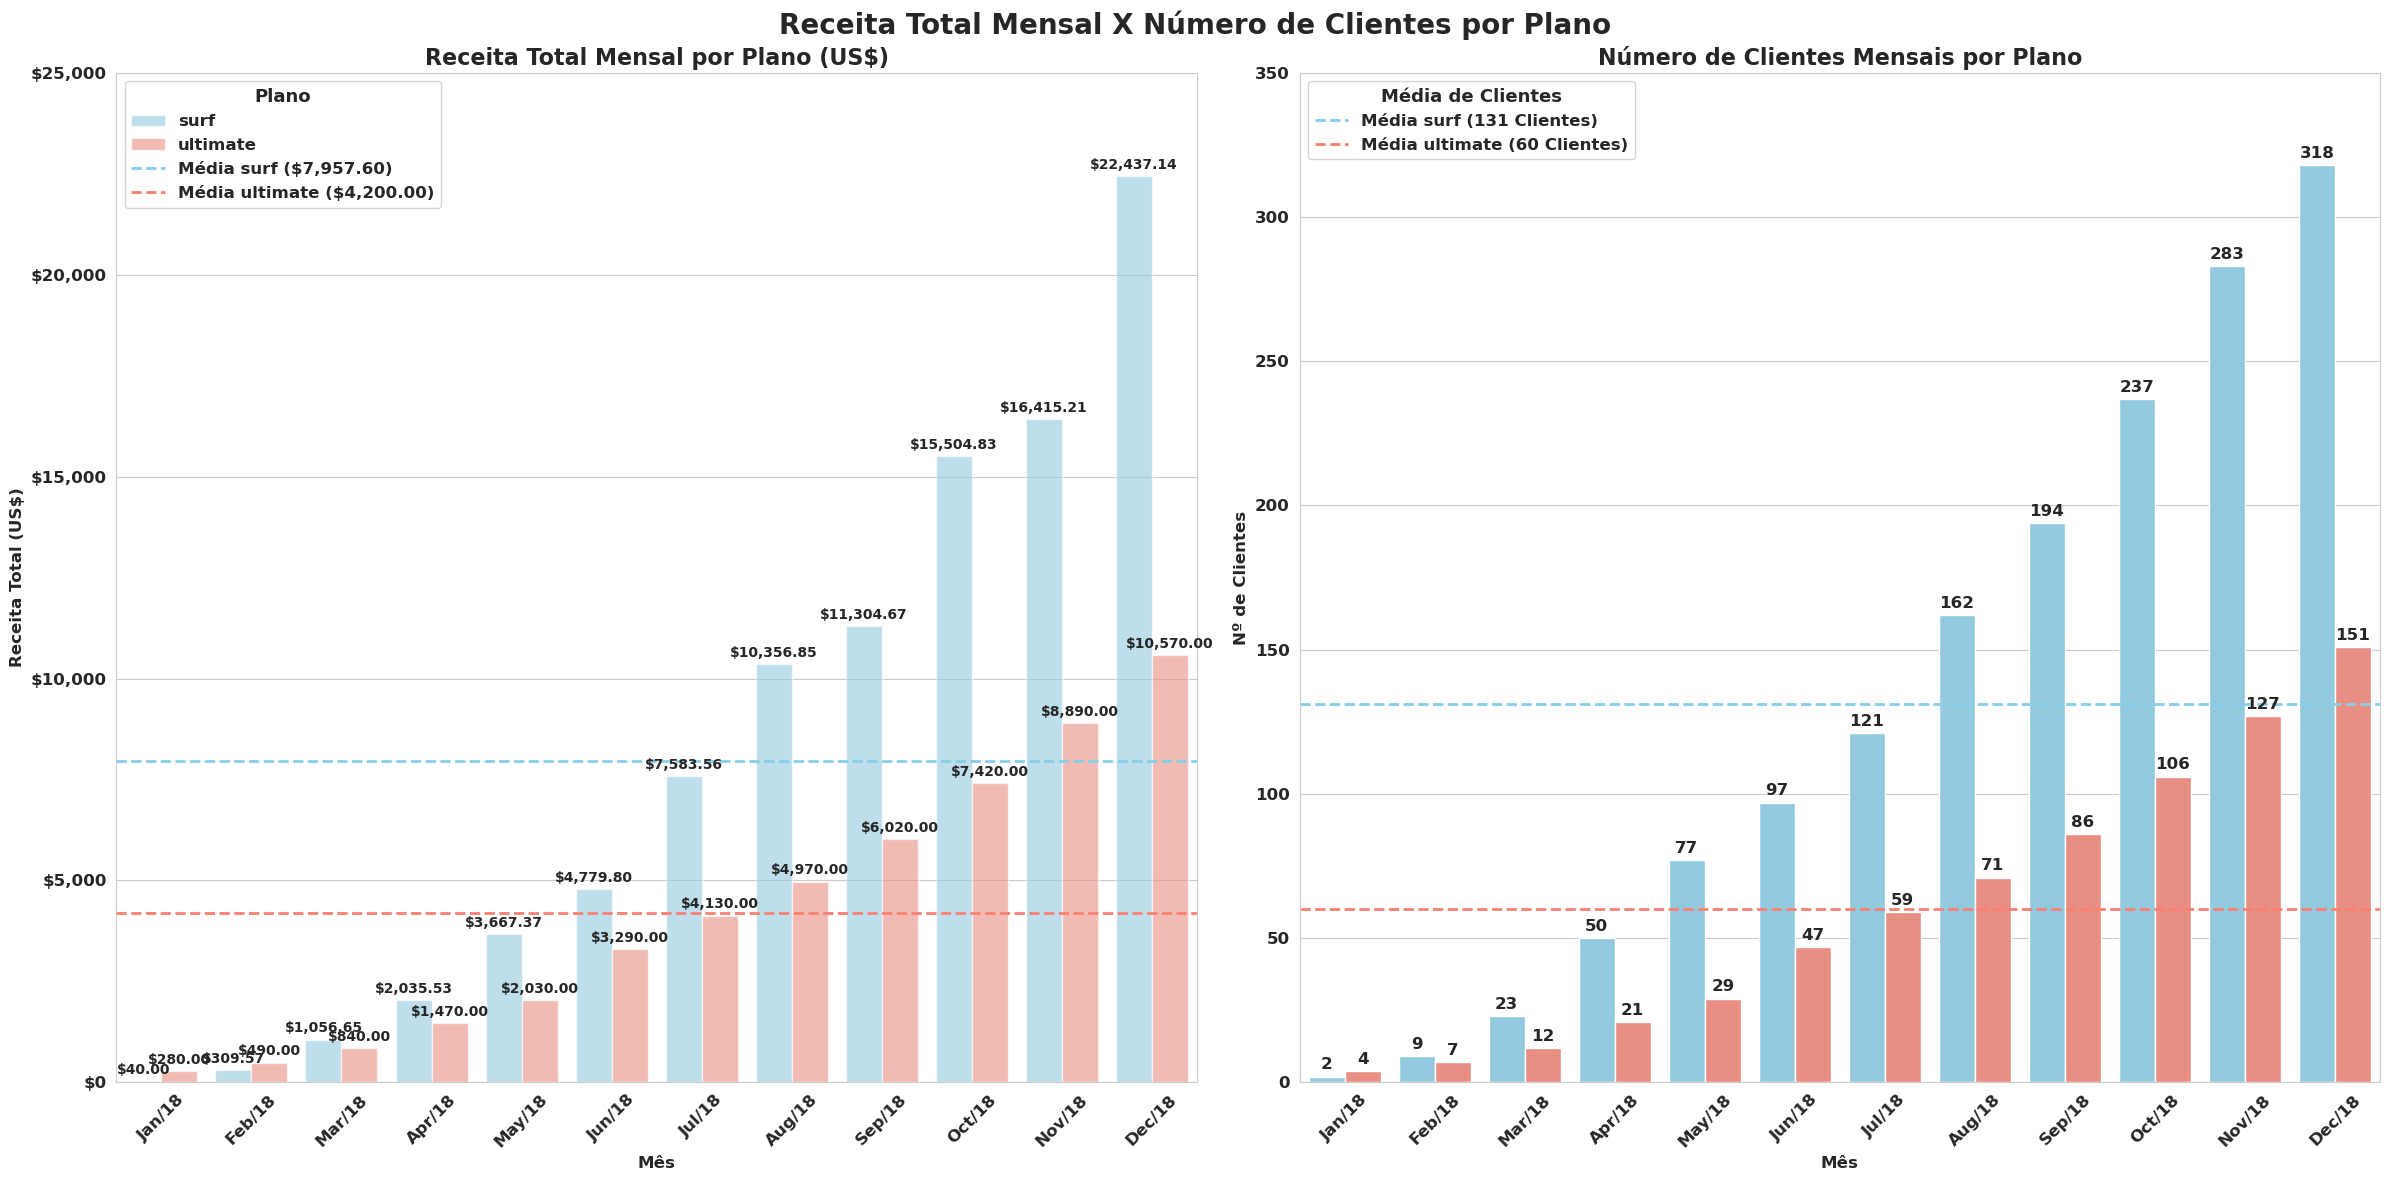

In [835]:
# Aqui iremos comparar a receita mensal total da empresa entre os planos

# --- 2. Receita Total Mensal por Plano (US$) X Número de Clientes ---

print('↔️ Comparando a receita total mensal por plano com o número de clientes mensais por plano...')

print('='*90)
print('📊 GRÁFICO DE BARRAS 2: RECEITA TOTAL MENSAL POR PLANO (US$) X Nº DE CLIENTES POR PLANO')
print('='*90)

# PASSO 1: Preparação dos Dados
# Adicionei 'clientes_ativos' à cópia do DataFrame para uso nos gráficos
df_rev_2 = calculo_receita[['receita_total', 'clientes_ativos', 'month', 'plan']].sort_values(by='month').copy()
df_rev_2['month_label'] = df_rev_2['month'].dt.strftime('%b/%y').str.capitalize()

# Definindo a ordem cronológica dos meses para ambos os gráficos
order_month = df_rev_2['month'].sort_values().dt.strftime('%b/%y').str.capitalize().unique()

    
print('''\n------------------------------------------------------------------------------
# CRIANDO OS GRÁFICOS LADO A LADO COM SUBPLOTS
------------------------------------------------------------------------------''')

# 1. Definindo o tamanho da figura com 2 colunas e título principal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))
plt.suptitle('Receita Total Mensal X Número de Clientes por Plano', fontsize=20, weight='bold') # Definindo o título


# ------------------------------------------------------------------------------
# GRÁFICO 1: RECEITA MÉDIA MENSAL POR PLANO
# ------------------------------------------------------------------------------

print("✅ 1. Plotando a Receita Média Mensal por Plano...")

# 2. Criando o gráfico de barras (Receita) no ax1
sns.barplot(
    data=df_rev_2,
    x='month_label',
    y='receita_total',
    hue='plan',
    order=order_month, 
    palette=plan_palette,
    alpha=0.6,
    ax=ax1 # Atribui ao primeiro eixo
)

# 3. Plotando as linhas de média para cada um dos planos

    # A. Calculando a média geral
overall_rev_avg_2 = df_rev_2.groupby('plan')['receita_total'].mean()

    # B. Plotando as linhas horizontais
for plan_name, avg_value in overall_rev_avg_2.items():
    ax1.axhline(
        y=avg_value, 
        color=plan_palette[plan_name], 
        linestyle='--', 
        linewidth=2, 
        label=f'Média {plan_name} (${avg_value:,.2f})'
    )

# 4. Adicionando os títulos e rótulos
ax1.set_title('Receita Total Mensal por Plano (US$)', fontsize=16, weight='bold')
ax1.set_xlabel('Mês',fontsize=12, weight='bold')
ax1.set_ylabel('Receita Total (US$)',fontsize=12, weight='bold')
ax1.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '13'}, prop={'weight': 'bold', 'size': '12'}, loc='upper left')
ax1.tick_params(axis='x', rotation=45, labelsize=12) # Rotação dos meses
ax1.tick_params(axis='y', labelsize=12)
plt.setp(ax1.get_xticklabels(), fontweight='bold') # Adicionando negrito ao eixo X
ax1.set_yticks(ax1.get_yticks()) # Mantém ticks existentes
ax1.set_yticklabels([f'${y:,.0f}' for y in ax1.get_yticks()], weight='bold') # Formata Y com $

# 5. Adicionando rótulos de dados nas barras
for container in ax1.containers:
    ax1.bar_label(container, fmt='${:,.2f}', label_type='edge', weight='bold', size=10, padding=3)


# ------------------------------------------------------------------------------
# GRÁFICO 2: NÚMERO DE CLIENTES MENSAIS POR PLANO
# ------------------------------------------------------------------------------

print("✅ 2. Plotando o Número de Clientes Mensais por Plano...")

# SOLUÇÃO: Usamos 'estimator=np.mean' (ou None) e 'errorbar='sd'
# assumindo que a coluna 'clientes_ativos' tem variação.
sns.barplot(
    data=df_rev_2,
    x='month_label',
    y='clientes_ativos',
    hue='plan',
    order=order_month, 
    palette=plan_palette,
    alpha=1,
    ax=ax2,
    legend=False
)

# 3. Plotando as linhas de média para o Número de Clientes

    # A. Calculando a média geral de clientes ativos para cada plano
overall_client_avg = df_rev_2.groupby('plan')['clientes_ativos'].mean()

    # B. Plotando as linhas horizontais
for plan_name, avg_value in overall_client_avg.items():
    ax2.axhline(
        y=avg_value, 
        color=plan_palette[plan_name], # Usa a paleta original para as linhas de média
        linestyle='--', 
        linewidth=2, 
        label=f'Média {plan_name} ({avg_value:,.0f} Clientes)' # Formata como número inteiro
    )

# Personalizando o gráfico
ax2.set_title('Número de Clientes Mensais por Plano', fontsize=16, weight='bold')
ax2.set_xlabel('Mês',fontsize=12, weight='bold')
ax2.set_ylabel('Nº de Clientes',fontsize=12, weight='bold')
ax2.legend(title='Média de Clientes', 
           title_fontproperties={'weight': 'bold', 'size': '13'}, 
           prop={'weight': 'bold', 'size': '12'}, 
           loc='upper left')

ax2.tick_params(axis='x', rotation=45, labelsize=12)
plt.setp(ax2.get_xticklabels(), fontweight='bold') # Adicionando negrito ao eixo X

ax2.tick_params(axis='y', labelsize=12)
ax2.set_yticks(ax2.get_yticks())
ax2.set_yticklabels([f'{y:,.0f}' for y in ax2.get_yticks()], fontweight='bold')


for container in ax2.containers:
    ax2.bar_label(container, fmt='%.0f', label_type='edge', weight='bold', size=12, padding=3)

# ------------------------------------------------------------------------------
# AJUSTES FINAIS
# ------------------------------------------------------------------------------
plt.tight_layout() 
plt.show()

↔️ Comparando a receita média mensal por usuário por plano...
📊 GRÁFICO DE BARRAS 3: RECEITA MÉDIA MENSAL POR USUÁRIO POR PLANO
✅ 3. Gerando o gráfico de barras com Seaborn da RECEITA MÉDIA MENSAL por plano...


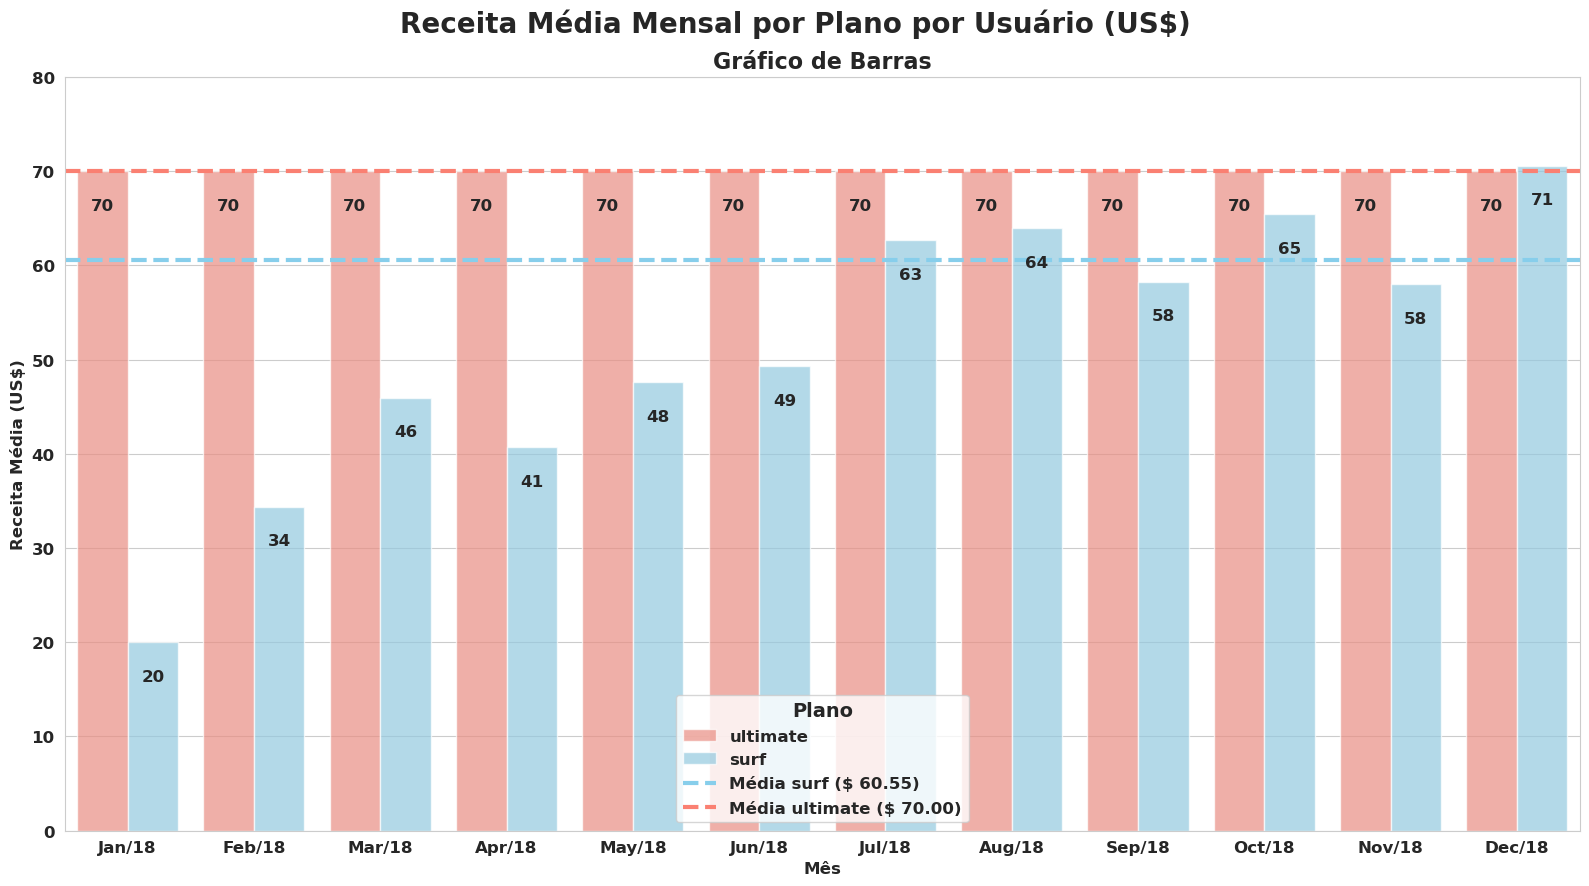

In [836]:
# Aqui iremos comparar a receita total mensal da empresa entre os planos

# --- 3. Receita Média Mensal por Usuário por Plano (US$) ---

print('↔️ Comparando a receita média mensal por usuário por plano...')
print('='*70)
print('📊 GRÁFICO DE BARRAS 3: RECEITA MÉDIA MENSAL POR USUÁRIO POR PLANO')
print('='*70)


print("✅ 3. Gerando o gráfico de barras com Seaborn da RECEITA MÉDIA MENSAL por plano...")

# Criando uma cópia com as colunas que queremos
df_rev = df_agrupado[['total_revenue','month','plan']].sort_values(by='month').copy()

# Criando uma coluna com a data corrigida em nosso df para visualização
df_rev['month_label'] = df_rev['month'].dt.strftime('%b/%y').str.capitalize()


# Plotando o gráfico de barras com Seaborn

# 1. Definindo o tamanho da figura e o título
plt.figure(figsize=(16, 9))
plt.suptitle('Receita Média Mensal por Plano por Usuário (US$)', fontsize=20, weight='bold') # Definindo o título

# 2. Criando o gráfico de barras
ax_rev_avg = sns.barplot(
    data=df_rev,
    x='month_label',
    y='total_revenue',
    hue='plan',
    palette=plan_palette,
    alpha=0.7,
    errorbar=None
)

# 3. Plotando as linhas de média para cada um dos planos

    # A. Calculando a média geral para cada plano
overall_rev_avg = df_rev.groupby('plan')['total_revenue'].mean()

    # B. Plotando as linhas horizontais
for plan_name, avg_value in overall_rev_avg.items():
    ax_rev_avg.axhline(y=avg_value, color=plan_palette[plan_name], linestyle='--', linewidth=3, label=f'Média {plan_name} ($ {avg_value:.2f})')

# 4. Adicionando os títulos e rótulos
ax_rev_avg.set_title('Gráfico de Barras', fontsize=16, weight='bold')
ax_rev_avg.set_xlabel('Mês',fontsize=12, weight='bold')
ax_rev_avg.set_ylabel('Receita Média (US$)',fontsize=12, weight='bold')
ax_rev_avg.legend(title='Plano', title_fontproperties={'weight': 'bold', 'size': '14'}, prop={'weight': 'bold', 'size': '12'}, loc='lower center')

# 5. Ajustando nossos eixos
plt.xticks(rotation=0, fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')

ax_rev_avg.set_ylim(0, 80) 


# 6. Adicionando rótulos de dados nas barras
for container in ax_rev_avg.containers:
    ax_rev_avg.bar_label(container, fmt='%.0f', label_type='edge', weight='bold', size=12, padding = -30)
    
# 7. Exibindo o gráfico
plt.tight_layout() # Ajusta o layout para evitar que os labels se sobreponham
plt.show()

In [837]:
# Agora iremos calcular a média e a variância da receita mensal dos planos para verificar se a média e a varîância da receita dos planos são idênticas ou não. 


# Selecionando os minutos para cada plano com nosso filtro 
filtro_rev_surf = df_rev['total_revenue'][df_rev['plan'] == 'surf']
filtro_rev_ultimate = df_rev['total_revenue'][df_rev['plan'] == 'ultimate']

print('='*70)

#---------------------------------------------------------
print('🔢 Imprimindo a média e a variância das receitas mensais...')
print('='*70)

print()

#surf
surf_rev__mean = filtro_rev_surf.mean()
surf_rev_var = filtro_rev_surf.var()

# ultimate
ultimate_rev_mean = filtro_rev_ultimate.mean()
ultimate_rev_var = filtro_rev_ultimate.var()


# Imprimindo a média e a variância para cada plano
print('-'*70)
print('🏄🏻‍♂️ Plano Surf:')
print('-'*70)
print(f'Média (μ):         {surf_rev__mean:.2f}')
print(f'Variância (σ²):    {surf_rev_var:.2f}')
print(f'Desvio Padrão (σ): {math.sqrt(surf_rev_var):.2f}')

print()

print('-'*70)
print('👑 Plano Ultimate:')
print('-'*70)
print(f'Média (μ):         {ultimate_rev_mean:.2f}')
print(f'Variância (σ²):    {ultimate_rev_var:.2f}')
print(f'Desvio Padrão (σ): {math.sqrt(ultimate_rev_var):.2f}')

🔢 Imprimindo a média e a variância das receitas mensais...

----------------------------------------------------------------------
🏄🏻‍♂️ Plano Surf:
----------------------------------------------------------------------
Média (μ):         60.55
Variância (σ²):    3062.45
Desvio Padrão (σ): 55.34

----------------------------------------------------------------------
👑 Plano Ultimate:
----------------------------------------------------------------------
Média (μ):         70.00
Variância (σ²):    0.00
Desvio Padrão (σ): 0.00


#### **Gráfico: HISTOGRAMA**

📶 Criando o Histograma da Distribuição da Receita Média Mensal por Usuário
   ✅ 1. Gerando o HISTOGRAMA para comparar a RECEITA MÉDIA MENSAL POR USUÁRIO...


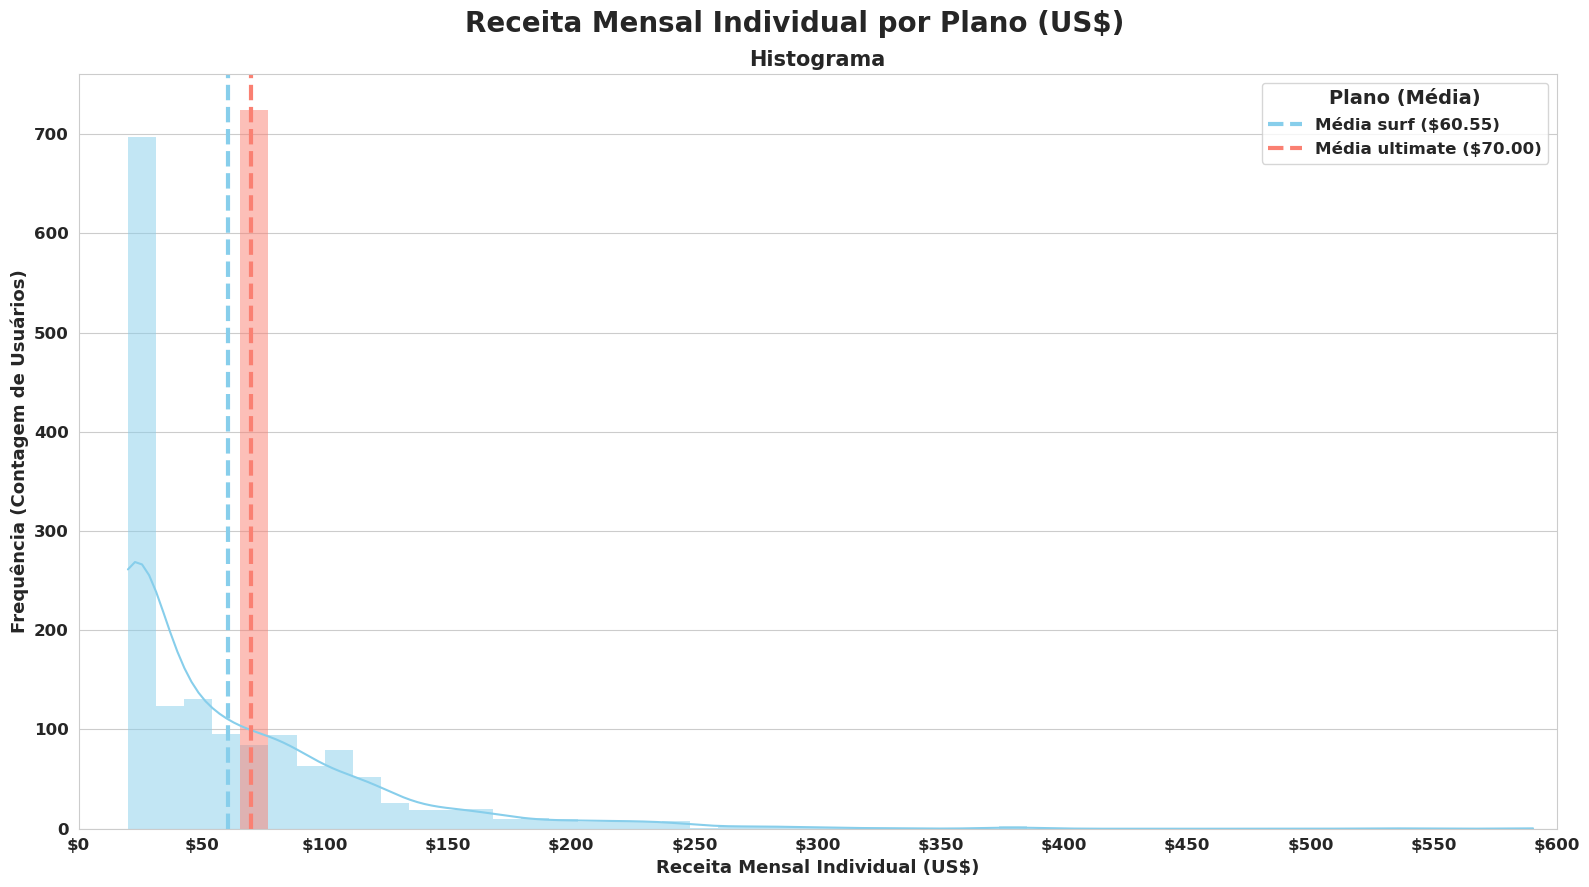

In [838]:
# Aqui iremos analisar se a distribuição da receita média mensal por usuário é semelhante ou não.
# Iremos construir um histograma e analisar as estatísticas da distruição de minutos por plano.

print('📶 Criando o Histograma da Distribuição da Receita Média Mensal por Usuário')
print('='*80)

#-------------------------------------------------------
print("   ✅ 1. Gerando o HISTOGRAMA para comparar a RECEITA MÉDIA MENSAL POR USUÁRIO...")
print('='*80)


# Calculando a média novamente
overall_avg_revenue = df_agrupado.groupby('plan')['total_revenue'].mean()

# 1. Configurando a figura e o eixo
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
fig.suptitle('Receita Mensal Individual por Plano (US$)', fontsize=20, weight='bold')

# 2. Criando o histograma VERTICAL
sns.histplot(
    data=df_agrupado,
    x='total_revenue', 
    hue='plan',
    bins=50, 
    kde=True, 
    palette=plan_palette,
    ax=ax, # Usa o eixo único
    alpha=0.5,
    linewidth=0
)

# 3. Adicionando as linhas de média VERTICAIS (axvline)
for plan_name, avg_value in overall_avg_revenue.items():
    ax.axvline( # axvline para linhas VERTICAIS
        x=avg_value, 
        color=plan_palette[plan_name], 
        linestyle='--', 
        linewidth=3, 
        label=f'Média {plan_name} (${avg_value:,.2f})'
    )


# Aplicando ESCALA X
ax.set_xlim(0, 600) # Limite X
ax.set_xticks(range(0,601,50))  # Ticks X

# Renomeando nossos eixos
ax.set_title('Histograma', fontsize=15, weight='bold')
ax.set_xlabel('Receita Mensal Individual (US$)', fontsize=13, weight='bold') # <--- Receita no Eixo X
ax.set_ylabel('Frequência (Contagem de Usuários)', fontsize=13, weight='bold') # <--- Frequência no Eixo Y

# Formatação do Eixo X com o símbolo '$'
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# 5. Legenda do Histograma
handles_bar, labels_bar = ax.get_legend_handles_labels()

ax.legend(title='Plano (Média)', 
          handles=handles_bar, 
          labels=labels_bar,
          title_fontproperties={'weight': 'bold', 'size': '14'},
          loc='upper right',
          prop={'size': 12, 'weight': 'bold'})

# Desativando as linhas verticais
ax.xaxis.grid(False) 

# 6. Aplicando bold e fontsize aos ticks
ax.tick_params(axis='both', labelsize=12)
plt.setp(ax.get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(ax.get_yticklabels(), fontsize=12, fontweight='bold')

# 7. Ajustes finais e exibição
plt.tight_layout()
plt.show()

In [839]:
# Análise Descritiva: Receita Mensal Individual por Plano
print('='*70)
print("   🔢 3. Análise Descritiva: Receita Mensal Individual por Plano")
print('='*70)

# Selecionando as mensagens para cada plano com nosso filtro 
filtro_rev_surf = df_agrupado['total_revenue'][df_agrupado['plan'] == 'surf']
filtro_rev_ultimate = df_agrupado['total_revenue'][df_agrupado['plan'] == 'ultimate']

print()

# Imprimindo os resumos estatísticos das distriuições
print('-'*70)
print('🏄🏻‍♂️ Plano Surf: Distribuição dos Dados:')
print('-'*70)
print(filtro_rev_surf.describe())

print()

print('-'*70)
print('👑 Plano Ultimate: Distribuição dos Dados:')
print('-'*70)
print(filtro_rev_ultimate.describe())

   🔢 3. Análise Descritiva: Receita Mensal Individual por Plano

----------------------------------------------------------------------
🏄🏻‍♂️ Plano Surf: Distribuição dos Dados:
----------------------------------------------------------------------
count    1579.000000
mean       60.551729
std        55.339379
min        20.000000
25%        20.000000
50%        40.180000
75%        80.315000
max       590.370000
Name: total_revenue, dtype: float64

----------------------------------------------------------------------
👑 Plano Ultimate: Distribuição dos Dados:
----------------------------------------------------------------------
count    724.0
mean      70.0
std        0.0
min       70.0
25%       70.0
50%       70.0
75%       70.0
max       70.0
Name: total_revenue, dtype: float64


#### **Gráfico: BOXPLOT**

📦 Criando o Boxplot da Distribuição da Receita Média Individual entre os Planos
   ✅ 1. Gerando o BOXPLOT para comparar a DISTRIBUIÇÃO DA RECEITA MÉDIA INDIVIDUAL por plano...


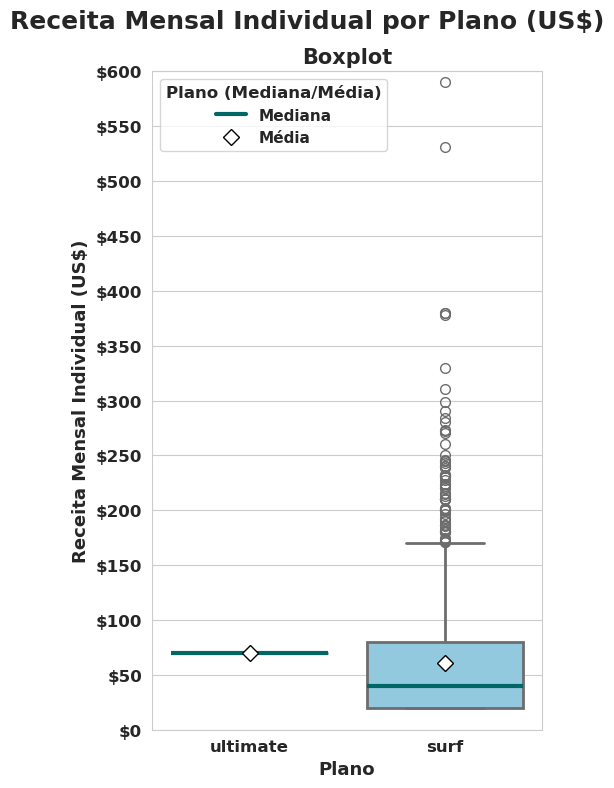

In [840]:
# Aqui faremos um BOXPLOT para comparar a distribuição das receitas médias mensais individuais dos usuários entre os dois planos

print('📦 Criando o Boxplot da Distribuição da Receita Média Individual entre os Planos')
print('='*95)

#-------------------------------------------------------
print("   ✅ 1. Gerando o BOXPLOT para comparar a DISTRIBUIÇÃO DA RECEITA MÉDIA INDIVIDUAL por plano...")
print('='*95)

plt.figure(figsize=(5, 8))
ax_box_rev = plt.gca() 
plt.suptitle('Receita Mensal Individual por Plano (US$)', fontsize=18, weight='bold')

# ==============================================================================
# BOXPLOT VERTICAL (Receita no Eixo Y)
# ==============================================================================
sns.boxplot(
    data=df_agrupado,
    x='plan',
    y='total_revenue', 
    hue='plan',
    palette=plan_palette,
    ax=ax_box_rev,
    linewidth=2,
    fliersize=7, 
    medianprops={'color': '#006666', 'linewidth': 3}, 
    showmeans=True, 
    meanprops={'marker':'D', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':'8'}
)

# Aplicando ESCALA Y COMUM (Receita)
ax_box_rev.set_ylim(0, 600) 
ax_box_rev.set_yticks(range(0,601,50))

# Formatação do Boxplot
ax_box_rev.set_title('Boxplot', fontsize=15, weight='bold')
ax_box_rev.set_xlabel('Plano', fontsize=13, weight='bold')
ax_box_rev.set_ylabel('Receita Mensal Individual (US$)', fontsize=13, weight='bold')

# Formatação do Eixo Y com o símbolo '$'
ax_box_rev.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Adicionando legenda manual para Mediana/Média
legend_handles_box = [
    plt.Line2D([0], [0], color='#006666', linewidth=3, linestyle='-'), 
    plt.Line2D([0], [0], marker='D', markerfacecolor='white', markeredgecolor='black', linestyle='None', markersize=8)
]
legend_labels_box = [
    f'Mediana', 
    f'Média'
]

ax_box_rev.legend(handles=legend_handles_box, 
          labels=legend_labels_box,
          title='Plano (Mediana/Média)',
          loc='upper left',
          title_fontproperties={'weight': 'bold', 'size': '12'},
          prop={'size': 11, 'weight': 'bold'})

# Aplicando bold e fontsize aos ticks
ax_box_rev.tick_params(axis='both', labelsize=12)
plt.setp(ax_box_rev.get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(ax_box_rev.get_yticklabels(), fontsize=12, fontweight='bold')

# Ajustes finais e exibição
plt.tight_layout()
plt.show()

#### **Gráfico: HISTOGRAMA & BOXPLOT LADO A LADO**

📊 Criando o Histograma e o Boxplot Lado a Lado da Distribuição da Receita Média Individual entre os Planos
   ✅ 1. Gerando Histograma e Boxplot para análise de DISTRIBUIÇÃO DA RECEITA MÉDIA POR USUÁRIO...

------------------------------------------------------------------------------
# 1. CRIANDO OS GRÁFICOS DE HISTOGRAMA E BOXPLOT LADO A LADO
------------------------------------------------------------------------------


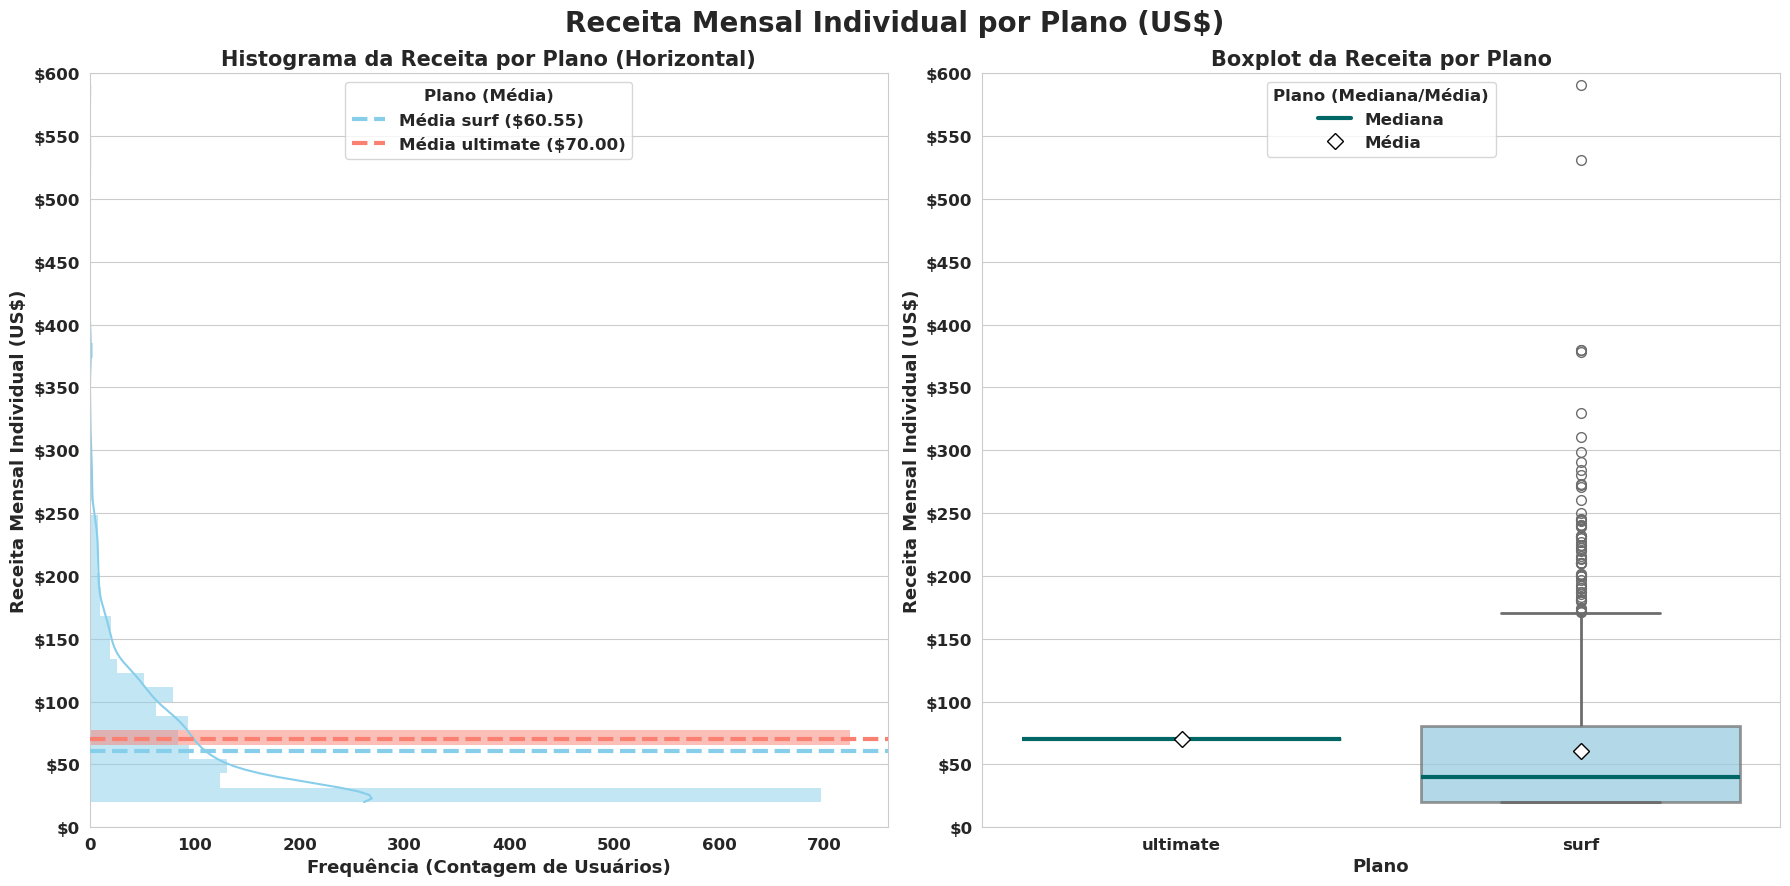

In [ ]:
# Aqui faremos um BOXPLOT para comparar a distribuição das receitas médias mensais individuais dos usuários entre os dois planos

print('📊 Criando o Histograma e o Boxplot Lado a Lado da Distribuição da Receita Média Individual entre os Planos')
print('='*95)

#-------------------------------------------------------
print("   ✅ 1. Gerando Histograma e Boxplot para análise de DISTRIBUIÇÃO DA RECEITA MÉDIA POR USUÁRIO...")
print('='*95)

    
print('''\n------------------------------------------------------------------------------
# 1. CRIANDO OS GRÁFICOS DE HISTOGRAMA E BOXPLOT LADO A LADO
------------------------------------------------------------------------------''')

# Calculando a média novamente
overall_avg_revenue = df_agrupado.groupby('plan')['total_revenue'].mean()

# Definindo a escala comum do eixo Y (Receita)
max_revenue = 600 
tick_step = 50 
tick_values = np.arange(0, max_revenue + tick_step, tick_step)


# Configurando a figura e os subplots (1 linha, 2 colunas)
fig2, axes = plt.subplots(1, 2, figsize=(18, 9))
fig2.suptitle('Receita Mensal Individual por Plano (US$)', fontsize=20, weight='bold')

# ==============================================================================
# EIXO 0 (axes[0]): HISTOGRAMA HORIZONTAL (Receita no Eixo Y)
# ==============================================================================
sns.histplot(
    data=df_agrupado,
    # MUDANÇA CRUCIAL: Trocando 'x' por 'y'
    y='total_revenue', 
    hue='plan',
    bins=50, 
    kde=True, 
    palette=plan_palette,
    ax=axes[0],
    alpha=0.8,
    zorder=1, # garantido que histograma fique abaixo
    linewidth=0
)

# Adicionando as linhas de média HORIZONTAIS (axhline)
for plan_name, avg_value in overall_avg_revenue.items():
    axes[0].axhline( # axhline para linhas horizontais
        y=avg_value, 
        color=plan_palette[plan_name], 
        linestyle='--', 
        linewidth=3,
        zorder=5, #aumentando para garantir que a linha fique por cima 
        label=f'Média {plan_name} (${avg_value:,.2f})'
    )

# Aplicando ESCALA Y COMUM (Receita)
axes[0].set_ylim(0, max_revenue) # Limite Y
axes[0].set_yticks(tick_values)  # Ticks Y

# O Eixo X agora é Frequência
axes[0].set_title('Histograma da Receita por Plano (Horizontal)', fontsize=15, weight='bold')
axes[0].set_xlabel('Frequência (Contagem de Usuários)', fontsize=13, weight='bold') 
axes[0].set_ylabel('Receita Mensal Individual (US$)', fontsize=13, weight='bold')
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Desativando as linhas verticais
axes[0].xaxis.grid(False) 

# Legenda do Histograma (Mantida a mesma lógica)
handles_bar, labels_bar = axes[0].get_legend_handles_labels()

axes[0].legend(title='Plano (Média)', 
                handles=handles_bar, 
                labels=labels_bar,
                title_fontproperties={'weight': 'bold', 'size': '12'},
                loc='upper center',
                prop={'size': 12, 'weight': 'bold'})

# Aplicando bold e fontsize aos ticks
axes[0].tick_params(axis='both', labelsize=12)
plt.setp(axes[0].get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(axes[0].get_yticklabels(), fontsize=12, fontweight='bold')


# ==============================================================================
# EIXO 1 (axes[1]): BOXPLOT VERTICAL (Receita no Eixo Y)
# ==============================================================================
sns.boxplot(
    data=df_agrupado,
    x='plan',
    y='total_revenue', # Receita no Eixo Y
    palette=plan_palette,
    hue='plan',
    boxprops={'alpha':0.8},
    ax=axes[1],
    linewidth=2,
    fliersize=7, 
    medianprops={'color': '#006666', 'linewidth': 3}, 
    showmeans=True, 
    meanprops={'marker':'D', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':'8'}
)

# Aplicando ESCALA Y COMUM (Receita)
axes[1].set_ylim(0, max_revenue) 
axes[1].set_yticks(tick_values)

# Formatação do Boxplot
axes[1].set_title('Boxplot da Receita por Plano', fontsize=15, weight='bold')
axes[1].set_xlabel('Plano', fontsize=13, weight='bold')
axes[1].set_ylabel('Receita Mensal Individual (US$)', fontsize=13, weight='bold')
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Adicionando legenda manual para Mediana/Média
legend_handles_box = [
    plt.Line2D([0], [0], color='#006666', linewidth=3, linestyle='-'), 
    plt.Line2D([0], [0], marker='D', markerfacecolor='white', markeredgecolor='black', linestyle='None', markersize=8)
]
legend_labels_box = [
    f'Mediana', 
    f'Média'
]

axes[1].legend(handles=legend_handles_box, 
                labels=legend_labels_box,
                title='Plano (Mediana/Média)',
                loc='upper center',
                title_fontproperties={'weight': 'bold', 'size': '12'},
                prop={'size': 12, 'weight': 'bold'})

# Aplicando bold e fontsize aos ticks
axes[1].tick_params(axis='both', labelsize=12)
plt.setp(axes[1].get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(axes[1].get_yticklabels(), fontsize=12, fontweight='bold')

# Ajustes finais e exibição
plt.tight_layout()
plt.show()

#### 💡 **Conclusão: Análise de Comportamento de Receita por Plano**

A análise de receita é a mais reveladora de todas. 

O plano Ultimate possui a receita média por usuário (ARPU) mais alta ($70.00 vs $60.55), mas a principal e mais drástica diferença está na variabilidade: a receita do Ultimate é totalmente fixa (variância zero), enquanto a do Surf é extremamente volátil.

1. Comportamento Médio de Receita (ARPU):

- Conforme os dados estatísticos, a receita média mensal do plano Ultimate é de $70.00, superando a média do plano Surf, que é de $60.55.

- Isso significa que:   
  - Na média, o plano "premium" é, de fato, mais lucrativo para a empresa.  
  - A média do Surf ($60.55) é 3x maior que sua taxa base ($20), confirmando que a receita deste plano é altamente dependente de taxas de excedentes.

1. Relação com os Limites dos Planos e Implicações na Receita:

- A principal diferença de comportamento aparece quando observamos a distribuição do consumo nos histogramas e boxplots, confirmada pelos dados descritivos:

- 🏄🏻‍♂️ Usuários Surf:     
  - ⚠️ A distribuição de receita é extremamente volátil, com Desvio Padrão (σ) de $55.34.     
  - O boxplot e os dados descritivos mostram isso:       
  - O 25% inferior dos usuários paga exatamente a taxa base ($20.00).       
  - A mediana (50%) é de $40.18.
  - O 75% superior paga $80.31 ou mais.
  - Isso significa que pelo menos 50% dos clientes Surf pagam mais que o dobro da taxa base, gerando receita adicional alta, porém imprevisível para a empresa.     
  - A presença de outliers extremos (máx. $590.37) reforça essa volatilidade.

- 👑 Usuários Ultimate:
  - ⬇️ Ao contrário, a distribuição de receita do Ultimate é perfeitamente estável.
  - Os dados descritivos são absolutos: Variância (σ²) de 0.00. O mínimo, 25%, mediana (50%), 75% e máximo são todos $70.00.
  - Isso significa que 100% dos clientes pagam exatamente o valor fixo do plano e nunca excedem seus limites. 
  - A receita de excedentes é inexistente.     
  - Para esses usuários, o plano funciona como um "seguro" de custo fixo, e a receita para a Megaline é garantida.<br><br>


💡 **Conclusão Final:**

A diferença no comportamento dos planos é a fonte da receita:   
- 🏄🏻‍♂️ Os clientes do plano Surf geram uma receita volátil. Muitos pagam apenas $20, mas uma grande parcela paga significativamente mais, criando uma receita média alta, mas arriscada e dependente do estouro de dados.   
- 👑 Já os clientes Ultimate pagam um valor fixo maior para terem conveniência, o que gera uma receita mensal estável, previsível e, na média, superior para a Megaline.

---

## 🧪 **Teste hipóteses estatísticas**

A análise exploratória (EDA) sugeriu que a receita do plano 'Ultimate' é maior que a do 'Surf' e que a receita da região 'NY-NJ' também é diferente (maior) que a das 'Outras'.

Agora, vamos usar testes T estatísticos para determinar se essas diferenças observadas são **estatisticamente significantes** ou se ocorreram por mero acaso.

In [778]:
# Nesta seção iremos realizar dois testes de hipóteses:
    # 1. A receita média entre os planos Ultimate e Surf são diferentes
    # 2. A receita média entre os planos Ultimate e Surf são diferentes entre os usuários de NY/NJ e outras regiões


# Para que nosso teste seja VÁLIDO, precisaremos garantir que nossos dados cumpram os 
# REQUISITOS DO TESTE T para comparação de DUAS populações (nossos dois planos):
    # - Aleatoriedade e Representatividade da Amostra: Os dados devem vir de uma amostra aleatória e representativa da população.
    # - Independência das Observações: As observações na amostra e entre as amostras para devem ser independentes.
    # - Normalidade: Para muitos testes paramétricos (como o Teste T), a distribuição da população (ou das médias amostrais, dependendo do tamanho da amostra) deve ser aproximadamente Normal.
    # - Homoscedasticidade (Homogeneidade de Variâncias): A suposição de que as variâncias populacionais são iguais. 
        # Caso esta premissa não seja atendida, como em nosso caso, devemos usar a correção de  Welch (usando `equal_var=False` na função ttest_ind do SciPy)  


# Portanto, precisaremos realizar os seguintes ajustes na preparação de nossos dados:

    # A. Garantir que a observação contenha apenas a sigla do estado que queremos observar
    #   Verifiquei que nosso 'df_users' não possuí a coluna de Estado ['state'] separada da Cidade ['city'].
    #   Por isso, precisaremos extrair o estado da coluna CIDADE ['city'] para uma nova coluna que contenha APENAS A SIGLA DO ESTADO ['state']:

        # Exemplo:          df_users['city']               ->  df_users['state']
            # 0    Atlanta-Sandy Springs-Roswell, GA MSA   ->       GA
            # 1          Seattle-Tacoma-Bellevue, WA MSA   ->       WA
            # 2     Las Vegas-Henderson-Paradise, NV MSA   ->       NV
            # 3                            Tulsa, OK MSA   ->       OK
            # 4          Seattle-Tacoma-Bellevue, WA MSA   ->       WA


    # B. Agrupar os dados por USUÁRIO: 
    #       Para garantir que cada observação seja independente entre si, 
    #       devemos agrupar nossos dados por USUÁRIO (não por MÊS, como fizemos anteriormente,
    #       pois pedidos de um mesmo usuário entre os meses são relacionados (dependentes).

### **Teste de Hipótese 1: Receita média (Ultimate X Surf)**

* **Hipótese Nula (H0):** A receita média dos usuários do plano 'Ultimate' é **igual** à receita média dos usuários do plano 'Surf'.
* **Hipótese Alternativa (H1):** A receita média dos usuários do plano 'Ultimate' é **diferente** da receita média dos usuários do plano 'Surf'. 

In [779]:
# ==================================================================================================
# TESTE 1: A RECEITA MÉDIA ENTRE OS PLANOS ULTIMATE E SURF SÃO DIFERENTES
# ==================================================================================================

print('='*80)
print('TESTE 1: A RECEITA MÉDIA ENTRE OS PLANOS ULTIMATE E SURF SÃO DIFERENTES')
print('='*80)
print()

# Aqui, nosso OBJETIVO é:
    # Entender se algum dos planos é mais estratégico para a Magaline
        # (a média da receita gerada é diferente entre os planos e um plano gera mais receita que o outro),
    # Ou se os dois planos são igualmente importantes para a emoresa 
        # (a média da receita gerada é identica entre os planos)

# Para isso, utilizaremos o seguinte TESTE DE HIPÓTESES:
    # H0: Hipótese nula: a receita entre os planos são iguais (média)
    # H1: Hipótese alternativa: a receita entre os planos não são iguais

# TESTE T:
    # Realizaremos o TESTE T, que testa diferenças entre DUAS MÉDIAS (média dos planos Surf e Ultimate)
    # Prepararemos nossos dados de acordo com as premissas desse teste apresentadas anteriormente.

    # Para realizarmos o Teste T em Python para duas variáveis indepdenentes, como no nosso caso,
    # utilizamos a função `scipy.stats.ttest_ind`
    # Assumiremos que as variâncias entre os grupos são diferentes.
    # Para isso, utilizarmos a correção de Welch com o argumento `(equal_var=False)` na função `ttest_ind`.

    # Definiremos nosso NÍVEL DE SIGNIFICÂNCIA (alpha) em 5% (α = 0,05).
    # Isso significa que se:
        # p-valor < α (ou 0,05) ->  se a probabilidade ('p_valor') for menor que nosso nível de significância (α), 
        #                           iremos REJEITAR A HIPÓTESE NULA H0, ou seja, há diferença signifcativa entre as médias.
        # p-valor >= α (ou 0,05) -> se o nível de significância for maior ou igual a 5% , quer dizer que é provavél que as médias sejam idênticas,
        #                           pois pertencem com alta probabilidade a um mesmo intervalo. 
        #                           Nesse caso, NÃO TEMOS EVIDÊNCIA ESTATÍSTICA SUFICIENTE PARA REJEITAR A HIPÓTESE NULA H0,
        #                           e concluímos que a diferença observada nas amostras é devida apenas ao acaso ou erro amostral,
        #                           e não a uma diferença real na população.


# --------------------------------------------------------------------------------------------------
# 0. Preparando nossos dados
# ---------------------------------------------------------------------------------------------------
print('-'*80)
print('👉 PREPARANDO NOSSOS DADOS:')
print('-'*80)

# ---------------------------------------------------------------------------------------------------
# A. Extrair a coluna de ESTADO ['state'] da coluna ['city']:
# ---------------------------------------------------------------------------------------------------

# --- 1. Extraindo a coluna ['state'] da coluna ['city'] em 'df_users' ---
print('\n🌍 EXTRAINDO A SIGLA DOS ESTADOS da coluna ["city"] e criando nossa nova coluna ["state"] em "df_users"...')

# Criando a nova coluna ['state'] através da extração dos nomes dos estados
    # A regex procura por uma sequência de abreviaturas de estado (
    # que consiste em duas letras maiúsculas, seguidas opcionalmente por múltiplos pares de hífen e duas letras maiúsculas)
    # imediatamente antes da sigla "MSA" no final do nome da cidade, capturando toda a sequência de 1, 2, 3 ou mais estados (ex: GA (1), NY-NJ (2), NY-NJ-PA (3), DC-VA-MD-WV (4))
df_users['state'] = (
    df_users['city']
    .str.extract(r'([A-Z]{2}(?:-[A-Z]{2})*)\sMSA') # Captura 1, 2, 3 ou mais estados
    .fillna('Outro')                               # Substitui valores nulos (que não se encaixam no padrão MSA)
)

print('\n> Resultado:\n')
print(df_users[['user_id','state','city']].head(20))
print('\n     ✅ SUCESSO! Coluna ["state"] criada corretamente em "df_users".\n')

print('-'*80)


# --- 2. Fazendo a união da nova coluna ['state'] em nosso 'df_users' para o 'df_agrupado' ---
print('🔄 UNINDO COM MERGE as informações de Estado (State) para "df_agrupado"...')

df_agrupado = pd.merge(
    df_agrupado,
    df_users[['user_id', 'state']],
    on='user_id', 
    how='left'
)
print('\n   Visualizando nosso "df_agrupado" atualizado com a coluna ["state"]...')

print(df_agrupado[['user_id','state','plan']].head())
print('\n     ✅ SUCESSO! A coluna ["state"] agora está em nosso "df_agrupado"\n')

print('-'*80)


# ---------------------------------------------------------------------------------------------------
# B. Agrupar os dados por USUÁRIO: 
# ---------------------------------------------------------------------------------------------------
print('👥 Agrupando por usuário para garantir a independência entre as observações...\n')

# Para o Teste T, uma premissa básica é a INDEPENDÊNCIA entre as observações.
# Em nosso DF Agrupado, a granularidade é ['user_id'] e ['month']. 
# A consequência disso é que o mesmo usuário possuirá mais de um registro, registros esses que são dependentes entre si.

# Então, iremos preparar nossos dados para o Teste T, fazendo um novo agrupamento:

# Pegaremos nosso DF agrupado e agruparemos novamente por ID do Usuário, para calcular a média da receita POR USUÁRIO
# e garantir que cada usuário seja apenas uma única observação

# Para isso, calculamos por USUÁRIO a MÉDIA de todas as métricas de consumo e RECEITA ao longo de todo o período de observação


print('🔢 Calculando as métricas de consumo e receita por usuário...\n')
# Colunas para cálculo de média (Métricas de consumo e receita)
agg_cols = [
    'total_minutes_rounded', 
    'message_count',
    'gb_used_monthly', 
    'total_revenue'
]

# Agrupando por 'user_id' e calculando as médias para cada uma das métricas acima
    # O resultado será um novo DataFrame 'df_user_avg'   
    # Extrairemos seu respectivo plano ('plan') e estado ('state') pegando a primeira ocorrência com 'first' 
df_user_avg = (
    df_agrupado.groupby('user_id')
    .agg(
        # Calcula a Média das métricas de consumo e receita com list comprehension:
            # Para cada coluna dentro de 'agg_cols', crie uma nova coluna em 'df_user_avg' chamada 'avg_(nome da coluna)'
        **{f'avg_{col}': (col, 'mean') for col in agg_cols},
        
        # Pega o primeiro valor de plan e state (eles não mudam para o mesmo user_id)
        plan=('plan', 'first'),
        state=('state', 'first')
    )
    .reset_index()
)

# Imprimindo o resultado
print(df_user_avg.head())
print('\n     ✅ SUCESSO! Agora cada linha representa um usuário distinto, seu respectivo estado e suas métricas de consumo e receita.\n')


# --------------------------------------------------------------------------------------------------

print('='*80)
print('🏆 Imprimindo os TOP 10 usuários mais geradores de receita...')
print('='*80)

top_20_users = df_user_avg[['user_id','avg_total_revenue','state','plan']].sort_values(by='avg_total_revenue',ascending=False)

display(top_20_users.head(20).style
        .bar(subset=['avg_total_revenue'], color="#4CAF50", align='mid')
        .format({'avg_total_revenue': '$ {:,.2f}'})
        .set_caption(f"💰 TOP 10 USUÁRIOS MAIS GERADORES DE RECEITA")
        .set_table_styles(table_styles)
        .set_properties(subset='avg_total_revenue', **{'font-weight': 'bold', 'text-align': 'right'})
        .hide())

TESTE 1: A RECEITA MÉDIA ENTRE OS PLANOS ULTIMATE E SURF SÃO DIFERENTES

--------------------------------------------------------------------------------
👉 PREPARANDO NOSSOS DADOS:
--------------------------------------------------------------------------------

🌍 EXTRAINDO A SIGLA DOS ESTADOS da coluna ["city"] e criando nossa nova coluna ["state"] em "df_users"...

> Resultado:

    user_id        state                                              city
0      1000           GA             Atlanta-Sandy Springs-Roswell, GA MSA
1      1001           WA                   Seattle-Tacoma-Bellevue, WA MSA
2      1002           NV              Las Vegas-Henderson-Paradise, NV MSA
3      1003           OK                                     Tulsa, OK MSA
4      1004           WA                   Seattle-Tacoma-Bellevue, WA MSA
5      1005           TX               Dallas-Fort Worth-Arlington, TX MSA
6      1006           CA            San Francisco-Oakland-Berkeley, CA MSA
7      1007     

user_id,avg_total_revenue,state,plan
1379,$ 320.19,MI,surf
1121,$ 275.70,FL,surf
1292,$ 263.33,TX,surf
1240,$ 236.35,LA,surf
1147,$ 199.35,HI,surf
1418,$ 188.00,NY-NJ-PA,surf
1268,$ 183.09,CA,surf
1194,$ 182.49,CA,surf
1215,$ 178.04,NY-NJ-PA,surf
1447,$ 177.98,FL,surf


In [780]:
# ==================================================================================================
# TESTE DE HIPÓTESE 1: A RECEITA MÉDIA ENTRE OS PLANOS ULTIMATE E SURF SÃO DIFERENTES
# ==================================================================================================

print('='*80)
print('👉 INÍCIO DO TESTE DE HIPÓTESES')
print('='*80)

# ------------------------------------------------------------------------------
# 0. Configurações do Teste
# ------------------------------------------------------------------------------
alpha = 0.05 # Nível de significância (5%)


print("--- Teste de Hipóteses: Receita Média por Plano ---")
print('''
    - H₀: Hipótese nula: a receita média entre os planos Surf e Ultimate são IGUAIS.
          (H₀: μ_Surf = μ_Ultimate)
          
    - H₁: Hipótese alternativa: a receita média entre os planos Surf e Ultimate são DIFERENTES.
          (H₁: μ_Surf ≠ μ_Ultimate)
          
    - Teste Estatístico Escolhido: Teste T de Welch (equal_var=False)
    - Tipo de Teste: Bicaudal (alinhado com H₁: 'diferente de')\n''')

print(f"Nível de Significância (α): {alpha}\n")

# ------------------------------------------------------------------------------
# 1. Separação dos Dados
# ------------------------------------------------------------------------------

# Extrai a receita total 'total_revenue' de cada plano
revenue_surf = df_user_avg[df_user_avg['plan'] == 'surf']['avg_total_revenue']
revenue_ultimate = df_user_avg[df_user_avg['plan'] == 'ultimate']['avg_total_revenue']

# Imprime as estatísticas descritivas básicas
print('='*80)
print("👉 Estatísticas Descritivas:")
print('='*80)
print(f"""
🏄🏻‍♂️ SURF 
    N = {len(revenue_surf):,}
    Média (x̄) = ${revenue_surf.mean():.2f}
    Desvio Padrão (σ) = ${revenue_surf.std():.2f}


👑 ULTIMATE
    N = {len(revenue_ultimate):,}
    Média = ${revenue_ultimate.mean():.2f}
    Desvio Padrão = ${revenue_ultimate.std():.2f}""")

print()

# ===============================================================
# 2. Testando nossa variância e escolhendo nosso Teste T          <---------- PASSO ADICIONADO --------------- 
# ===============================================================

# Testaremos a semelhança entre as variâncias populacionais comparando as duas variâncias e se sua diferença é estatisticamente significante
# com o MÉTODO DE LEVINE.

# Se a variância entre os planos for igual, usaremos `equal_var=True`
    # Executa um teste padrão independente para 2 amostras que assume variâncias populacionais iguais

# Se a variância entre os planos for diferente, usaremos `equal_var=False`
    # Executa um Teste T de Welch, que não assume variâncias populacionais iguais.

# Resultado:    
    # As variâncias populacionais são diferentes
    # Por conta disso, usaremos o Teste T de Welch (equal_var=False) que não assume variâncias iguais.
  
# Como queremos saber se a média entre os planos é diferente, e não maior e menor, o teste é um teste bicaudal.

print('='*80)
print("👉 TESTANDO A SEMELHANÇA ENTRE AS VARIÂNCIAS...")
print('='*80)
print(f"""
🏄🏻‍♂️ SURF 
    Variância (σ²) = ${revenue_surf.var():.2f}
    Desvio Padrão (σ)  = ${revenue_surf.std():.2f}


👑 ULTIMATE
    Variância (σ²) = ${revenue_ultimate.var():.2f}
    Desvio Padrão (σ) = ${revenue_ultimate.std():.2f}
""")

print('='*80)
print("👉 EXECUTANDO O TESTE DE LEVINE PARA COMPARAÇÃO DAS VARIÂNCIAS...")
print('='*80)


# Executa o Teste de Levene
stat, p_levene = st.levene(revenue_surf, revenue_ultimate)

print(f"\nP-valor do Teste de Levene: {p_levene:.4f}\n")

if p_levene < alpha:
    print(" ≠ As variâncias são estatisticamente diferentes. Usaremos o Teste T de Welch (equal_var=False)\n.")
else:
    print(" = Não há evidência de que as variâncias sejam diferentes. Poderíamos usar o Teste T padrão (equal_var=True).\n")

# Resultado:
# ≠ As variâncias são estatisticamente diferentes. Usaremos o Teste T de Welch (equal_var=False)

# ==============================================================================
# 3. Realizando o Teste
# ==============================================================================

print('='*80)
print("👉 TESTANDO NOSSA HIPÓTESE...")
print('='*80)

print('''
    - H₀: Hipótese nula: a receita média entre os planos Surf e Ultimate são IGUAIS.         
    - H₁: Hipótese alternativa: a receita média entre os planos Surf e Ultimate são DIFERENTES.
''')

# --- Exibindo os resultados do Teste T ---


print('='*80)
print("👉 EXIBINDO OS RESULTADOS DO TESTE T...")
print('='*80)

t_statistic, p_value = st.ttest_ind(    # Aplicando o Teste T
    revenue_ultimate, 
    revenue_surf, 
    equal_var=False                     # <------------- Indica que não assumimos variâncias iguais (Teste de Welch)
)


print("\nResultados do Teste T (Welch):")
print(f"    Estatística T:           {t_statistic:.4f}")
print(f"    P-valor:                 {p_value}")
print(f"    Nível de Significância:  {alpha}")
print(f'''\nSe nosso p-valor (p_value) {p_value} for menor que nosso nível de significância de {alpha}, rejeitamos a hipótese nula.
      Caso contrário, falhamos em rejeitar a hipótese nula.
      ''')


# ------------------------------------------------------------------------------
# 3. Conclusão do Teste
# ------------------------------------------------------------------------------
print('='*80)
print('💡 CONCLUSÃO')
print('='*80)
print("Conclusão Estatística (Baseado em α=0.05):\n")
if p_value < alpha:
    print(f"P-valor < 𝛂\n")
    print(f"    ✅ Rejeitamos H₀ (Hipótese Nula).")
    print("     Há evidências estatísticas de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.")
else:
    print(f"P-valor >= 𝛂\n")
    print(f"    ❌ Falhamos em Rejeitar H₀ (Hipótese Nula).")
    print("     Não há evidências estatísticas suficientes para afirmar que a receita média dos usuários é diferente.")

print("\n--- FIM DO TESTE ---")

👉 INÍCIO DO TESTE DE HIPÓTESES
--- Teste de Hipóteses: Receita Média por Plano ---

    - H₀: Hipótese nula: a receita média entre os planos Surf e Ultimate são IGUAIS.
          (H₀: μ_Surf = μ_Ultimate)
          
    - H₁: Hipótese alternativa: a receita média entre os planos Surf e Ultimate são DIFERENTES.
          (H₁: μ_Surf ≠ μ_Ultimate)
          
    - Teste Estatístico Escolhido: Teste T de Welch (equal_var=False)
    - Tipo de Teste: Bicaudal (alinhado com H₁: 'diferente de')

Nível de Significância (α): 0.05

👉 Estatísticas Descritivas:

🏄🏻‍♂️ SURF 
    N = 339
    Média (x̄) = $57.52
    Desvio Padrão (σ) = $43.47


👑 ULTIMATE
    N = 161
    Média = $70.00
    Desvio Padrão = $0.00

👉 TESTANDO A SEMELHANÇA ENTRE AS VARIÂNCIAS...

🏄🏻‍♂️ SURF 
    Variância (σ²) = $1889.66
    Desvio Padrão (σ)  = $43.47


👑 ULTIMATE
    Variância (σ²) = $0.00
    Desvio Padrão (σ) = $0.00

👉 EXECUTANDO O TESTE DE LEVINE PARA COMPARAÇÃO DAS VARIÂNCIAS...

P-valor do Teste de Levene: 0.0000

/home/duds0/miniconda3/envs/ds_project/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [781]:
df_agrupado.columns

Index(['user_id', 'month', 'calls_count', 'total_minutes_rounded',
       'message_count', 'mb_used_monthly', 'gb_used_monthly', 'plan',
       'minutes_add_qnt', 'messages_add_qnt', 'gb_add_qnt', 'minutes_add_cost',
       'messages_add_cost', 'gb_add_cost', 'total_revenue', 'state'],
      dtype='object')

#### 💡 **Conclusão do Teste de Hipótese 1:**

A análise descritiva já apontava uma diferença clara nas médias (Surf: $60.55 vs. Ultimate: $70.00). 

No entanto, a descoberta mais impactante foi a variabilidade da receita:

- O plano Surf apresentou alta volatilidade, com um desvio padrão de $55.34, indicando que muitos usuários pagam taxas de excedente.

- O plano Ultimate apresentou um desvio padrão de $0.00, uma descoberta crucial que significa que a receita deste plano é perfeitamente estável e previsível, com todos os usuários pagando exatamente a taxa de $70.

Mesmo com variâncias tão distintas, utilizamos o Teste de Levine para comparar as variâncias, garantindo assim o rigor estatístico e validando que o uso do Teste T de Welch (equal_var=False) foi a abordagem correta. 

O teste resultou em um **p-valor de 1.64e-11** (essencialmente zero).

<u><b>Resultado: 

- Como o p-valor é muito menor que o nosso nível de significância (α = 0.05), rejeitamos a hipótese nula.</u></b>

- Há evidência estatística esmagadora para concluir que a receita média dos dois planos é diferente. 

A análise confirma que o plano Ultimate não só gera uma receita média superior, como também representa uma fonte de faturamento muito mais estável e previsível para a Megaline.

---

### **Teste de Hipótese 2: Receita média (NY-NJ vs. Outras)**

* **Hipótese Nula (H0):** A receita média dos usuários da área 'NY-NJ' é **igual** à receita média dos usuários das 'Outras' regiões.
* **Hipótese Alternativa (H1):** A receita média dos usuários da área 'NY-NJ' é **diferente** da receita média dos usuários das 'Outras' regiões.

In [ ]:
# BLOCO DE CÓDIGO ALTERNATIVO
# Aqui, extraímos a receita de NY-NJ sem necessidade de criar uma coluna extra 'state'

# ==================================================================================================
# TESTE 2: A RECEITA MÉDIA ENTRE USUÁRIOS DE NY-NJ E OUTRAS REGIÕES SÃO DIFERENTES
# ==================================================================================================

# --- Alteração Principal: Filtrando diretamente da coluna 'city' ao invés de criar coluna 'state' com Regex ---

# Unindo o df agregado por usuário com o campo 'city'

df_user_avg_city = df_user_avg.merge(df_users[['city','user_id']], on ='user_id', how='left') 

print(df_user_avg_city.columns)

# Criamos uma "máscara" booleana (True/False) para identificar as linhas que contêm 'NY-NJ'.
# O argumento `na=False` garante que valores nulos na coluna 'city' sejam tratados como False.
is_ny_nj_mask = df_user_avg_city['city'].str.contains('NY-NJ', na=False)

# 1. Usuários de NY-NJ: Seleciona as linhas onde a máscara é True.
revenue_ny_nj = df_user_avg_city[is_ny_nj_mask]['avg_total_revenue']

# 2. Usuários de Outras Regiões: Seleciona as linhas onde a máscara é False (usando a negação ~).
revenue_outras = df_user_avg_city[~is_ny_nj_mask]['avg_total_revenue']

# Com esse código simplificado acima, ganhamos agilidade e simplificamos bastante nosos código.

Index(['user_id', 'avg_total_minutes_rounded', 'avg_message_count',
       'avg_gb_used_monthly', 'avg_total_revenue', 'plan', 'state', 'city'],
      dtype='object')


In [ ]:
# ==================================================================================================
# TESTE 2: A RECEITA MÉDIA ENTRE USUÁRIOS DE NY-NJ E OUTRAS REGIÕES SÃO DIFERENTES
# ==================================================================================================
# Testando a hipótese que receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões

# Verificando os dados e procurando pela região desejada, verifiquei que nossa extração resultou em 'NY-NJ-PA' para a respectiva região que queremos analisar.
# Nesse caso, iremos isolar esse mercado dos outros:
 
# ----- TRECHO OCULTADO ---- 
# Esse trecho é o trecho antigo.
# Apesar de funcionar, já definimos a variável novamente com a função acima para simplificar a análise.

# ny_nj_code = ['NY-NJ-PA']

# 1. Usuários de NY-NJ (usando o padrão NY-NJ-PA)
# ---------------------------------------------------------------------------------------
# revenue_ny_nj = df_agrupado[df_agrupado['state'].isin(ny_nj_code)]['total_revenue']

# 2. Usuários de Outras Regiões (O resto)
# ---------------------------------------------------------------------------------------
# revenue_outras = df_agrupado[~df_agrupado['state'].isin(ny_nj_code)]['total_revenue']

# ----- FIM DO TRECHO OCULTADO ---- 





# ------------------------------------------------------------------------------
# 0. Configurações e Formulação das Hipóteses
# ------------------------------------------------------------------------------
alpha = 0.05 # Nível de significância (5%)

print('='*80)
print('👉 INÍCIO DO TESTE DE HIPÓTESES')
print('='*80)

print("--- Teste de Hipóteses: Receita Média (NY-NJ vs. Outras Regiões) ---")
print('''
    - H₀: Hipótese nula: a receita média dos usuários de NY-NJ é IGUAL à das demais regiões.
          (H₀: μ_NY-NJ = μ_Outras)
          
    - H₁: Hipótese alternativa: a receita média dos usuários de NY-NJ é DIFERENTE à das demais regiões.
          (H₁: μ_NY-NJ ≠ μ_Outras)
          
    - Teste Estatístico Escolhido: Teste T de Welch (equal_var=False)
    - Tipo de Teste: Bicaudal (alinhado com H₁: 'diferente de')\n''')

print(f"Nível de Significância (α): {alpha}\n")

# ------------------------------------------------------------------------------
# 1. Separação dos Dados e Estatísticas Descritivas
# ------------------------------------------------------------------------------
# Imprime as estatísticas descritivas básicas
print('='*80)
print("👉 Estatísticas Descritivas:")
print('='*80)

print(f"""
🗽 NY-NJ 
    N = {len(revenue_ny_nj):,}
    Média (x̄) = ${revenue_ny_nj.mean():.2f}
    Desvio Padrão (σ) = ${revenue_ny_nj.std():.2f}\n""")


print(f"""
🌍 OUTRAS REGIÕES
    N = {len(revenue_outras):,}
    Média (x̄) = ${revenue_outras.mean():.2f}
    Desvio Padrão (σ) = ${revenue_outras.std():.2f}
""")


# ===============================================================
# 2. Testando nossa variância e escolhendo nosso Teste T           <---------- PASSO ADICIONADO --------------- 
# ===============================================================

# Como no exercício anterior, usaremos o Teste de Levine para comparar a semelhança entre as variâncias e escolher nosso Teste T adequado.

# Se a variância entre os planos for igual, usaremos `equal_var=True`
# Se a variância entre os planos for diferente, usaremos `equal_var=False`

# Resultado:    
    # As variâncias populacionais são diferentes
    # Por conta disso, usaremos o Teste T de Welch (equal_var=False) que não assume variâncias iguais.
  
# Como queremos saber se a média entre os planos é diferente, e não maior e menor, o teste é um teste bicaudal.

print('='*80)
print("👉 TESTANDO A SEMELHANÇA ENTRE AS VARIÂNCIAS...")
print('='*80)
print(f"""
🗽 NY-NJ 
    Variância (σ²) = ${revenue_ny_nj.var():.2f}
    Desvio Padrão (σ)  = ${revenue_ny_nj.std():.2f}


🇺🇸 OTHERS
    Variância (σ²) = ${revenue_outras.var():.2f}
    Desvio Padrão (σ) = ${revenue_outras.std():.2f}
""")

print('='*80)
print("👉 EXECUTANDO O TESTE DE LEVINE PARA COMPARAÇÃO DAS VARIÂNCIAS...")
print('='*80)


# Executa o Teste de Levene
stat, p_levene = st.levene(revenue_ny_nj, revenue_outras)

print(f"\nP-valor do Teste de Levene: {p_levene:.4f}\n")

if p_levene < alpha:
    print(" ≠ As variâncias são estatisticamente diferentes. Usaremos o Teste T de Welch (equal_var=False)\n.")
else:
    print(" = Não há evidência de que as variâncias sejam diferentes. Poderíamos usar o Teste T padrão (equal_var=True).\n")

# Resultado:


# ------------------------------------------------------------------------------
# 2. Execução do Teste T de Welch
# ------------------------------------------------------------------------------

# O Teste T de Welch é ideal para comparar duas médias quando não se assume que as variâncias populacionais são iguais.

t_statistic, p_value = st.ttest_ind( # Aplicando o Teste T
    revenue_ny_nj, 
    revenue_outras, 
    equal_var= (p_levene > alpha) # Indica que não assumimos variâncias iguais (Teste de Welch)
)

# --- Exibindo os resultados do Teste T ---
print("\nResultados do Teste T (Welch):")
print(f"    Estatística T: {t_statistic:.4f}")
print(f"    P-valor: {p_value:.10f}\n")


# ------------------------------------------------------------------------------
# 3. Conclusão do Teste
# ------------------------------------------------------------------------------
print('='*80)
print('💡 CONCLUSÃO')
print('='*80)
print("Conclusão Estatística (Baseado em α=0.05):")
if p_value < alpha:
    print(f"    ✅ Rejeitar H₀ (Hipótese Nula).")
    print("    Há evidências estatísticas de que a receita média dos usuários da área de NY-NJ é DIFERENTE da receita média das demais regiões.")
else:
    print(f"    ❌ Falhar em Rejeitar H₀ (Hipótese Nula).")
    print("    Não há evidências estatísticas suficientes para afirmar que a receita média dos usuários de NY-NJ é diferente da receita média das demais regiões.")

print("\n--- FIM DO TESTE ---")

#### 💡 **Conclusão do Teste de Hipótese 2:**

Hipóteses:
- Hipótese Nula (H0): A receita média dos usuários de NY-NJ é igual à de outras regiões.
- Hipótese Alternativa (H1): A receita média dos usuários de NY-NJ é diferente da de outras regiões.<br><br>

Primeiramente, foi realizado um Teste de Levene para verificar a igualdade das variâncias. 

O resultado (p = 0.1514) não indicou uma diferença estatisticamente significativa entre as variâncias das duas amostras. 

Embora isso sugerisse o uso do Teste T padrão, optou-se por utilizar o Teste T de Welch (equal_var=False) por ser uma abordagem mais robusta e conservadora, que mantém sua validade mesmo quando as variâncias são iguais.

Com base nos dados descritivos (Média NY-NJ: $59.10 vs. Média Outras: $64.39) e no resultado do Teste-T (com `equal_var=False`), obtivemos um **p-value de 0.03077**.

**Resultado:** Como o p-value (0.03077) é menor que o nosso nível de significância (alfa) de 0.05, **rejeitamos a hipótese nula.**

Há evidência estatística suficiente para concluir que a receita média dos usuários da área de 'NY-NJ' é **estatisticamente diferente** da receita média das 'Outras' regiões. Além disso, os dados mostram que a receita de 'NY-NJ' é, na verdade, **menor** que a das demais.


---

## 💡 **Conclusão Geral**

Esta análise teve como objetivo determinar qual plano, Surf ou Ultimate, gera mais receita para a Megaline, a fim de direcionar o orçamento de publicidade.

A análise estatística dos dados de 2018 conclui que:

O plano Ultimate gera mais receita média por usuário (US$ 70.00) do que o plano Surf (US$ 60.55). O nosso teste de hipóteses confirmou que esta diferença não é aleatória e é estatisticamente significante.

A receita do Ultimate é totalmente previsível. A análise estatística mostrou um desvio padrão de $0.00, o que significa que 100% dos clientes deste plano pagaram a taxa fixa de $70 e nunca excederam seus limites.

A receita do Surf, em contraste, é extremamente volátil (com desvio padrão de $55.34). A média de $60.55 (3x a taxa base de $20) é impulsionada pelo consumo de internet: o usuário médio (aprox. 17 GB) excede o limite de 15 GB, tornando as taxas de excedente a regra, e não a exceção.

A análise da receita por região revelou que, embora a receita seja estatisticamente diferente, os usuários da região de NY-NJ geram, na verdade, uma receita média menor ($59.10) do que os usuários de 'Outras' regiões ($64.39).<br><br>

**Recomendação para o Departamento Comercial:**

O orçamento de publicidade deve ser focado na promoção e aquisição de clientes para o plano Ultimate.

Ele não só gera a receita média superior, mas sua previsibilidade total (variância zero) o torna um ativo financeiro muito mais saudável, estável e seguro para o planejamento financeiro da empresa.